# CIRCL-E — Post-Mapping
## Evidence-informed ordinal circular-resource decision support

Notebook ini bekerja **setelah** Discovery dan Semantic Mapping dibekukan. Tujuannya adalah memetakan identitas visual dan evidence state yang telah diterima ke profil ordinal yang transparan, dengan uncertainty dan abstention tetap dipertahankan.

Output utama:

- **RRP — Resource Recovery Potential**
- **WRO — Whole-device Reuse Opportunity**
- **CSO — Component Salvage Opportunity**
- **TPC — Treatment Complexity / Priority**
- **IRP — Relative Inspection / Resolution Priority**

State yang dibentuk bersifat ordinal: **1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED**. `NOT_APPLICABLE_COMPONENT_LEVEL` digunakan ketika whole-device reuse memang tidak relevan untuk object component-level.

### Kontrak ilmiah

1. ID, membership, discovery status, ICA values, patch metrics, dan semantic mappings dari Stage-2 tidak diubah.
2. Evidence eksternal tidak diperlakukan sebagai observasi langsung dari citra.
3. Criterion dan route anchor yang berbasis literatur menyimpan dependency sumber pada level claim.
4. Assignment support adalah indikator routing-strength relatif, bukan probabilitas terkalibrasi.
5. WRO dan CSO dipisahkan; component-level object tidak diberi whole-device reuse state secara artifisial.
6. IRP adalah indeks triage relatif, bukan probabilitas damage, failure, atau hazard.
7. Route output adalah ordinal compatibility/affinity pada rubric CIRCL-E, bukan rekomendasi optimal atau estimasi profitabilitas.
8. Notebook tidak menginferensikan price/kg, nilai moneter, komposisi presisi, chemistry battery, functionality, atau legal status langsung dari foto.
9. Level ordinal bukan ratio scale; Level 4 tidak berarti dua kali Level 2.


# Bagian A — Frozen evidence dan uncertainty

In [1]:
# Konfigurasi dan helper umum.
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import math
import os
import re
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from IPython.display import display

pd.set_option('display.max_columns', 180)
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.width', 260)
warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
OUTPUTS = PROJECT_ROOT / 'outputs'
DERIVED = OUTPUTS / 'derived'
FIGURES = OUTPUTS / 'figures'
REPORTS = OUTPUTS / 'report'
for directory in [OUTPUTS, DERIVED, FIGURES, REPORTS]:
    directory.mkdir(parents=True, exist_ok=True)

ANALYSIS_DATE = '2026-09-26'
EXPECTED_STAGE2_SHA256 = 'a0fc8c82c4fa44f1efb9ce27f7566c2ca7e459e40d57d0085940f6b81a1dd280'
STRICT_STAGE2_ZIP_SHA = os.getenv('CIRCLE_STRICT_STAGE2_ZIP_SHA', '0') == '1'
N_SCENARIOS = 256
SCENARIO_SEED = 20260925
LEVEL_LABEL = {1: 'LOW', 2: 'MODERATE-LOW', 3: 'MODERATE-HIGH', 4: 'HIGH'}

ROUTES = [
    'reuse_refurbish',
    'parts_harvest',
    'bulk_material_recovery',
    'specialist_pcb',
    'battery_specialist',
    'crt_specialist',
    'sorting_dismantling',
    'residual_treatment',
]
PRIMARY_DIMS = ['RRP', 'WRO', 'CSO', 'TPC']


def sha256_file(path, chunk=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, 'rb') as handle:
        for block in iter(lambda: handle.read(chunk), b''):
            digest.update(block)
    return digest.hexdigest()


def resolve_stage2_handoff():
    override = os.getenv('CIRCLE_STAGE2_HANDOFF', '').strip()
    if override:
        path = Path(override).expanduser().resolve()
        if path.is_file() and zipfile.is_zipfile(path):
            return path
        raise FileNotFoundError('CIRCLE_STAGE2_HANDOFF harus menunjuk ke ZIP Stage-2 yang valid.')

    names = [
        'CIRCL_E_Semantic_Mapping_Handoff.zip',
        'CIRCL_E_STAGE2_SEMANTIC_HANDOFF.zip',
    ]
    roots = [PROJECT_ROOT / 'inputs', PROJECT_ROOT, PROJECT_ROOT.parent]
    for root in roots:
        for name in names:
            candidate = root / name
            if candidate.is_file():
                return candidate.resolve()

    legacy_hits = []
    for root in roots:
        if root.exists():
            legacy_hits.extend(sorted(root.glob('CIRCL_E_STAGE2_SEMANTIC_HANDOFF*.zip')))
    legacy_hits = list(dict.fromkeys(p.resolve() for p in legacy_hits if p.is_file()))
    if len(legacy_hits) == 1:
        return legacy_hits[0]
    if len(legacy_hits) > 1:
        raise RuntimeError(
            'Ditemukan lebih dari satu Stage-2 handoff. Set CIRCLE_STAGE2_HANDOFF untuk memilih file secara eksplisit.\n'
            + '\n'.join(f'  - {p}' for p in legacy_hits)
        )
    raise FileNotFoundError(
        'Stage-2 handoff tidak ditemukan. Letakkan CIRCL_E_Semantic_Mapping_Handoff.zip di folder inputs/ '
        'atau set CIRCLE_STAGE2_HANDOFF.'
    )


STAGE2_ZIP = resolve_stage2_handoff()


def clamp_level(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    return int(min(4, max(1, int(x))))


def lower_median(values):
    values = sorted(int(value) for value in values if pd.notna(value))
    if len(values) < 2:
        return np.nan
    return values[(len(values) - 1) // 2]


def mode_smallest(values):
    values = [int(value) for value in values if pd.notna(value)]
    if not values:
        return np.nan
    counts = pd.Series(values).value_counts()
    return int(min(counts[counts.eq(counts.max())].index))


print('Project root:', PROJECT_ROOT)
print('Stage-2 handoff:', STAGE2_ZIP)
print('Observed SHA-256:', sha256_file(STAGE2_ZIP))


Project root: /home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/CIRCL_E
Stage-2 handoff: /home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/CIRCL_E/CIRCL_E_Semantic_Mapping_Handoff.zip
Observed SHA-256: a0fc8c82c4fa44f1efb9ce27f7566c2ca7e459e40d57d0085940f6b81a1dd280


## A1. Audit handoff Stage-2

In [2]:
actual_sha = sha256_file(STAGE2_ZIP)
if actual_sha != EXPECTED_STAGE2_SHA256:
    message = (
        'SHA-256 ZIP Stage-2 berbeda dari referensi notebook. '
        'Validasi file internal dan manifest tetap dijalankan. '
        f'expected={EXPECTED_STAGE2_SHA256}, observed={actual_sha}'
    )
    if STRICT_STAGE2_ZIP_SHA:
        raise ValueError(message)
    print('PERINGATAN:', message)

with zipfile.ZipFile(STAGE2_ZIP) as archive:
    names = archive.namelist()

    def pick(suffix):
        hits = [name for name in names if name.endswith(suffix)]
        if len(hits) != 1:
            raise ValueError(f'Harus ada tepat satu file dengan suffix {suffix!r}; ditemukan: {hits}')
        return hits[0]

    STRUCTURE_CSV = pick('mapping/semantic_structure_map.csv')
    FACTOR_CSV = pick('mapping/factor_semantics.csv')
    PATCH_CSV = pick('mapping/patch_semantics.csv')
    ONTOLOGY_JSON = pick('ontology/semantic_ontology.json')
    MANIFEST_JSON = pick('mapping/semantic_mapping_manifest.json')
    PER_IMAGE_CSV = pick('exports/per_image_semantic_discovery.csv')

    semantic_structure = pd.read_csv(archive.open(STRUCTURE_CSV))
    factor_semantics = pd.read_csv(archive.open(FACTOR_CSV))
    patch_semantics = pd.read_csv(archive.open(PATCH_CSV))
    per_image = pd.read_csv(archive.open(PER_IMAGE_CSV))
    semantic_ontology = json.load(archive.open(ONTOLOGY_JSON))
    semantic_manifest = json.load(archive.open(MANIFEST_JSON))
    child_hashes = {
        name: hashlib.sha256(archive.read(name)).hexdigest()
        for name in names
        if not name.endswith('/')
    }

counts = semantic_structure.groupby('structure_type').size().to_dict()
if counts != {'fine': 28, 'parent': 16, 'raw_visual': 48}:
    raise ValueError(f'Structure count Stage-2 tidak sesuai: {counts}')
if len(per_image) != 3793 or len(semantic_structure) != 92:
    raise ValueError('Ukuran Stage-2 handoff tidak sesuai dengan release yang diharapkan.')

base = 'CIRCL_E_STAGE2_EVIDENCE_FIRST_ARTIFACTS/'
manifest_rows = []
for group, folder in [('mapping_hashes', 'mapping'), ('ontology_hashes', 'ontology')]:
    for filename, expected in semantic_manifest.get(group, {}).items():
        full = f'{base}{folder}/{filename}'
        actual = child_hashes.get(full)
        manifest_rows.append({
            'group': group,
            'file': filename,
            'expected_sha256': expected,
            'actual_sha256': actual,
            'match': expected == actual,
        })

manifest_checks = pd.DataFrame(manifest_rows)
if len(manifest_checks):
    non_self_bad = manifest_checks[(~manifest_checks.match) & (manifest_checks.file != 'semantic_mapping_manifest.json')]
else:
    non_self_bad = pd.DataFrame()
if len(non_self_bad):
    raise ValueError('Hash file internal Stage-2 tidak sesuai dengan manifest.')

known_manifest_self_hash_mismatch = bool(
    len(manifest_checks[(manifest_checks.file == 'semantic_mapping_manifest.json') & (~manifest_checks.match)])
) if len(manifest_checks) else False

parents = semantic_structure[semantic_structure.structure_type.eq('parent')].sort_values('parent_id').reset_index(drop=True)
fines = semantic_structure[semantic_structure.structure_type.eq('fine')].copy()
raw_visual = semantic_structure[semantic_structure.structure_type.eq('raw_visual')].copy()
accepted_global = factor_semantics[
    factor_semantics.scope.eq('global') & factor_semantics.status.eq('accepted_attribute')
].copy()
accepted_family = factor_semantics[
    factor_semantics.scope.eq('family') & factor_semantics.status.eq('accepted_attribute')
].copy()

handoff_audit = {
    'analysis_date': ANALYSIS_DATE,
    'stage2_zip_sha256': actual_sha,
    'structures': counts,
    'canonical_images': len(per_image),
    'internal_manifest_hashes_match': len(non_self_bad) == 0,
    'legacy_manifest_self_hash_mismatch': known_manifest_self_hash_mismatch,
    'numerical_memberships_changed': False,
    'semantic_mappings_changed': False,
}
(REPORTS / 'handoff_audit.json').write_text(json.dumps(handoff_audit, indent=2))
print('Audit Stage-2 PASS:', counts, '| images =', len(per_image))
if len(manifest_checks):
    display(manifest_checks[['group', 'file', 'match']])


Audit Stage-2 PASS: {'fine': 28, 'parent': 16, 'raw_visual': 48} | images = 3793


,group,file,match
0,mapping_hashes,factor_semantics.csv,True
1,mapping_hashes,factor_semantics.json,True
2,mapping_hashes,patch_semantics.csv,True
3,mapping_hashes,patch_semantics.json,True
4,mapping_hashes,semantic_structure_map.csv,True
5,mapping_hashes,semantic_structure_map.json,True
6,ontology_hashes,semantic_ontology.json,True
7,ontology_hashes,semantic_ontology.md,True


## A2. Assignment support — terpisah dari model/evidence sensitivity

In [3]:
assignment=per_image.copy().rename(columns={'parent_confidence_score':'parent_assignment_support_score','fine_group_confidence_score':'fine_assignment_support_score'})
active=assignment.discovery_status.ne('unknown_mixed')
assignment['parent_support_percentile_within_parent']=np.nan
assignment.loc[active,'parent_support_percentile_within_parent']=(assignment.loc[active].groupby('raw_parent_id')['parent_assignment_support_score'].rank(pct=True,method='average'))
assignment['fine_support_percentile_within_fine']=np.nan
fm=assignment.discovery_status.eq('reliable_parent_and_fine_group') & assignment.validated_fine_group_id.notna() & assignment.fine_assignment_support_score.notna()
assignment.loc[fm,'fine_support_percentile_within_fine']=(assignment.loc[fm].groupby('validated_fine_group_id')['fine_assignment_support_score'].rank(pct=True,method='average'))

def support_state(row):
    if row.discovery_status=='unknown_mixed': return 'UNRESOLVED'
    p=row.parent_support_percentile_within_parent
    if pd.isna(p): return 'LOW_RELATIVE_SUPPORT'
    if p>=.75: return 'HIGH_RELATIVE_SUPPORT'
    if p>=.25: return 'MEDIUM_RELATIVE_SUPPORT'
    return 'LOW_RELATIVE_SUPPORT'
assignment['assignment_support_state']=assignment.apply(support_state,axis=1)
assignment['support_is_calibrated_probability']=False
assignment['support_interpretation']='Within-parent empirical routing-strength rank; not P(true class | image). It does not widen model/evidence score ranges.'

# Patch atypicality gets its own within-parent empirical rank for IRP-C only.
assignment['patch_atypicality_percentile_within_parent']=assignment.groupby('raw_parent_id')['patch_local_percentile_q99'].rank(pct=True,method='average')

print('Discovery status:')
display(assignment.discovery_status.value_counts().rename_axis('state').reset_index(name='images'))
print('Support states:')
display(assignment.assignment_support_state.value_counts().rename_axis('support_state').reset_index(name='images'))

Discovery status:


,state,images
0,reliable_parent_and_fine_group,2360
1,reliable_parent_only,979
2,unknown_mixed,454


Support states:


,support_state,images
0,MEDIUM_RELATIVE_SUPPORT,1670
1,HIGH_RELATIVE_SUPPORT,847
2,LOW_RELATIVE_SUPPORT,822
3,UNRESOLVED,454


## A3. Audit semantic attribute dan kebijakan continuous factor

In [4]:
factor_audit=[]
for r in accepted_global.itertuples(index=False):
    fid=int(r.factor_id)
    if fid==1: use='DESCRIPTIVE_ONLY'; targets=[]; reason='Frozen axis mixes condition with presentation organization; universal central use disabled.'
    elif fid==11: use='IRP_SORTING_ONLY'; targets=['IRP_C_visual_atypicality_inventory','sorting_dismantling']; reason='High side is multi-object/cluttered scene; appropriate only for inventory/sorting diagnostics.'
    else: use='DESCRIPTIVE_ONLY'; targets=[]; reason='Accepted styling attribute but no defensible resource/reuse/treatment linkage.'
    factor_audit.append({'scope':'global','parent_id':np.nan,'factor_id':fid,'axis_name':r.axis_name,'semantic_confidence':r.confidence,'reference_use_status':use,'allowed_targets':targets,'rationale':reason})
for r in accepted_family.itertuples(index=False):
    pid=int(r.parent_id); fid=int(r.factor_id); key=(pid,fid)
    mapping={
      (2,1):('SENSITIVITY_ONLY',['RRP_C_feed_specificity','sorting_dismantling'],'PCB presentation is relevant to feed handling, but frozen confidence is medium.'),
      (6,0):('ENABLED_PARENT_SPECIFIC',['WRO_B_visual_integrity','CSO_B_accessibility_dismantling','reuse_refurbish','parts_harvest'],'Parent-specific integrity/dismantling axis is semantically cleaner than global factor 1.'),
      (6,2):('SENSITIVITY_ONLY',['CSO_B_accessibility_dismantling','parts_harvest'],'Open/display-forward configuration is plausible access evidence; confidence medium.'),
      (8,0):('IRP_SORTING_ONLY',['IRP_C_visual_atypicality_inventory','sorting_dismantling'],'Scene density/object identifiability is inventory/sorting evidence.'),
      (8,4):('SENSITIVITY_ONLY',['sorting_dismantling'],'Sorted versus fragmented scene can refine sorting affinity only.'),
      (14,1):('SENSITIVITY_ONLY',['TPC_B_separation_complexity','parts_harvest'],'Integrated cabinet can alter access/disassembly; confidence medium.'),
    }
    if key in mapping: use,targets,reason=mapping[key]
    elif pid==10: use,targets,reason=('DESCRIPTIVE_ONLY_CHEMISTRY_FIREWALL',[],'Battery morphology does not establish chemistry or chemistry-dependent resource profile.')
    else: use,targets,reason=('DESCRIPTIVE_ONLY',[],'Accepted visual attribute without a sufficiently direct downstream evidence link.')
    factor_audit.append({'scope':'family','parent_id':pid,'factor_id':fid,'axis_name':r.axis_name,'semantic_confidence':r.confidence,'reference_use_status':use,'allowed_targets':targets,'rationale':reason})
ica_semantic_audit=pd.DataFrame(factor_audit)

def state_from_rank(s):
    pct=s.rank(pct=True,method='average')
    return pd.Series(np.where(pct<=.20,'STRONG_LOW',np.where(pct>=.80,'STRONG_HIGH','MID')),index=s.index)
for r in accepted_global.itertuples(index=False):
    fid=int(r.factor_id); c=f'global_ica_{fid:02d}'
    if c in assignment: assignment[f'global_state_{fid:02d}']=state_from_rank(assignment[c])
for r in accepted_family.itertuples(index=False):
    pid=int(r.parent_id);fid=int(r.factor_id);c=f'family_ica__p{pid:02d}__f{fid:02d}'
    out=pd.Series(pd.NA,index=assignment.index,dtype='object');m=assignment.raw_parent_id.eq(pid)&assignment[c].notna()
    if m.any(): out.loc[m]=state_from_rank(assignment.loc[m,c]).astype(object)
    assignment[f'family_state_p{pid:02d}_f{fid:02d}']=out

display(ica_semantic_audit)

,scope,parent_id,factor_id,axis_name,semantic_confidence,reference_use_status,allowed_targets,rationale
0,global,NaN,1,Object integrity / presentation organization,medium,DESCRIPTIVE_ONLY,[],Frozen axis mixes condition with presentation organization; universal central use disabled.
1,global,NaN,11,Scene multiplicity / clutter,high,IRP_SORTING_ONLY,"[IRP_C_visual_atypicality_inventory, sorting_dismantling]",High side is multi-object/cluttered scene; appropriate only for inventory/sorting diagnostics.
2,global,NaN,23,Enclosure visual styling,medium,DESCRIPTIVE_ONLY,[],Accepted styling attribute but no defensible resource/reuse/treatment linkage.
3,family,2.0,1,PCB installed/handled/dirty versus clean isolated presentation,medium,SENSITIVITY_ONLY,"[RRP_C_feed_specificity, sorting_dismantling]","PCB presentation is relevant to feed handling, but frozen confidence is medium."
4,family,3.0,3,Mouse angularity / unconventional form,medium,DESCRIPTIVE_ONLY,[],Accepted visual attribute without a sufficiently direct downstream evidence link.
5,family,5.0,0,Keyboard compactness / nonstandard form,medium,DESCRIPTIVE_ONLY,[],Accepted visual attribute without a sufficiently direct downstream evidence link.
6,family,6.0,0,Laptop integrity / dismantling state,medium-high,ENABLED_PARENT_SPECIFIC,"[WRO_B_visual_integrity, CSO_B_accessibility_dismantling, reuse_refurbish, parts_harvest]",Parent-specific integrity/dismantling axis is semantically cleaner than global factor 1.
7,family,6.0,2,Laptop open/display-forward versus chassis-oriented configuration,medium,SENSITIVITY_ONLY,"[CSO_B_accessibility_dismantling, parts_harvest]",Open/display-forward configuration is plausible access evidence; confidence medium.
8,family,8.0,0,E-waste scene density / object identifiability,high,IRP_SORTING_ONLY,"[IRP_C_visual_atypicality_inventory, sorting_dismantling]",Scene density/object identifiability is inventory/sorting evidence.
9,family,8.0,1,E-waste scene scale / heap organization,medium,DESCRIPTIVE_ONLY,[],Accepted visual attribute without a sufficiently direct downstream evidence link.


### Gambar 1 — Arsitektur evidence-to-profile

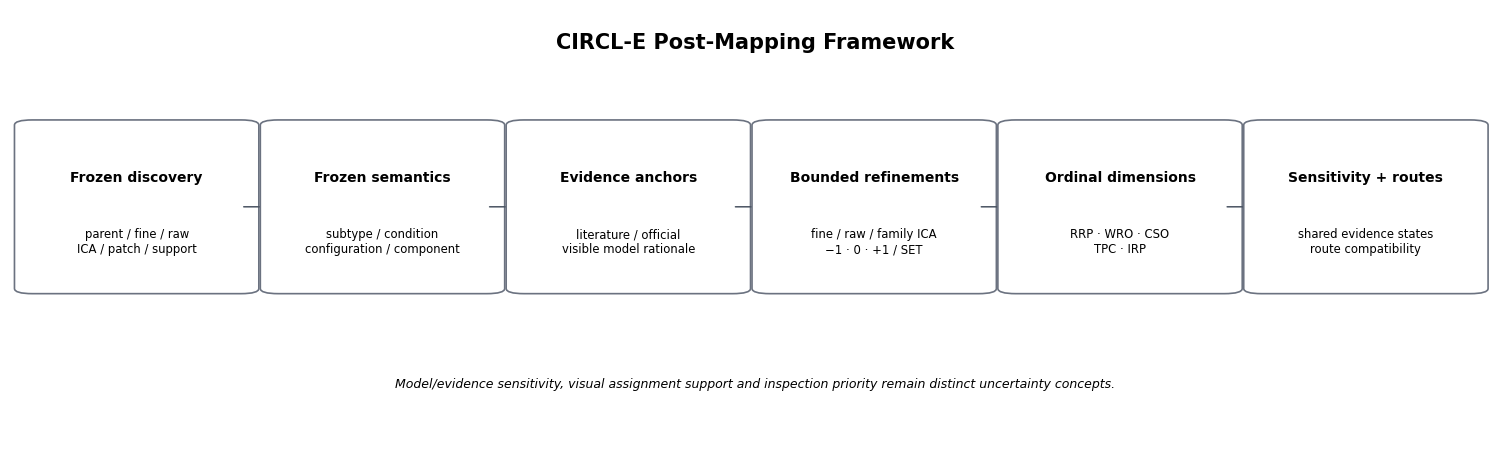

In [5]:
fig,ax=plt.subplots(figsize=(15.2,4.6)); ax.set_axis_off()
boxes=[('Frozen discovery','parent / fine / raw\nICA / patch / support'),('Frozen semantics','subtype / condition\nconfiguration / component'),('Evidence anchors','literature / official\nvisible model rationale'),('Bounded refinements','fine / raw / family ICA\n−1 · 0 · +1 / SET'),('Ordinal dimensions','RRP · WRO · CSO\nTPC · IRP'),('Sensitivity + routes','shared evidence states\nroute compatibility')]
xs=np.linspace(.015,.84,len(boxes));w=.14;h=.38
for i,(title,body) in enumerate(boxes):
    x=xs[i]; y=.35
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle='round,pad=.012',facecolor='white',edgecolor='#6B7280',linewidth=1.2))
    ax.text(x+w/2,y+h*.68,title,ha='center',va='center',fontsize=10,fontweight='bold')
    ax.text(x+w/2,y+h*.29,body,ha='center',va='center',fontsize=8.4)
    if i<len(boxes)-1: ax.add_patch(FancyArrowPatch((x+w,y+h/2),(xs[i+1],y+h/2),arrowstyle='-|>',mutation_scale=12,linewidth=1.1,color='#4B5563'))
ax.text(.5,.91,'CIRCL-E Post-Mapping Framework',ha='center',fontsize=15,fontweight='bold')
ax.text(.5,.12,'Model/evidence sensitivity, visual assignment support and inspection priority remain distinct uncertainty concepts.',ha='center',fontsize=9,style='italic')
fig.tight_layout(); fig.savefig(FIGURES/'01_evidence_to_profile_architecture.png',dpi=190,bbox_inches='tight'); plt.show()

# Bagian B — External evidence dan ordinal criterion model

## B1. Registry sumber evidence

Setiap sumber menyimpan claim scope, system boundary, locator, dan metadata tanggal. Publication, consolidation, serta legal/effective date dipisahkan agar konteks waktu tidak tercampur.

In [6]:
SOURCE_REGISTRY=[
 dict(source_id='E001',organization='UNITAR SCYCLE',title='E-waste Statistics: Guidelines on Classifications, Reporting and Indicators, Third Edition',source_type='official statistical guideline',publication_date='2026-02-12',retrieval_date=ANALYSIS_DATE,url='https://doi.org/10.5281/zenodo.18328494',jurisdiction='international',product_scope='UNU-KEY v2 product descriptions; average weights; EU6-PV material composition',system_boundary='statistical/product and broad waste-stream reference',exact_locator='Zenodo record; UNU-KEY v2 descriptions; Annex 6 average weights; Annex 7 material composition; Tables 26–27',claim_supported='Product taxonomy and broad/product material context; not an item assay.',publisher_hash='PDF md5 dd4ee48bc89062aa36d73bc76c3789f1; Annex 7 md5 4b1ba83522320ade0013aa1237e7ba29',verification_status='VERIFIED_PRIMARY_CURRENT'),
 dict(source_id='E002',organization='European Union',title='Directive 2012/19/EU on WEEE, consolidated 8 April 2024',source_type='legislation',publication_date='2024-04-08',retrieval_date=ANALYSIS_DATE,url='https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:02012L0019-20240408',jurisdiction='EU',product_scope='EEE/WEEE generally',system_boundary='reuse, collection, dismantling, recovery and treatment context',exact_locator='Article 4; Article 6(2); Article 15(1); Annexes III–IV',claim_supported='EEE design/management should facilitate reuse, dismantling and recovery; collected WEEE should support preparation for reuse and appropriate treatment.',publisher_hash=None,verification_status='VERIFIED_PRIMARY_CURRENT'),
 dict(source_id='E003',organization='Basel Convention Secretariat',title='E-waste Amendments FAQs',source_type='international treaty implementation guidance',publication_date='2025-01-01',retrieval_date=ANALYSIS_DATE,url='https://www.basel.int/Implementation/Ewaste/EwasteAmendments/EwasteAmendmentsFAQs/tabid/10107/Default.aspx',jurisdiction='Basel Convention',product_scope='e-waste, components and processing residues',system_boundary='transboundary control and hazardous/special-consideration screening',exact_locator='Questions 1–4, 8, 10–13',claim_supported='A1181/Y49 cover e-waste/components; PIC applies to covered transboundary movements; classification depends on actual waste facts.',publisher_hash=None,verification_status='VERIFIED_PRIMARY_CURRENT'),
 dict(source_id='E004',organization='Government of Indonesia / JDIH BPK',title='Permen LHK No. 9 Tahun 2024',source_type='regulation',publication_date='2024-07-01',retrieval_date=ANALYSIS_DATE,url='https://peraturan.bpk.go.id/Details/291985/permen-lhk-no-9-tahun-2024',jurisdiction='Indonesia',product_scope='unused electronic goods within B3-containing specific-waste framework',system_boundary='domestic waste-management screening',exact_locator='Official abstract; Pasal 3 scope provisions; effective 1 July 2024',claim_supported='Unused electronic goods can fall within the regulated specific-waste framework; business/activity residues are a distinct branch.',publisher_hash=None,verification_status='VERIFIED_PRIMARY_CURRENT'),
 dict(source_id='E005',organization='Umicore',title='E-scrap recycling',source_type='first-party industrial process documentation',publication_date=None,retrieval_date=ANALYSIS_DATE,url='https://www.umicore.com/en/markets-products/recycling-solutions/precious-metals/e-scrap',jurisdiction='industrial/global',product_scope='PCBs, phones/small IT, CPUs/ICs, laptops, PCB-bearing shredded fractions',system_boundary='specialist precious-metal-bearing e-scrap feed acceptance and recovery',exact_locator='E-scrap page; “What can Umicore recycle?” feed list and sampling/assay description',claim_supported='Specialist e-scrap recovery pathway exists for multiple electronics-rich feeds; feed quality/assay matters.',publisher_hash=None,verification_status='VERIFIED_FIRST_PARTY_CURRENT'),
 dict(source_id='E006',organization='Umicore',title='Battery Recycling Solutions / Pyro-hydro technology',source_type='first-party industrial process documentation',publication_date=None,retrieval_date=ANALYSIS_DATE,url='https://www.umicore.com/en/about/battery-materials-solutions/battery-recycling-solutions/start/',jurisdiction='industrial/global',product_scope='lithium-ion batteries and production scrap',system_boundary='specialist battery recycling',exact_locator='“Closing the loop” and “Pyro-hydro technology” sections',claim_supported='Mature specialist battery recovery exists for Li-ion feeds; does not justify chemistry inference from morphology.',publisher_hash=None,verification_status='VERIFIED_FIRST_PARTY_CURRENT'),
 dict(source_id='E007',organization='UNEP / International Resource Panel',title='Metal Recycling: Opportunities, Limits, Infrastructure',source_type='intergovernmental technical report',publication_date='2013',retrieval_date=ANALYSIS_DATE,url='https://wedocs.unep.org/handle/20.500.11822/8423',jurisdiction='international',product_scope='complex products and product-centric metal recycling; washing-machine example',system_boundary='product-centric recycling and material complexity',exact_locator='Product-centric discussion; Section 9.5; Table 39, printed p.223',claim_supported='Complex products contain multiple recoverable material classes; historical washing-machine material context supports appliance resource relevance with transfer risk.',publisher_hash=None,verification_status='VERIFIED_PRIMARY_METADATA_HISTORICAL'),
 dict(source_id='E008',organization='U.S. EPA',title='Cathode Ray Tubes (CRTs)',source_type='government technical/management guidance',publication_date=None,retrieval_date=ANALYSIS_DATE,url='https://www.epa.gov/hw/cathode-ray-tubes-crts',jurisdiction='United States',product_scope='CRT televisions and monitors',system_boundary='CRT reuse/recycling and lead-glass management',exact_locator='“Cathode Ray Tubes (CRTs)” and “Regulation of Cathode Ray Tubes” sections',claim_supported='CRT repair/reuse/recycling pathways exist; lead-containing funnel glass creates specialist controlled-management relevance.',publisher_hash=None,verification_status='VERIFIED_GOVERNMENT_CURRENT'),
 dict(source_id='E009',organization='Journal of Material Cycles and Waste Management',title='Discarded e-waste/printed circuit boards: a review of their recent methods of disassembly, sorting and environmental implications',source_type='peer-reviewed review',publication_date='2024-03-02',retrieval_date=ANALYSIS_DATE,url='https://doi.org/10.1007/s10163-024-01917-7',jurisdiction='research literature',product_scope='discarded printed circuit boards',system_boundary='PCB composition, disassembly, component sorting and environmental implications',exact_locator='Abstract; sections on disassembly and “Sorting of electronic components”',claim_supported='PCBs are heterogeneous metal/non-metal feeds with precious metals; disassembly/sorting and environmentally sound handling are important; component reuse can follow sorting.',publisher_hash=None,verification_status='VERIFIED_PEER_REVIEWED'),
 dict(source_id='E010',organization='RSC Sustainability',title='Recovery of metals and valuable chemicals from waste electric and electronic materials: a critical review of existing technologies',source_type='peer-reviewed review',publication_date='2023',retrieval_date=ANALYSIS_DATE,url='https://doi.org/10.1039/D3SU00034F',jurisdiction='research literature',product_scope='WEEE material recovery',system_boundary='mechanical pretreatment and pyro/hydro/bio-metallurgical recovery',exact_locator='Abstract; Sections 3–4; Conclusions',claim_supported='WEEE is heterogeneous; appropriate recovery uses multiple separation/recovery technologies; pretreatment is important; reuse/recycle/reduce hierarchy is discussed.',publisher_hash=None,verification_status='VERIFIED_PEER_REVIEWED'),
 dict(source_id='E011',organization='Basel Convention / PACE',title='Guideline on environmentally sound testing, refurbishment and repair of used computing equipment',source_type='international technical guidance',publication_date='2013-05-10',retrieval_date=ANALYSIS_DATE,url='https://www.basel.int/Portals/4/download.aspx?d=UNEP-CHW-PART-GUID-PACE-1-Refurbishment-ComputingEquipment.English.pdf',jurisdiction='international guidance',product_scope='PCs, laptops, monitors, printers, keyboards, mice and peripherals',system_boundary='testing, refurbishment and repair',exact_locator='UNEP/CHW.11/INF/12/Rev.1; introductory scope and refurbishment/repair process guidance',claim_supported='Computing equipment and peripherals have defined testing/refurbishment/repair pathways; actual functionality still requires testing.',publisher_hash=None,verification_status='VERIFIED_BASEL_PACE_GUIDANCE'),
 dict(source_id='E012',organization='Basel Convention / Mobile Phone Partnership Initiative',title='Guidance document on environmentally sound management of used and end-of-life mobile phones',source_type='international technical guidance',publication_date='2011',retrieval_date=ANALYSIS_DATE,url='https://www.basel.int/Portals/4/download.aspx?d=UNEP-CHW.10-INF-27-Rev.1.English.pdf',jurisdiction='international guidance',product_scope='used and end-of-life mobile phones',system_boundary='collection, refurbishment, material recovery and recycling',exact_locator='UNEP/CHW.10/INF/27/Rev.1, Introduction §§1–4 and guidance summaries',claim_supported='Mobile-phone reuse/refurbishment and material-recovery/recycling pathways are explicitly recognized.',publisher_hash=None,verification_status='VERIFIED_BASEL_MPPI_GUIDANCE'),
 dict(source_id='E013',organization='European Union',title='Regulation (EU) 2023/1542 concerning batteries and waste batteries',source_type='legislation / technical recovery requirements',publication_date='2023-07-28',retrieval_date=ANALYSIS_DATE,url='https://eur-lex.europa.eu/eli/reg/2023/1542/2023-07-28',jurisdiction='EU',product_scope='waste lead-acid, lithium-based, nickel-cadmium and other batteries',system_boundary='waste-battery treatment, recycling efficiency and material-recovery requirements',exact_locator='Articles 70–71; Annex XII Parts A–C',claim_supported='Waste batteries require dedicated treatment/recycling; the Regulation defines recycling-efficiency and material-recovery requirements across multiple battery categories. It is a regulatory benchmark, not evidence of image-visible chemistry or plant yield.',publisher_hash=None,verification_status='VERIFIED_PRIMARY_CURRENT'),
]
# Date semantics are explicit: publication, consolidation and legal/effective dates are not interchangeable.
for rec in SOURCE_REGISTRY:
    rec.setdefault('effective_date',None)
    rec.setdefault('consolidation_date',None)
    rec.setdefault('date_note','')
_source_by_id={r['source_id']:r for r in SOURCE_REGISTRY}
_source_by_id['E002'].update(
    publication_date='2012-07-24',
    consolidation_date='2024-04-08',
    date_note='Original Directive published in OJ L 197 on 24 July 2012; 8 April 2024 is the consolidated-version date.'
)
_source_by_id['E003'].update(
    publication_date=None,
    effective_date='2025-01-01',
    date_note='The FAQ page does not expose a verified publication date. 1 January 2025 is the entry-into-force date of the Basel e-waste amendments.'
)
_source_by_id['E004'].update(
    effective_date='2024-07-01',
    date_note='Official JDIH metadata records establishment, promulgation and entry into force on 1 July 2024.'
)
_source_by_id['E011'].update(
    publication_date='2013',
    date_note='COP11/PACE guidance document; exact public posting day is not used as a model input.'
)
source_registry=pd.DataFrame(SOURCE_REGISTRY)
assert source_registry.source_id.is_unique
assert source_registry.exact_locator.notna().all()
display(source_registry[['source_id','organization','publication_date','effective_date','consolidation_date','verification_status']])

,source_id,organization,publication_date,effective_date,consolidation_date,verification_status
0,E001,UNITAR SCYCLE,2026-02-12,None,None,VERIFIED_PRIMARY_CURRENT
1,E002,European Union,2012-07-24,None,2024-04-08,VERIFIED_PRIMARY_CURRENT
2,E003,Basel Convention Secretariat,None,2025-01-01,None,VERIFIED_PRIMARY_CURRENT
3,E004,Government of Indonesia / JDIH BPK,2024-07-01,2024-07-01,None,VERIFIED_PRIMARY_CURRENT
4,E005,Umicore,None,None,None,VERIFIED_FIRST_PARTY_CURRENT
5,E006,Umicore,None,None,None,VERIFIED_FIRST_PARTY_CURRENT
6,E007,UNEP / International Resource Panel,2013,None,None,VERIFIED_PRIMARY_METADATA_HISTORICAL
7,E008,U.S. EPA,None,None,None,VERIFIED_GOVERNMENT_CURRENT
8,E009,Journal of Material Cycles and Waste Management,2024-03-02,None,None,VERIFIED_PEER_REVIEWED
9,E010,RSC Sustainability,2023,None,None,VERIFIED_PEER_REVIEWED


## B2. Definisi criterion dan validity per dimension

Setiap dimension memiliki aturan validitas sendiri. RRP membutuhkan resource relevance; WRO membutuhkan class reuse anchor dan evidence image-state; CSO membutuhkan salvage relevance; TPC menggunakan agregasi two-of-three; IRP bersifat diagnostik dengan aturan maksimum.

In [7]:
CRITERIA_BY_DIM={
 'RRP':['RRP_A_resource_relevance','RRP_B_recovery_maturity','RRP_C_feed_specificity'],
 'WRO':['WRO_A_product_reuse','WRO_B_visual_integrity','WRO_C_configuration_completeness'],
 'CSO':['CSO_A_component_salvage','CSO_B_accessibility_dismantling','CSO_C_component_specificity'],
 'TPC':['TPC_A_specialist_requirement','TPC_B_separation_complexity','TPC_C_screening_relevance'],
 'IRP':['IRP_A_assignment_resolution','IRP_B_semantic_evidence_resolution','IRP_C_visual_atypicality_inventory'],
}
ALL_PRIMARY_CRITERIA=sum((CRITERIA_BY_DIM[d] for d in PRIMARY_DIMS),[])
criterion_definitions=pd.DataFrame([
 ('RRP','RRP_A_resource_relevance','Resource concentration / relevance','MANDATORY','Resource significance of the class/feed; chemistry-dependent when chemistry matters.'),
 ('RRP','RRP_B_recovery_maturity','Recovery pathway maturity','AT_LEAST_ONE_OF_BC','Existence/maturity of appropriate recovery pathways.'),
 ('RRP','RRP_C_feed_specificity','Feed specificity / separability','AT_LEAST_ONE_OF_BC','How specific/concentrated the visible/semantic feed is for recovery.'),
 ('WRO','WRO_A_product_reuse','Product reuse relevance','MANDATORY','Class-level relevance of whole-device reuse/refurbishment; never functionality probability.'),
 ('WRO','WRO_B_visual_integrity','Visible whole-device integrity','IMAGE_STATE','Image-derived integrity/condition only.'),
 ('WRO','WRO_C_configuration_completeness','Visible completeness / configuration compatibility','IMAGE_STATE','Image-derived completeness/configuration compatible with whole-device second life.'),
 ('CSO','CSO_A_component_salvage','Component salvage relevance','MANDATORY','Class-level relevance of reusable/salvageable parts or modules.'),
 ('CSO','CSO_B_accessibility_dismantling','Component accessibility / dismantling state','IMAGE_STATE_OPTIONAL','Exposed/open/dismantled state affecting access to parts.'),
 ('CSO','CSO_C_component_specificity','Identifiable component / subassembly opportunity','MANDATORY_SECONDARY','How strongly the class presents identifiable components/subassemblies.'),
 ('TPC','TPC_A_specialist_requirement','Specialist-treatment requirement','TWO_OF_THREE','Need for specialist processing/handling.'),
 ('TPC','TPC_B_separation_complexity','Separation / disassembly complexity','TWO_OF_THREE','Structural/material separation burden.'),
 ('TPC','TPC_C_screening_relevance','Safety / regulatory-screen relevance','TWO_OF_THREE','Need for controlled handling or regulatory screening; not legal status.'),
 ('IRP','IRP_A_assignment_resolution','Assignment resolution need','MAX_RULE','Frozen operational assignment/support diagnostic.'),
 ('IRP','IRP_B_semantic_evidence_resolution','Semantic/evidence resolution need','MAX_RULE','Evidence-transfer and mandatory-anchor ambiguity diagnostic.'),
 ('IRP','IRP_C_visual_atypicality_inventory','Visual atypicality / inventory complexity','MAX_RULE','Within-parent patch atypicality and clutter/scene diagnostic.'),
],columns=['score_dimension','criterion_id','criterion_name','validity_role','meaning'])
criterion_definitions['ordinal_scale']='1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED'
display(criterion_definitions)

,score_dimension,criterion_id,criterion_name,validity_role,meaning,ordinal_scale
0,RRP,RRP_A_resource_relevance,Resource concentration / relevance,MANDATORY,Resource significance of the class/feed; chemistry-dependent when chemistry matters.,1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED
1,RRP,RRP_B_recovery_maturity,Recovery pathway maturity,AT_LEAST_ONE_OF_BC,Existence/maturity of appropriate recovery pathways.,1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED
2,RRP,RRP_C_feed_specificity,Feed specificity / separability,AT_LEAST_ONE_OF_BC,How specific/concentrated the visible/semantic feed is for recovery.,1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED
3,WRO,WRO_A_product_reuse,Product reuse relevance,MANDATORY,Class-level relevance of whole-device reuse/refurbishment; never functionality probability.,1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED
4,WRO,WRO_B_visual_integrity,Visible whole-device integrity,IMAGE_STATE,Image-derived integrity/condition only.,1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED
5,WRO,WRO_C_configuration_completeness,Visible completeness / configuration compatibility,IMAGE_STATE,Image-derived completeness/configuration compatible with whole-device second life.,1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED
6,CSO,CSO_A_component_salvage,Component salvage relevance,MANDATORY,Class-level relevance of reusable/salvageable parts or modules.,1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED
7,CSO,CSO_B_accessibility_dismantling,Component accessibility / dismantling state,IMAGE_STATE_OPTIONAL,Exposed/open/dismantled state affecting access to parts.,1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED
8,CSO,CSO_C_component_specificity,Identifiable component / subassembly opportunity,MANDATORY_SECONDARY,How strongly the class presents identifiable components/subassemblies.,1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED
9,TPC,TPC_A_specialist_requirement,Specialist-treatment requirement,TWO_OF_THREE,Need for specialist processing/handling.,1 LOW · 2 MODERATE-LOW · 3 MODERATE-HIGH · 4 HIGH · UNRESOLVED


## B3. Class-level criterion anchors

In [8]:
# Class-level criterion anchor registry.
def make_anchor(ref,allowed,origin,strength,sources,transfer,claim,rationale):
    return dict(reference_level=ref,allowed_levels=list(allowed),anchor_origin=origin,evidence_strength=strength,source_ids=list(sources),transfer_risk=transfer,source_claim=claim,rationale=rationale)
IMG=make_anchor(None,[1,2,3,4],'FROZEN_SEMANTIC','IMAGE_STATE_REQUIRED',[],'IMAGE_SPECIFIC','Visible condition must come from accepted frozen image semantics, not a parent-class prior.','No class-level integrity value is authored.')
U=make_anchor(None,[],'UNSUPPORTED','UNSUPPORTED',[],'HIGH','No defensible item-level anchor.','Leave unresolved rather than inventing a middle value.')

BASE_CLASS_CRITERIA=CRITERIA_BY_DIM['RRP']+['WRO_A_product_reuse','CSO_A_component_salvage']+CRITERIA_BY_DIM['TPC']

PROFILES={
 'SMARTPHONE':{
  'RRP_A_resource_relevance':make_anchor(4,[3,4],'DIRECT_LITERATURE','HIGH',['E001','E012'],'MEDIUM','Mobile-phone guidance and product/material references document recovery-relevant electronics and materials.','Strong resource-recovery relevance; exact item composition remains unknown.'),
  'RRP_B_recovery_maturity':make_anchor(4,[3,4],'LITERATURE_SYNTHESIS','HIGH',['E005','E010','E012'],'LOW','Specialist e-scrap and mobile-phone material-recovery pathways are established.','Mature pathway evidence without claiming a plant-specific yield.'),
  'RRP_C_feed_specificity':make_anchor(3,[2,3,4],'LITERATURE_SYNTHESIS','MEDIUM',['E005','E012'],'MEDIUM','Phones are identifiable electronics feeds but still combine multiple material/component systems.','Whole phone is less concentrated than a separated specialist component feed.'),
  'WRO_A_product_reuse':make_anchor(4,[3,4],'DIRECT_LITERATURE','HIGH',['E012','E002'],'LOW','Mobile-phone guidance explicitly covers refurbishment/reuse; WEEE framework promotes preparation for reuse.','Reuse relevance is high, but actual functionality is not inferred.'),
  'CSO_A_component_salvage':make_anchor(3,[2,3,4],'LITERATURE_SYNTHESIS','MEDIUM',['E012','E002'],'MEDIUM','Refurbishment/recovery guidance recognizes components and repair/refurbishment pathways.','Meaningful parts opportunity with product/model dependence.'),
  'TPC_A_specialist_requirement':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E010','E012'],'MEDIUM','Appropriate e-waste processing uses specialized pretreatment/recovery; mobile-phone guidance covers controlled management.','Specialist electronics treatment is relevant but less intrinsically specialized than battery/CRT treatment.'),
  'TPC_B_separation_complexity':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E010'],'MEDIUM','WEEE recovery commonly requires pretreatment and separation of heterogeneous components/materials.','Compact multi-component product creates meaningful separation burden.'),
  'TPC_C_screening_relevance':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E003','E004','E012'],'HIGH','E-waste/components can require controlled management; jurisdictional/legal status depends on actual facts.','Screening relevance only; no legal status inferred.'),
 },
 'PCB':{
  'RRP_A_resource_relevance':make_anchor(4,[3,4],'DIRECT_LITERATURE','HIGH',['E009'],'MEDIUM','PCB review documents heterogeneous metal fractions and precious metals such as Au, Ag and Pd.','Strong resource relevance but grade/composition varies.'),
  'RRP_B_recovery_maturity':make_anchor(4,[3,4],'LITERATURE_SYNTHESIS','HIGH',['E005','E009','E010'],'LOW','Specialist PCB/e-scrap recovery, disassembly and metallurgical processing pathways are established.','Mature specialist pathway.'),
  'RRP_C_feed_specificity':make_anchor(4,[3,4],'LITERATURE_SYNTHESIS','HIGH',['E005','E009'],'MEDIUM','PCBs/ICs are recognized specialist e-scrap feeds, although grades are heterogeneous.','Concentrated component feed; mixed debris can reduce this image-specifically.'),
  'WRO_A_product_reuse':make_anchor(1,[1,2],'MODEL_RATIONALE','LOW',[],'MEDIUM','A PCB is a component rather than a complete consumer device.','Whole-device reuse relevance is intrinsically low.'),
  'CSO_A_component_salvage':make_anchor(4,[3,4],'DIRECT_LITERATURE','HIGH',['E009'],'MEDIUM','PCB review explicitly discusses sorting electronic components to facilitate reuse after disassembly.','High component salvage relevance; actual component condition remains unknown.'),
  'TPC_A_specialist_requirement':make_anchor(4,[4],'DIRECT_LITERATURE','HIGH',['E005','E009'],'LOW','Specialist precious-metal-bearing e-scrap processing and PCB disassembly/recovery are established.','Specialist route is central.'),
  'TPC_B_separation_complexity':make_anchor(4,[3,4],'DIRECT_LITERATURE','HIGH',['E009','E010'],'LOW','PCBs combine substrates, solder, components, metals and non-metals; disassembly/sorting are central.','High separation complexity.'),
  'TPC_C_screening_relevance':make_anchor(3,[3,4],'LITERATURE_SYNTHESIS','HIGH',['E009','E003'],'MEDIUM','PCB review notes heavy metals/flame retardants; Basel covers e-waste components depending actual constituents.','Meaningful screening relevance, not image-derived hazardous classification.'),
 },
 'SMALL_PERIPHERAL':{
  'RRP_A_resource_relevance':make_anchor(1,[1,2],'LITERATURE_SYNTHESIS','LOW',['E001'],'HIGH','Only broad small-IT/product-class evidence is available; no strong product-specific resource concentration evidence.','Avoid upward inference from device identity alone.'),
  'RRP_B_recovery_maturity':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E002','E010'],'MEDIUM','General WEEE recovery pathways apply to small computing peripherals.','Established general recycling, less specialist than high-value component feeds.'),
  'RRP_C_feed_specificity':make_anchor(2,[2,3],'MODEL_RATIONALE','LOW',['E001'],'HIGH','The item is identifiable but contains mixed plastics/electronics with sparse product-specific composition evidence.','Broad, conservative feed-specificity assumption.'),
  'WRO_A_product_reuse':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E011','E002'],'MEDIUM','PACE scope includes computer mice/keyboards/peripherals and addresses refurbishment/repair pathways.','Meaningful pathway relevance; functionality still unknown.'),
  'CSO_A_component_salvage':make_anchor(2,[1,2,3],'MODEL_RATIONALE','LOW',['E011'],'HIGH','Peripheral components may be reusable but product-specific evidence is limited.','Moderate-low parts opportunity by transparent rationale.'),
  'TPC_A_specialist_requirement':make_anchor(1,[1,2],'MODEL_RATIONALE','LOW',['E002'],'HIGH','No class-specific evidence that specialist treatment is normally central beyond general WEEE management.','General handling dominates.'),
  'TPC_B_separation_complexity':make_anchor(2,[1,2,3],'MODEL_RATIONALE','LOW',['E010'],'HIGH','Small peripherals require some separation but are less complex than PCB/battery/CRT specialist feeds.','Broad structural rationale.'),
  'TPC_C_screening_relevance':make_anchor(1,[1,2],'LITERATURE_SYNTHESIS','LOW',['E002','E003'],'HIGH','General WEEE screening context applies but no stronger class-specific hazard signal is justified.','Low class-specific screening relevance.'),
 },
 'PRINTER':{
  'RRP_A_resource_relevance':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','LOW',['E001'],'HIGH','Broad printer/product context supports recoverable materials but no concentrated-resource inference.','Moderate-low class-level resource relevance.'),
  'RRP_B_recovery_maturity':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E002','E010'],'MEDIUM','Printers fall within established WEEE recovery/treatment frameworks.','Established general recovery pathway.'),
  'RRP_C_feed_specificity':make_anchor(2,[2,3],'MODEL_RATIONALE','LOW',['E001'],'HIGH','Printer is an identifiable product feed but mechanically/materially mixed.','Broad product-level feed.'),
  'WRO_A_product_reuse':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E011','E002'],'MEDIUM','PACE explicitly includes printers in computing equipment refurbishment/repair scope.','Meaningful reuse pathway without functionality inference.'),
  'CSO_A_component_salvage':make_anchor(3,[2,3],'MODEL_RATIONALE','MEDIUM',['E011'],'MEDIUM','Printers contain separable functional/mechanical components, but subtype-specific evidence is limited.','Moderate-high salvage opportunity by explicit rationale.'),
  'TPC_A_specialist_requirement':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E002'],'MEDIUM','WEEE treatment requirements apply; printer-specific specialist treatment is not universally central.','Moderate-low specialist requirement.'),
  'TPC_B_separation_complexity':make_anchor(3,[2,3],'MODEL_RATIONALE','MEDIUM',['E010'],'MEDIUM','Printers are multi-component electro-mechanical products requiring disassembly/separation.','Moderate-high structural complexity.'),
  'TPC_C_screening_relevance':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','LOW',['E002','E003'],'HIGH','General WEEE screening context applies; exact consumables/constituents are not inferred.','Moderate-low screening relevance.'),
 },
 'LAPTOP':{
  'RRP_A_resource_relevance':make_anchor(4,[3,4],'LITERATURE_SYNTHESIS','HIGH',['E001','E005'],'MEDIUM','Laptops are electronics-rich accepted specialist e-scrap feeds and have broad material-composition evidence.','High resource relevance without item composition claim.'),
  'RRP_B_recovery_maturity':make_anchor(4,[3,4],'LITERATURE_SYNTHESIS','HIGH',['E005','E010','E011'],'LOW','Specialist e-scrap recovery and computing-equipment recycling pathways are established.','Mature pathway.'),
  'RRP_C_feed_specificity':make_anchor(3,[3,4],'LITERATURE_SYNTHESIS','MEDIUM',['E005','E011'],'MEDIUM','Laptop is an identifiable electronics feed but contains screen, battery and multiple subassemblies.','Specific whole-product feed, less concentrated than separated boards/components.'),
  'WRO_A_product_reuse':make_anchor(4,[3,4],'DIRECT_LITERATURE','HIGH',['E011','E002'],'LOW','PACE explicitly covers laptop testing, refurbishment and repair; WEEE framework supports preparing for reuse.','Strong reuse relevance, functionality unobserved.'),
  'CSO_A_component_salvage':make_anchor(4,[3,4],'LITERATURE_SYNTHESIS','HIGH',['E011','E005'],'MEDIUM','Computing-equipment guidance and specialist e-scrap acceptance support substantial component/parts pathways.','High parts opportunity with model/configuration dependence.'),
  'TPC_A_specialist_requirement':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E005','E010','E011'],'MEDIUM','Appropriate processing can require specialist e-scrap handling and subsystem separation.','Moderate-high specialist relevance.'),
  'TPC_B_separation_complexity':make_anchor(3,[3,4],'LITERATURE_SYNTHESIS','HIGH',['E010','E011'],'MEDIUM','Laptop combines battery, display, boards and structural components and benefits from disassembly.','Moderate-high separation burden.'),
  'TPC_C_screening_relevance':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E003','E011'],'HIGH','Computing equipment may contain components requiring controlled management; actual legal status depends on facts.','Meaningful screening relevance.'),
 },
 'MICROWAVE':{
  'RRP_A_resource_relevance':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E001','E007'],'HIGH','Appliance/product-centric evidence supports significant recoverable bulk materials but not precious-metal concentration.','Moderate-high bulk resource relevance.'),
  'RRP_B_recovery_maturity':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E002','E010'],'MEDIUM','General appliance/WEEE recovery and separation pathways are established.','Established recovery pathway.'),
  'RRP_C_feed_specificity':make_anchor(3,[2,3],'MODEL_RATIONALE','MEDIUM',['E001'],'MEDIUM','Microwave is a clearly identifiable appliance feed with separable structural/electrical components.','Product-specific feed, not a concentrated electronic component feed.'),
  'WRO_A_product_reuse':make_anchor(2,[1,2],'MODEL_RATIONALE','LOW',['E002'],'HIGH','Whole appliance reuse is plausible but no product-specific reuse evidence is used.','Conservative rationale; functionality unknown.'),
  'CSO_A_component_salvage':make_anchor(2,[1,2,3],'MODEL_RATIONALE','LOW',[],'HIGH','Some components may be salvageable, but direct evidence is sparse.','Transparent model rationale.'),
  'TPC_A_specialist_requirement':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E002','E010'],'MEDIUM','General controlled WEEE treatment is relevant without evidence that a specialist route is universally central.','Moderate-low specialist requirement.'),
  'TPC_B_separation_complexity':make_anchor(3,[2,3],'MODEL_RATIONALE','MEDIUM',['E010'],'MEDIUM','Electro-mechanical appliance requires disassembly/separation of structural and electrical parts.','Moderate-high separation burden.'),
  'TPC_C_screening_relevance':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','LOW',['E002','E003'],'HIGH','General WEEE screening context applies; no image-derived hazardous constituent claim.','Moderate-low screening relevance.'),
 },
 'FLAT_DISPLAY':{
  'RRP_A_resource_relevance':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E001','E010'],'HIGH','Display category contains recoverable materials but broad display technology/model is unresolved.','Moderate-low resource anchor with transfer risk.'),
  'RRP_B_recovery_maturity':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E002','E010'],'MEDIUM','Display/WEEE recovery and separation pathways are established.','Established recovery pathway.'),
  'RRP_C_feed_specificity':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','LOW',['E001'],'HIGH','Broad flat-panel display parent mixes monitor/TV/device technologies.','Broad product feed; exact technology unresolved.'),
  'WRO_A_product_reuse':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E011','E002'],'HIGH','Computing-display refurbishment/reuse guidance exists, but this parent also includes television displays.','Meaningful but broad reuse relevance.'),
  'CSO_A_component_salvage':make_anchor(2,[2,3],'MODEL_RATIONALE','LOW',['E002'],'HIGH','Display assemblies contain reusable components but product-specific evidence is limited.','Moderate-low component salvage rationale.'),
  'TPC_A_specialist_requirement':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E002','E003','E010'],'HIGH','Displays/components can require controlled treatment and technology-specific processing.','Moderate-high specialist relevance; not legal classification.'),
  'TPC_B_separation_complexity':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E010'],'MEDIUM','Display assemblies require material/component separation.','Moderate-high separation complexity.'),
  'TPC_C_screening_relevance':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E003','E002'],'HIGH','Basel examples explicitly include certain display devices; actual constituents/legal status are not visible.','Meaningful screening relevance.'),
 },
 'BATTERY':{
  'RRP_A_resource_relevance':make_anchor(None,[1,2,3,4],'UNSUPPORTED','UNSUPPORTED',['E006'],'HIGH','Resource concentration is strongly chemistry-dependent; morphology does not establish chemistry.','Leave criterion unresolved to enforce chemistry firewall.'),
  'RRP_B_recovery_maturity':make_anchor(4,[3,4],'LITERATURE_SYNTHESIS','HIGH',['E006','E013'],'MEDIUM','Industrial Li-ion recovery plus multi-category waste-battery treatment/recycling requirements support a mature specialist recovery pathway without inferring chemistry.','Strong pathway maturity; chemistry-specific recovery performance remains unresolved.'),
  'RRP_C_feed_specificity':make_anchor(3,[2,3,4],'MODEL_RATIONALE','MEDIUM',[],'HIGH','Battery/cell is an identifiable component feed, but chemistry and state vary widely.','Moderate-high feed specificity without chemistry inference.'),
  'WRO_A_product_reuse':make_anchor(1,[1,2],'MODEL_RATIONALE','LOW',[],'HIGH','Unknown battery chemistry/state makes whole-component reuse unsuitable as a default visual inference.','Conservative reuse anchor.'),
  'CSO_A_component_salvage':make_anchor(2,[1,2,3],'MODEL_RATIONALE','LOW',[],'HIGH','Component may have second-life uses only after chemistry/state testing, which is absent.','Low/moderate salvage relevance without test data.'),
  'TPC_A_specialist_requirement':make_anchor(4,[4],'LITERATURE_SYNTHESIS','HIGH',['E006','E013','E003'],'MEDIUM','Industrial battery recycling and multi-category waste-battery treatment rules support specialist handling across battery feeds.','Specialist handling central; chemistry still unknown.'),
  'TPC_B_separation_complexity':make_anchor(3,[2,3,4],'LITERATURE_SYNTHESIS','MEDIUM',['E006','E013'],'HIGH','Battery treatment/recycling is chemistry/feed dependent and uses dedicated processing with category-specific recovery requirements.','Moderate-high complexity with transfer uncertainty.'),
  'TPC_C_screening_relevance':make_anchor(4,[3,4],'LITERATURE_SYNTHESIS','HIGH',['E003','E004','E013'],'HIGH','Battery/e-waste management frameworks support strong treatment/screening relevance; exact legal status and chemistry remain unobserved.','High screening priority without legal or chemistry inference.'),
 },
 'WASHER':{
  'RRP_A_resource_relevance':make_anchor(3,[3,4],'DIRECT_LITERATURE','MEDIUM',['E007','E001'],'HIGH','Historical product-centric evidence documents substantial metal fractions in washing machines; current transfer is imperfect.','Moderate-high bulk resource relevance with era/geography transfer risk.'),
  'RRP_B_recovery_maturity':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E007','E010','E002'],'MEDIUM','Appliance recovery/recycling and WEEE dismantling pathways are established.','Established general recovery pathway.'),
  'RRP_C_feed_specificity':make_anchor(4,[3,4],'MODEL_RATIONALE','MEDIUM',['E001'],'MEDIUM','Washer is a distinct large-appliance product feed with separable bulk materials.','High product-feed specificity, not a statement of exact composition.'),
  'WRO_A_product_reuse':make_anchor(2,[2,3],'MODEL_RATIONALE','LOW',['E002'],'HIGH','Reuse/refurbishment is possible in principle but no washer-specific functionality evidence is available.','Conservative product reuse relevance.'),
  'CSO_A_component_salvage':make_anchor(3,[2,3],'MODEL_RATIONALE','LOW',['E002'],'HIGH','Large appliance contains separable mechanical/electrical components with plausible salvage value.','Explicit rationale, not direct literature score.'),
  'TPC_A_specialist_requirement':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E002'],'MEDIUM','General WEEE treatment is relevant; a single specialist pathway is not universally central.','Moderate-low specialist requirement.'),
  'TPC_B_separation_complexity':make_anchor(3,[2,3],'MODEL_RATIONALE','MEDIUM',['E007','E010'],'MEDIUM','Large appliance contains mechanical, electrical and structural subassemblies requiring disassembly.','Moderate-high separation burden.'),
  'TPC_C_screening_relevance':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','LOW',['E002','E003'],'HIGH','General WEEE screening applies; no image-derived legal/hazard state is inferred.','Moderate-low screening relevance.'),
 },
 'CRT':{
  'RRP_A_resource_relevance':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E008','E010'],'HIGH','CRT recycling can recover useful materials, but the feed is not primarily a concentrated precious-metal source.','Moderate-low resource relevance.'),
  'RRP_B_recovery_maturity':make_anchor(3,[2,3],'DIRECT_LITERATURE','MEDIUM',['E008'],'MEDIUM','EPA documents repair/reuse and CRT recycling/disassembly pathways.','Established specialist recovery pathway.'),
  'RRP_C_feed_specificity':make_anchor(3,[2,3],'LITERATURE_SYNTHESIS','MEDIUM',['E008'],'MEDIUM','CRT is a distinct display technology/feed with identifiable treatment needs.','Moderate-high feed specificity.'),
  'WRO_A_product_reuse':make_anchor(2,[1,2],'DIRECT_LITERATURE','MEDIUM',['E008'],'HIGH','EPA encourages repair/reuse where practical, but age/condition/functionality are unresolved.','Limited but explicit reuse pathway.'),
  'CSO_A_component_salvage':make_anchor(2,[1,2],'MODEL_RATIONALE','LOW',['E008'],'HIGH','Some components/materials can be separated, but reusable-parts evidence is not strong.','Moderate-low salvage rationale.'),
  'TPC_A_specialist_requirement':make_anchor(4,[4],'DIRECT_LITERATURE','HIGH',['E008'],'LOW','Lead-containing funnel glass and CRT recycling/management require specialist controlled handling.','Specialist pathway central.'),
  'TPC_B_separation_complexity':make_anchor(4,[3,4],'DIRECT_LITERATURE','HIGH',['E008'],'LOW','CRT recycling typically involves disassembly and controlled glass/component handling.','High separation/treatment complexity.'),
  'TPC_C_screening_relevance':make_anchor(4,[4],'DIRECT_LITERATURE','HIGH',['E008','E003'],'MEDIUM','Lead-glass and transboundary e-waste controls create strong screening relevance.','High screening relevance, not image-derived legal classification.'),
 },
 'AUDIO':{
  'RRP_A_resource_relevance':make_anchor(2,[1,2],'LITERATURE_SYNTHESIS','LOW',['E001'],'HIGH','Broad audio family has general EEE material relevance but weak product-specific concentration evidence.','Moderate-low resource anchor.'),
  'RRP_B_recovery_maturity':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','LOW',['E002','E010'],'MEDIUM','General WEEE recovery pathways exist.','General rather than specialist pathway.'),
  'RRP_C_feed_specificity':make_anchor(2,[2,3],'MODEL_RATIONALE','LOW',['E001'],'HIGH','Audio parent spans boombox, personal player and hi-fi component forms.','Broad product family reduces feed specificity.'),
  'WRO_A_product_reuse':make_anchor(3,[2,3],'MODEL_RATIONALE','MEDIUM',['E002'],'HIGH','Complete consumer audio devices plausibly support second-life use, but no product-specific test evidence is used.','Moderate-high class relevance by explicit rationale.'),
  'CSO_A_component_salvage':make_anchor(3,[2,3],'MODEL_RATIONALE','LOW',[],'HIGH','Audio assemblies can contain reusable electromechanical/electronic components.','Explicit rationale.'),
  'TPC_A_specialist_requirement':make_anchor(2,[1,2],'MODEL_RATIONALE','LOW',['E002'],'HIGH','No evidence that a specialist route is generally central for the broad audio family.','Low/moderate specialist requirement.'),
  'TPC_B_separation_complexity':make_anchor(2,[2,3],'MODEL_RATIONALE','LOW',['E010'],'HIGH','Mixed electromechanical/electronic assemblies require some separation.','Moderate-low complexity.'),
  'TPC_C_screening_relevance':make_anchor(1,[1,2],'LITERATURE_SYNTHESIS','LOW',['E002','E003'],'HIGH','Only general WEEE screening context is supported.','Low class-specific screening relevance.'),
 },
 'TURNTABLE':{
  'RRP_A_resource_relevance':make_anchor(2,[1,2],'LITERATURE_SYNTHESIS','LOW',['E001'],'HIGH','No strong product-specific material concentration evidence; general EEE context only.','Moderate-low resource relevance.'),
  'RRP_B_recovery_maturity':make_anchor(2,[2,3],'LITERATURE_SYNTHESIS','LOW',['E002','E010'],'MEDIUM','General WEEE recovery pathways apply.','General pathway.'),
  'RRP_C_feed_specificity':make_anchor(2,[2,3],'MODEL_RATIONALE','LOW',[],'HIGH','Turntable is identifiable but construction varies from standalone to integrated console.','Moderate-low feed specificity.'),
  'WRO_A_product_reuse':make_anchor(3,[2,3],'MODEL_RATIONALE','MEDIUM',['E002'],'HIGH','Complete consumer audio device with plausible second-life/refurbishment pathway.','Explicit rationale; functionality not inferred.'),
  'CSO_A_component_salvage':make_anchor(3,[2,3],'MODEL_RATIONALE','LOW',[],'HIGH','Mechanical/electrical components may be reusable or repairable.','Explicit rationale.'),
  'TPC_A_specialist_requirement':make_anchor(1,[1,2],'MODEL_RATIONALE','LOW',['E002'],'HIGH','No strong evidence of a specialist route as the default.','Low specialist requirement.'),
  'TPC_B_separation_complexity':make_anchor(2,[1,2,3],'MODEL_RATIONALE','LOW',[],'HIGH','Standalone versus integrated cabinet creates varying disassembly burden.','Moderate-low class-level complexity.'),
  'TPC_C_screening_relevance':make_anchor(1,[1,2],'LITERATURE_SYNTHESIS','LOW',['E002','E003'],'HIGH','Only general WEEE screening context is supported.','Low class-specific screening relevance.'),
 },
 'UNSUPPORTED':{cid:U for cid in BASE_CLASS_CRITERIA},
}
PARENT_PROFILE={0:'UNSUPPORTED',1:'SMARTPHONE',2:'PCB',3:'SMALL_PERIPHERAL',4:'PRINTER',5:'SMALL_PERIPHERAL',6:'LAPTOP',7:'MICROWAVE',8:'UNSUPPORTED',9:'FLAT_DISPLAY',10:'BATTERY',11:'WASHER',12:'CRT',13:'AUDIO',14:'TURNTABLE',15:'WASHER'}
CSO_C_BY_TEMPLATE={
 'SMARTPHONE':(3,[2,3,4],'LITERATURE_SYNTHESIS',['E012','E002'],'Phone assemblies contain repairable/recoverable subassemblies; model-specific accessibility varies.'),
 'PCB':(4,[3,4],'DIRECT_LITERATURE',['E009'],'PCB literature explicitly treats electronic components/subassemblies as identifiable disassembly/sorting targets.'),
 'SMALL_PERIPHERAL':(2,[1,2,3],'MODEL_RATIONALE',[],'Small peripherals contain limited but identifiable electronic/mechanical subassemblies.'),
 'PRINTER':(3,[2,3],'MODEL_RATIONALE',['E011'],'Printer assemblies contain multiple identifiable electromechanical modules.'),
 'LAPTOP':(4,[3,4],'LITERATURE_SYNTHESIS',['E011','E005'],'Laptops contain multiple identifiable repair/recovery subassemblies and components.'),
 'MICROWAVE':(2,[1,2,3],'MODEL_RATIONALE',[],'Electro-mechanical appliance contains identifiable but not uniformly reusable subassemblies.'),
 'FLAT_DISPLAY':(2,[1,2,3],'MODEL_RATIONALE',[],'Display assemblies contain identifiable boards/power/display modules but technology varies.'),
 'BATTERY':(2,[1,2,3],'MODEL_RATIONALE',[],'Battery is itself a component feed; reusable internal subassembly opportunity is limited without chemistry/state evidence.'),
 'WASHER':(3,[2,3],'MODEL_RATIONALE',[],'Large appliance contains identifiable motor/control/mechanical subassemblies.'),
 'CRT':(2,[1,2],'MODEL_RATIONALE',['E008'],'CRT systems have separable assemblies, but reusable-component evidence is limited.'),
 'AUDIO':(3,[2,3],'MODEL_RATIONALE',[],'Audio assemblies commonly contain identifiable electromechanical/electronic subassemblies.'),
 'TURNTABLE':(3,[2,3],'MODEL_RATIONALE',[],'Turntable assemblies contain identifiable mechanical/electrical subassemblies.'),
 'UNSUPPORTED':(None,[],'UNSUPPORTED',[],'No defensible item-level component anchor.'),
}


source_lookup=source_registry.set_index('source_id')
rows=[]
for pid in range(16):
    pkey=PARENT_PROFILE[pid]
    skey=parents.loc[parents.parent_id.eq(pid),'semantic_key'].iloc[0]
    for cid in BASE_CLASS_CRITERIA:
        a=PROFILES[pkey][cid]
        loc=' | '.join(f"{sid}: {source_lookup.loc[sid,'exact_locator']}" for sid in a['source_ids']) if a['source_ids'] else ''
        rows.append({'parent_id':pid,'semantic_key':skey,'profile_template':pkey,'score_dimension':cid.split('_')[0],'criterion_id':cid,
                     'reference_level':a['reference_level'],'allowed_levels':a['allowed_levels'],'anchor_origin':a['anchor_origin'],'evidence_strength':a['evidence_strength'],
                     'source_ids':a['source_ids'],'exact_locator':loc,'source_claim':a['source_claim'],'transfer_risk':a['transfer_risk'],'rationale':a['rationale'],'review_status':'REVIEWED_2026-09-26'})
    for cid in ['WRO_B_visual_integrity','WRO_C_configuration_completeness']:
        rows.append({'parent_id':pid,'semantic_key':skey,'profile_template':pkey,'score_dimension':'WRO','criterion_id':cid,'reference_level':None,'allowed_levels':[1,2,3,4],'anchor_origin':'FROZEN_SEMANTIC','evidence_strength':'IMAGE_STATE_REQUIRED','source_ids':[],'exact_locator':'','source_claim':'Image-derived whole-device state required.','transfer_risk':'IMAGE_SPECIFIC','rationale':'No generic parent-level image condition/completeness value is authored.','review_status':'REVIEWED_2026-09-26'})
    rows.append({'parent_id':pid,'semantic_key':skey,'profile_template':pkey,'score_dimension':'CSO','criterion_id':'CSO_B_accessibility_dismantling','reference_level':None,'allowed_levels':[1,2,3,4],'anchor_origin':'FROZEN_SEMANTIC','evidence_strength':'IMAGE_STATE_OPTIONAL','source_ids':[],'exact_locator':'','source_claim':'Image-derived accessibility/dismantling state only.','transfer_risk':'IMAGE_SPECIFIC','rationale':'No parent-level accessibility state is invented.','review_status':'REVIEWED_2026-09-26'})
    ref,allowed,origin,sources,rationale=CSO_C_BY_TEMPLATE[pkey]
    rows.append({'parent_id':pid,'semantic_key':skey,'profile_template':pkey,'score_dimension':'CSO','criterion_id':'CSO_C_component_specificity','reference_level':ref,'allowed_levels':allowed,'anchor_origin':origin,'evidence_strength':'HIGH' if origin=='DIRECT_LITERATURE' else ('MEDIUM' if ref is not None else 'UNSUPPORTED'),'source_ids':sources,'exact_locator':' | '.join(f"{sid}: {source_lookup.loc[sid,'exact_locator']}" for sid in sources),'source_claim':'Identifiable component/subassembly opportunity at the product/component-family level.','transfer_risk':'MEDIUM' if ref is not None else 'HIGH','rationale':rationale,'review_status':'REVIEWED_2026-09-26'})

criterion_evidence_map=pd.DataFrame(rows)
criterion_evidence_map['claim_id']=criterion_evidence_map.apply(lambda r:f"P{int(r.parent_id):02d}:{r.criterion_id}",axis=1)
criterion_evidence_map['claim_supported']=criterion_evidence_map['source_claim']
criterion_evidence_map['whole_device_reuse_applicability']=np.select([
    criterion_evidence_map.parent_id.isin([0,8]),
    criterion_evidence_map.profile_template.isin(['PCB','BATTERY']),
],['SCENE_OR_RESIDUAL_NA','COMPONENT_LEVEL_NA'],default='WHOLE_DEVICE')

# Whole-device reuse is not defined for component/feed or scene/residual identities.
na_wro=(criterion_evidence_map.criterion_id.eq('WRO_A_product_reuse') & criterion_evidence_map.whole_device_reuse_applicability.ne('WHOLE_DEVICE'))
criterion_evidence_map.loc[na_wro,['reference_level','anchor_origin','evidence_strength','source_claim','claim_supported','rationale']]=[np.nan,'UNSUPPORTED','NOT_APPLICABLE','Whole-device reuse is not applicable to this component/scene parent.','Whole-device reuse is not applicable to this component/scene parent.','Whole-device reuse is not a meaningful class-level construct for this parent.']
criterion_evidence_map.loc[na_wro,'allowed_levels']=criterion_evidence_map.loc[na_wro,'allowed_levels'].map(lambda _:[])
criterion_evidence_map.loc[na_wro,'source_ids']=criterion_evidence_map.loc[na_wro,'source_ids'].map(lambda _:[])

assert len(criterion_evidence_map)==16*12
assert criterion_evidence_map.groupby(['parent_id','score_dimension']).size().eq(3).all()
assert criterion_evidence_map.reference_level.dropna().astype(float).isin([1,2,3,4]).all()
print('Anchor origins:',criterion_evidence_map.anchor_origin.value_counts().to_dict())
display(criterion_evidence_map.head(20))

Anchor origins: {'LITERATURE_SYNTHESIS': 60, 'MODEL_RATIONALE': 48, 'FROZEN_SEMANTIC': 48, 'UNSUPPORTED': 21, 'DIRECT_LITERATURE': 15}


,parent_id,semantic_key,profile_template,score_dimension,criterion_id,reference_level,allowed_levels,anchor_origin,evidence_strength,source_ids,exact_locator,source_claim,transfer_risk,rationale,review_status,claim_id,claim_supported,whole_device_reuse_applicability
0,0,residual:mixed_electronics,UNSUPPORTED,RRP,RRP_A_resource_relevance,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:RRP_A_resource_relevance,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA
1,0,residual:mixed_electronics,UNSUPPORTED,RRP,RRP_B_recovery_maturity,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:RRP_B_recovery_maturity,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA
2,0,residual:mixed_electronics,UNSUPPORTED,RRP,RRP_C_feed_specificity,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:RRP_C_feed_specificity,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA
3,0,residual:mixed_electronics,UNSUPPORTED,WRO,WRO_A_product_reuse,NaN,[],UNSUPPORTED,NOT_APPLICABLE,[],,Whole-device reuse is not applicable to this component/scene parent.,HIGH,Whole-device reuse is not a meaningful class-level construct for this parent.,REVIEWED_2026-09-26,P00:WRO_A_product_reuse,Whole-device reuse is not applicable to this component/scene parent.,SCENE_OR_RESIDUAL_NA
4,0,residual:mixed_electronics,UNSUPPORTED,CSO,CSO_A_component_salvage,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:CSO_A_component_salvage,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA
5,0,residual:mixed_electronics,UNSUPPORTED,TPC,TPC_A_specialist_requirement,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:TPC_A_specialist_requirement,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA
6,0,residual:mixed_electronics,UNSUPPORTED,TPC,TPC_B_separation_complexity,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:TPC_B_separation_complexity,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA
7,0,residual:mixed_electronics,UNSUPPORTED,TPC,TPC_C_screening_relevance,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:TPC_C_screening_relevance,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA
8,0,residual:mixed_electronics,UNSUPPORTED,WRO,WRO_B_visual_integrity,NaN,"[1, 2, 3, 4]",FROZEN_SEMANTIC,IMAGE_STATE_REQUIRED,[],,Image-derived whole-device state required.,IMAGE_SPECIFIC,No generic parent-level image condition/completeness value is authored.,REVIEWED_2026-09-26,P00:WRO_B_visual_integrity,Image-derived whole-device state required.,SCENE_OR_RESIDUAL_NA
9,0,residual:mixed_electronics,UNSUPPORTED,WRO,WRO_C_configuration_completeness,NaN,"[1, 2, 3, 4]",FROZEN_SEMANTIC,IMAGE_STATE_REQUIRED,[],,Image-derived whole-device state required.,IMAGE_SPECIFIC,No generic parent-level image condition/completeness value is authored.,REVIEWED_2026-09-26,P00:WRO_C_configuration_completeness,Image-derived whole-device state required.,SCENE_OR_RESIDUAL_NA


## B4. Claim-level evidence dependencies

In [9]:
# Claim-level support metadata dan fallback policy.
def non_external_support(origin,sources):
    roles={sid:'CONTEXT_ONLY' for sid in list(sources)}
    return roles,'NONE_REQUIRED',0,[],[],list(sources),'NOT_EXTERNAL','KEEP_DECLARED_RATIONALE_OR_STATE',None,[],origin
meta=criterion_evidence_map.apply(lambda r:non_external_support(r.anchor_origin,r.source_ids),axis=1)
criterion_evidence_map['source_roles']=[x[0] for x in meta]
criterion_evidence_map['support_logic']=[x[1] for x in meta]
criterion_evidence_map['minimum_supporting_sources']=[x[2] for x in meta]
criterion_evidence_map['primary_required_source_ids']=[x[3] for x in meta]
criterion_evidence_map['corroborating_source_ids']=[x[4] for x in meta]
criterion_evidence_map['context_only_source_ids']=[x[5] for x in meta]
criterion_evidence_map['support_review_status']=[x[6] for x in meta]
criterion_evidence_map['fallback_action']=[x[7] for x in meta]
criterion_evidence_map['fallback_reference_level']=[x[8] for x in meta]
criterion_evidence_map['fallback_allowed_levels']=[x[9] for x in meta]
criterion_evidence_map['fallback_origin']=[x[10] for x in meta]
criterion_evidence_map['primary_source_loss_effect']='UNCHANGED_IF_SUPPORT_REMAINS'
criterion_evidence_map['corroborating_source_loss_effect']='UNCHANGED_IF_SUPPORT_REMAINS'
criterion_evidence_map['support_review_note']='Non-external row; no external source dependency claim.'
criterion_evidence_map['support_policy_id']='NON_EXTERNAL'

# Manually reviewed claim-level dependency policies.
CLAIM_SUPPORT_REVIEW={}
def set_criterion_support(pid,cid,primary=(),corr=(),context=(),logic='PRIMARY_REQUIRED',failure='ANCHOR_BECOMES_UNSUPPORTED',primary_effect='UNCHANGED_IF_SUPPORT_REMAINS',corr_effect='UNCHANGED_IF_SUPPORT_REMAINS',fallback_ref=None,fallback_allowed=None,note=''):
    key=(int(pid),str(cid))
    CLAIM_SUPPORT_REVIEW[key]={
        'primary_required_source_ids':list(primary),'corroborating_source_ids':list(corr),'context_only_source_ids':list(context),
        'support_logic':logic,'minimum_supporting_sources':1 if logic not in ['ALL','PRIMARY_PLUS_CORROBORATION'] else (len(primary) if logic=='ALL' else 2),
        'fallback_action':failure,'fallback_reference_level':fallback_ref,'fallback_allowed_levels':fallback_allowed,
        'primary_source_loss_effect':primary_effect,'corroborating_source_loss_effect':corr_effect,'support_review_note':note,
    }

# RRP-A: mandatory resource relevance. Product/class-specific evidence cannot be replaced by broad context.
set_criterion_support(1,'RRP_A_resource_relevance',['E001'],corr=['E012'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='UNITAR product/material context is primary; mobile guidance corroborates end-of-life relevance but cannot replace resource evidence.')
set_criterion_support(2,'RRP_A_resource_relevance',['E009'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='PCB-specific peer-reviewed evidence is required.')
for pid in [3,4,5,13,14]: set_criterion_support(pid,'RRP_A_resource_relevance',['E001'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='UNITAR class/material context is the only external anchor for the conservative class-level resource state.')
set_criterion_support(6,'RRP_A_resource_relevance',['E001'],corr=['E005'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='UNITAR class/material context is primary; industrial laptop/e-scrap acceptance corroborates resource relevance.')
set_criterion_support(7,'RRP_A_resource_relevance',['E001'],corr=['E007'],failure='ANCHOR_BECOMES_UNSUPPORTED',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='UNITAR is primary; the IRP complex-product analogue helps bound a high-transfer class prior.')
set_criterion_support(9,'RRP_A_resource_relevance',['E001'],corr=['E010'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='UNITAR product/material context is primary; generic WEEE recovery literature cannot replace it.')
for pid in [11,15]: set_criterion_support(pid,'RRP_A_resource_relevance',['E007'],corr=['E001'],failure='ANCHOR_BECOMES_UNSUPPORTED',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Washer-specific historical product evidence is required; UNITAR only corroborates broader category context.')
set_criterion_support(12,'RRP_A_resource_relevance',['E008'],corr=['E010'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='CRT-specific technical evidence is primary; generic WEEE literature is corroborating only.')

# RRP-B: recovery-pathway maturity.
set_criterion_support(1,'RRP_B_recovery_maturity',['E005','E012'],corr=['E010'],logic='ALL',failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Level-4 maturity uses both phone-specific pathway guidance and an industrial electronics recovery pathway; generic WEEE review is corroborating.')
set_criterion_support(2,'RRP_B_recovery_maturity',['E005','E009'],corr=['E010'],logic='ALL',failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='PCB-specific applicability and an industrial specialist process are both required for the strongest maturity anchor.')
for pid in [3,4,5,7,9,13,14]: set_criterion_support(pid,'RRP_B_recovery_maturity',['E010'],context=['E002'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='Peer-reviewed WEEE recovery review is the technical primary; general WEEE legislation is contextual.')
set_criterion_support(6,'RRP_B_recovery_maturity',['E005','E011'],corr=['E010'],logic='ALL',failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Computing-specific management/refurbishment scope and an industrial laptop/e-scrap route are both required for the strongest laptop maturity anchor.')
set_criterion_support(10,'RRP_B_recovery_maturity',['E013'],corr=['E006'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Multi-category battery regulation is primary for generic battery treatment maturity; Li-ion industrial evidence corroborates but cannot substitute for unknown chemistry.')
for pid in [11,15]: set_criterion_support(pid,'RRP_B_recovery_maturity',['E007','E010'],context=['E002'],logic='ALL',failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='Washer/product context plus general WEEE process evidence are both needed for the externally grounded maturity claim.')
set_criterion_support(12,'RRP_B_recovery_maturity',['E008'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='CRT-specific recovery evidence is required.')

# RRP-C: feed specificity/separability.
for pid,prim in [(1,['E005','E012']),(2,['E005','E009']),(6,['E005','E011'])]: set_criterion_support(pid,'RRP_C_feed_specificity',prim,logic='ALL',failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='Both feed/product applicability and specialist handling evidence are required; otherwise only a broader model-rationale state remains.')
set_criterion_support(9,'RRP_C_feed_specificity',['E001'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='Broad display feed specificity is tied to the UNITAR class definition/material context.')
set_criterion_support(12,'RRP_C_feed_specificity',['E008'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='CRT-specific feed identity evidence is required.')

# TPC-A: specialist-treatment relevance.
set_criterion_support(1,'TPC_A_specialist_requirement',['E012'],corr=['E010'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Phone-specific end-of-life guidance is primary; generic recovery literature only corroborates.')
set_criterion_support(2,'TPC_A_specialist_requirement',['E005','E009'],logic='ALL',failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='PCB applicability plus specialist industrial route evidence are both required for the Level-4 external anchor.')
for pid in [4,11,15]: set_criterion_support(pid,'TPC_A_specialist_requirement',['E002'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='The broad WEEE management framework supports the class-level treatment relevance but is not product-specific; loss falls back to explicit model rationale.')
set_criterion_support(6,'TPC_A_specialist_requirement',['E005','E011'],corr=['E010'],logic='ALL',failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Computing-specific scope and an industrial electronics route jointly ground the laptop treatment anchor.')
set_criterion_support(7,'TPC_A_specialist_requirement',['E010'],context=['E002'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='Technical recovery review is primary; legislation is context only.')
set_criterion_support(9,'TPC_A_specialist_requirement',['E010'],corr=['E003'],context=['E002'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Technical separation/recovery evidence is primary; Basel screening corroborates specialist relevance and WEEE legislation supplies context.')
set_criterion_support(10,'TPC_A_specialist_requirement',['E013'],corr=['E006'],context=['E003'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Multi-category battery treatment requirements are primary; Li-ion industrial evidence corroborates process maturity; Basel is context.')
set_criterion_support(12,'TPC_A_specialist_requirement',['E008'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='CRT-specific controlled-management evidence is required.')

# TPC-B: separation/disassembly complexity.
set_criterion_support(1,'TPC_B_separation_complexity',['E010'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='Peer-reviewed WEEE process literature is the technical anchor.')
set_criterion_support(2,'TPC_B_separation_complexity',['E009'],corr=['E010'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='PCB-specific disassembly/sorting evidence is primary; generic WEEE process evidence corroborates.')
set_criterion_support(6,'TPC_B_separation_complexity',['E011'],corr=['E010'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Computing-equipment management scope is primary; generic WEEE process literature corroborates.')
set_criterion_support(9,'TPC_B_separation_complexity',['E010'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='Peer-reviewed WEEE separation/recovery literature is primary.')
set_criterion_support(10,'TPC_B_separation_complexity',['E013'],corr=['E006'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Multi-category battery treatment requirements are primary; Li-ion process evidence is corroborating only.')
set_criterion_support(12,'TPC_B_separation_complexity',['E008'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='CRT-specific disassembly/controlled-treatment evidence is required.')

# TPC-C: screening relevance; broad regulatory context cannot independently preserve product-specific claims.
set_criterion_support(1,'TPC_C_screening_relevance',['E003','E004'],corr=['E012'],logic='PRIMARY_PLUS_CORROBORATION',failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',primary_effect='BROADEN_IF_SUPPORT_REMAINS',note='At least one regulatory e-waste framework plus phone-specific applicability is required; losing one regulatory jurisdiction broadens scope.')
set_criterion_support(2,'TPC_C_screening_relevance',['E003'],corr=['E009'],logic='PRIMARY_PLUS_CORROBORATION',failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='Basel screening context must be coupled to PCB-specific applicability.')
for pid in [3,4,5,7,9,11,13,14,15]: set_criterion_support(pid,'TPC_C_screening_relevance',['E003'],context=['E002'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='Basel e-waste screening is primary; WEEE legislation is contextual and cannot preserve the claim by itself.')
set_criterion_support(6,'TPC_C_screening_relevance',['E003'],corr=['E011'],logic='PRIMARY_PLUS_CORROBORATION',failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='Basel screening must be coupled to computing-equipment applicability.')
set_criterion_support(10,'TPC_C_screening_relevance',['E013'],corr=['E003','E004'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Battery-specific multi-category regulation is primary; Basel and Indonesian rules corroborate broader screening relevance.')
set_criterion_support(12,'TPC_C_screening_relevance',['E008'],context=['E003'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='CRT-specific technical/management evidence is required; Basel is context only.')

# WRO-A: class-level whole-device reuse relevance. Product-specific guidance is required.
set_criterion_support(1,'WRO_A_product_reuse',['E012'],context=['E002'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='Mobile-phone-specific reuse/refurbishment guidance is required; general WEEE context cannot substitute.')
for pid in [3,4,5,6,9]: set_criterion_support(pid,'WRO_A_product_reuse',['E011'],context=['E002'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='PACE computing/peripheral refurbishment guidance is required; general WEEE context cannot substitute.')
set_criterion_support(12,'WRO_A_product_reuse',['E008'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='CRT-specific repair/reuse evidence is required.')

# CSO-A / CSO-C: component/subassembly relevance.
for cid in ['CSO_A_component_salvage','CSO_C_component_specificity']:
    set_criterion_support(1,cid,['E012'],context=['E002'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',note='Mobile-specific management/refurbishment evidence is primary; general WEEE context does not independently establish parts opportunity.')
    set_criterion_support(2,cid,['E009'],failure='ANCHOR_BECOMES_UNSUPPORTED',note='PCB-specific peer-reviewed disassembly/component evidence is required.')
    set_criterion_support(6,cid,['E011'],corr=['E005'],failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Computing-equipment refurbishment/repair is primary; industrial electronics feed evidence corroborates component recovery relevance.')

# Validate full coverage of every external criterion anchor.
lit_mask=criterion_evidence_map.anchor_origin.isin(['DIRECT_LITERATURE','LITERATURE_SYNTHESIS'])
lit_keys=set(zip(criterion_evidence_map.loc[lit_mask,'parent_id'].astype(int),criterion_evidence_map.loc[lit_mask,'criterion_id']))
assert set(CLAIM_SUPPORT_REVIEW)==lit_keys, {'missing':sorted(lit_keys-set(CLAIM_SUPPORT_REVIEW)),'extra':sorted(set(CLAIM_SUPPORT_REVIEW)-lit_keys)}

def broaden_levels(ref,allowed):
    if pd.isna(ref): return sorted(set(int(x) for x in allowed))
    vals=set(int(x) for x in allowed); vals.update([max(1,int(ref)-1),int(ref),min(4,int(ref)+1)])
    return sorted(vals)

for i,r in criterion_evidence_map.iterrows():
    key=(int(r.parent_id),r.criterion_id)
    if key not in CLAIM_SUPPORT_REVIEW: continue
    p=CLAIM_SUPPORT_REVIEW[key]
    declared=set(p['primary_required_source_ids'])|set(p['corroborating_source_ids'])|set(p['context_only_source_ids'])
    assert declared==set(r.source_ids),(key,declared,r.source_ids)
    roles={sid:'PRIMARY' for sid in p['primary_required_source_ids']}
    roles.update({sid:'CORROBORATING' for sid in p['corroborating_source_ids']})
    roles.update({sid:'CONTEXT_ONLY' for sid in p['context_only_source_ids']})
    criterion_evidence_map.at[i,'source_roles']=roles
    for c in ['support_logic','minimum_supporting_sources','primary_required_source_ids','corroborating_source_ids','context_only_source_ids','fallback_action','primary_source_loss_effect','corroborating_source_loss_effect','support_review_note']:
        criterion_evidence_map.at[i,c]=p[c]
    fb_ref=p['fallback_reference_level']
    if fb_ref is None and p['fallback_action']=='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE': fb_ref=r.reference_level
    fb_allowed=p['fallback_allowed_levels']
    if fb_allowed is None and p['fallback_action']=='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE': fb_allowed=broaden_levels(r.reference_level,r.allowed_levels)
    criterion_evidence_map.at[i,'fallback_reference_level']=fb_ref
    criterion_evidence_map.at[i,'fallback_allowed_levels']=[] if fb_allowed is None else fb_allowed
    criterion_evidence_map.at[i,'fallback_origin']='MODEL_RATIONALE_AFTER_SOURCE_ABLATION' if p['fallback_action']=='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE' else 'UNSUPPORTED_AFTER_SOURCE_ABLATION'
    criterion_evidence_map.at[i,'support_review_status']='MANUALLY_REVIEWED_2026-09-26'
    criterion_evidence_map.at[i,'support_policy_id']=f"MANUAL:P{int(r.parent_id):02d}:{r.criterion_id}"

assert len(criterion_evidence_map)==16*12
assert criterion_evidence_map.groupby(['parent_id','score_dimension']).size().eq(3).all()
assert criterion_evidence_map.reference_level.dropna().astype(float).isin([1,2,3,4]).all()
assert criterion_evidence_map.loc[lit_mask,'support_review_status'].eq('MANUALLY_REVIEWED_2026-09-26').all()
print('Manually reviewed external anchors:',int(lit_mask.sum()))
display(criterion_evidence_map.head(24))

Manually reviewed external anchors: 75


,parent_id,semantic_key,profile_template,score_dimension,criterion_id,reference_level,allowed_levels,anchor_origin,evidence_strength,source_ids,exact_locator,source_claim,transfer_risk,rationale,review_status,claim_id,claim_supported,whole_device_reuse_applicability,source_roles,support_logic,minimum_supporting_sources,primary_required_source_ids,corroborating_source_ids,context_only_source_ids,support_review_status,fallback_action,fallback_reference_level,fallback_allowed_levels,fallback_origin,primary_source_loss_effect,corroborating_source_loss_effect,support_review_note,support_policy_id
0,0,residual:mixed_electronics,UNSUPPORTED,RRP,RRP_A_resource_relevance,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:RRP_A_resource_relevance,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,None,[],UNSUPPORTED,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Non-external row; no external source dependency claim.,NON_EXTERNAL
1,0,residual:mixed_electronics,UNSUPPORTED,RRP,RRP_B_recovery_maturity,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:RRP_B_recovery_maturity,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,None,[],UNSUPPORTED,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Non-external row; no external source dependency claim.,NON_EXTERNAL
2,0,residual:mixed_electronics,UNSUPPORTED,RRP,RRP_C_feed_specificity,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:RRP_C_feed_specificity,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,None,[],UNSUPPORTED,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Non-external row; no external source dependency claim.,NON_EXTERNAL
3,0,residual:mixed_electronics,UNSUPPORTED,WRO,WRO_A_product_reuse,NaN,[],UNSUPPORTED,NOT_APPLICABLE,[],,Whole-device reuse is not applicable to this component/scene parent.,HIGH,Whole-device reuse is not a meaningful class-level construct for this parent.,REVIEWED_2026-09-26,P00:WRO_A_product_reuse,Whole-device reuse is not applicable to this component/scene parent.,SCENE_OR_RESIDUAL_NA,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,None,[],UNSUPPORTED,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Non-external row; no external source dependency claim.,NON_EXTERNAL
4,0,residual:mixed_electronics,UNSUPPORTED,CSO,CSO_A_component_salvage,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:CSO_A_component_salvage,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,None,[],UNSUPPORTED,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Non-external row; no external source dependency claim.,NON_EXTERNAL
5,0,residual:mixed_electronics,UNSUPPORTED,TPC,TPC_A_specialist_requirement,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather than inventing a middle value.,REVIEWED_2026-09-26,P00:TPC_A_specialist_requirement,No defensible item-level anchor.,SCENE_OR_RESIDUAL_NA,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,None,[],UNSUPPORTED,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Non-external row; no external source dependency claim.,NON_EXTERNAL
6,0,residual:mixed_electronics,UNSUPPORTED,TPC,TPC_B_separation_complexity,NaN,[],UNSUPPORTED,UNSUPPORTED,[],,No defensible item-level anchor.,HIGH,Leave unresolved rather tha

### Gambar 2 — Parent class-anchor atlas

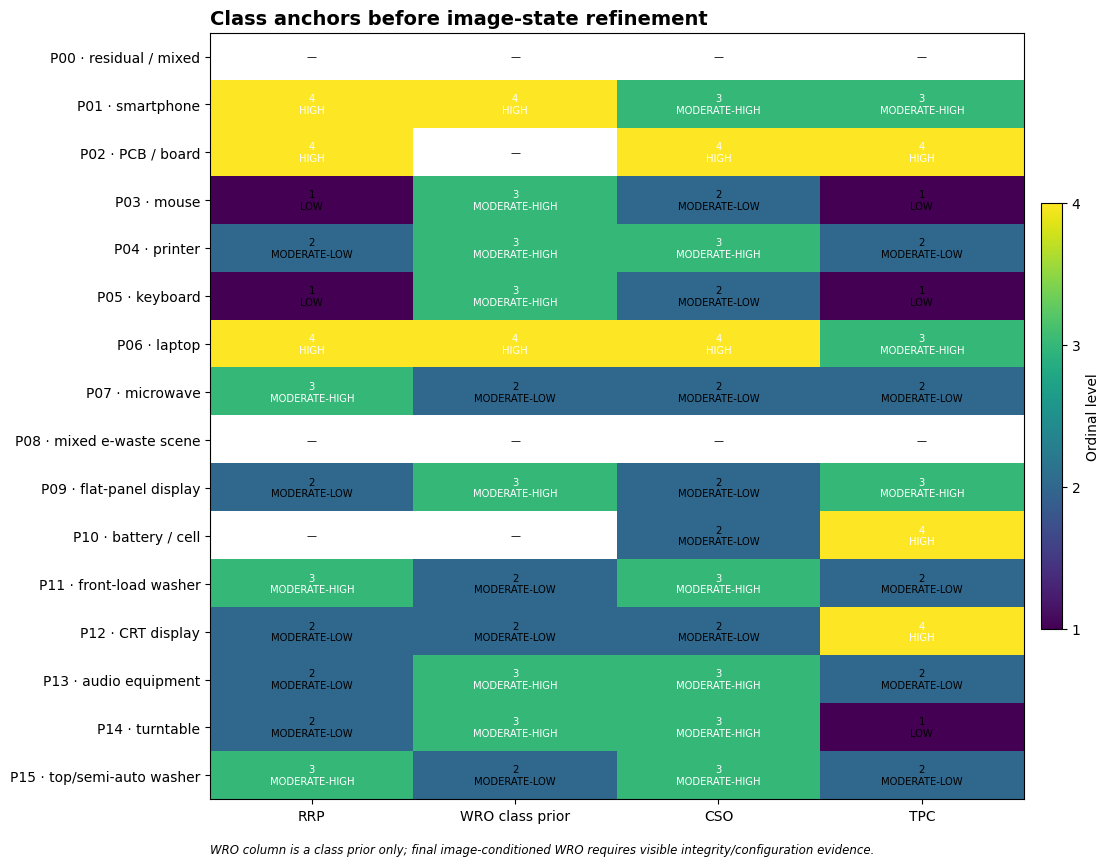

In [10]:
def safe_lower_median(vals):
    x=sorted(int(v) for v in vals if pd.notna(v))
    if len(x)<2:return np.nan
    return x[(len(x)-1)//2]

def aggregate_levels(vals,dim):
    d={c:vals.get(c,np.nan) for c in CRITERIA_BY_DIM[dim]}
    if dim=='RRP':
        a=d['RRP_A_resource_relevance']; extras=[d['RRP_B_recovery_maturity'],d['RRP_C_feed_specificity']]
        if pd.isna(a) or not any(pd.notna(x) for x in extras): return np.nan
        cons=safe_lower_median([a]+extras); return min(int(a),int(cons))
    if dim=='WRO':
        a=d['WRO_A_product_reuse']; states=[d['WRO_B_visual_integrity'],d['WRO_C_configuration_completeness']]
        if pd.isna(a) or not any(pd.notna(x) for x in states): return np.nan
        return safe_lower_median([a]+states)
    if dim=='CSO':
        a=d['CSO_A_component_salvage']; extras=[d['CSO_B_accessibility_dismantling'],d['CSO_C_component_specificity']]
        if pd.isna(a) or not any(pd.notna(x) for x in extras): return np.nan
        return safe_lower_median([a]+extras)
    if dim=='TPC': return safe_lower_median([d[c] for c in CRITERIA_BY_DIM['TPC']])
    raise ValueError(dim)

def parent_reference(pid,dim):
    g=criterion_evidence_map[(criterion_evidence_map.parent_id.eq(pid))&(criterion_evidence_map.score_dimension.eq(dim))]
    vals={r.criterion_id:r.reference_level for r in g.itertuples(index=False)}
    return aggregate_levels(vals,dim)

parent_anchor_rows=[]
for pid in range(16):
    row={'parent_id':pid,'semantic_key':parents.loc[parents.parent_id.eq(pid),'semantic_key'].iloc[0]}
    row['RRP']=parent_reference(pid,'RRP')
    row['WRO_class_prior']=criterion_evidence_map[(criterion_evidence_map.parent_id.eq(pid))&(criterion_evidence_map.criterion_id.eq('WRO_A_product_reuse'))].reference_level.iloc[0]
    row['CSO']=parent_reference(pid,'CSO')
    row['TPC']=parent_reference(pid,'TPC')
    parent_anchor_rows.append(row)
parent_anchor_summary=pd.DataFrame(parent_anchor_rows)
SHORT_PARENT_LABELS=['residual / mixed','smartphone','PCB / board','mouse','printer','keyboard','laptop','microwave','mixed e-waste scene','flat-panel display','battery / cell','front-load washer','CRT display','audio equipment','turntable','top/semi-auto washer']
mat=parent_anchor_summary[['RRP','WRO_class_prior','CSO','TPC']].to_numpy(float)
fig,ax=plt.subplots(figsize=(11.2,8.7)); im=ax.imshow(np.ma.masked_invalid(mat),aspect='auto',vmin=1,vmax=4,cmap='viridis')
ax.set_xticks(range(4),['RRP','WRO class prior','CSO','TPC']); ax.set_yticks(range(16),[f'P{i:02d} · {SHORT_PARENT_LABELS[i]}' for i in range(16)])
for i in range(16):
    for j in range(4):
        v=mat[i,j]; ax.text(j,i,'—' if np.isnan(v) else f'{int(v)}\n{LEVEL_LABEL[int(v)]}',ha='center',va='center',fontsize=7.2,color='white' if np.isfinite(v) and v>=3 else 'black')
ax.set_title('Class anchors before image-state refinement',loc='left',fontweight='bold',fontsize=14)
ax.text(0,-.07,'WRO column is a class prior only; final image-conditioned WRO requires visible integrity/configuration evidence.',transform=ax.transAxes,fontsize=8.5,style='italic')
fig.colorbar(im,ax=ax,fraction=.025,pad=.02,ticks=[1,2,3,4],label='Ordinal level')
fig.tight_layout(); fig.savefig(FIGURES/'02_parent_criterion_atlas.png',dpi=190,bbox_inches='tight'); plt.show()

# Bagian C — Semantic permission dan bounded visual refinement

## C1. Fine/raw transition registry — WRO dan CSO dipisahkan

In [11]:
# Discrete semantic transition rules.
RULES=[]
def add_semantic_rule(rule_id,stage,structure_id,parent_id,target_kind,target_id,action,central_policy,semantic_confidence,redundancy_group,origin,rationale,scenario_actions=None):
    RULES.append(dict(rule_id=rule_id,stage=stage,structure_id=structure_id,parent_id=parent_id,target_kind=target_kind,target_id=target_id,action=action,central_policy=central_policy,semantic_confidence=semantic_confidence,redundancy_group=redundancy_group,anchor_origin=origin,rationale=rationale,scenario_actions=scenario_actions or [action]))
# Smartphone condition.
add_semantic_rule('F_PHONE_INTACT','fine',0,1,'criterion','WRO_B_visual_integrity','SET_3','CENTRAL','high','phone_condition','FROZEN_SEMANTIC','No obvious severe screen breakage supports moderate-high visible integrity; not functionality.',['SET_2','SET_3'])
add_semantic_rule('F_PHONE_INTACT_REUSE','fine',0,1,'route','reuse_refurbish','UP_1','CENTRAL','high','phone_condition','MODEL_RATIONALE','Intact-looking presentation modestly raises reuse-route compatibility.',['UP_1'])
add_semantic_rule('F_PHONE_CRACK','fine',1,1,'criterion','WRO_B_visual_integrity','SET_1','CENTRAL','high','phone_condition','FROZEN_SEMANTIC','Cracked/shattered display is direct negative whole-device visual condition evidence.',['SET_1','SET_2'])
add_semantic_rule('F_PHONE_CRACK_REUSE','fine',1,1,'route','reuse_refurbish','DOWN_1','CENTRAL','high','phone_condition','MODEL_RATIONALE','Crack lowers whole-device reuse compatibility.',['DOWN_1'])
add_semantic_rule('F_PHONE_CRACK_PARTS','fine',1,1,'route','parts_harvest','UP_1','CENTRAL','high','phone_condition','MODEL_RATIONALE','Visible damage shifts relative compatibility toward parts harvesting.',['UP_1'])
# PCB feed distinctions.
add_semantic_rule('F_PCB_BULK_SORT','fine',4,2,'route','sorting_dismantling','UP_1','CENTRAL','high','pcb_bulk','MODEL_RATIONALE','Bulk board collection raises sorting/handling relevance.',['UP_1'])
add_semantic_rule('F_PCB_IC_FEED','fine',5,2,'criterion','RRP_C_feed_specificity','UP_1','CENTRAL','high','pcb_ic','LITERATURE_SYNTHESIS','Loose IC/processor packages are a more concentrated specialist component feed.',['UP_1'])
add_semantic_rule('F_PCB_IC_CSO','fine',5,2,'criterion','CSO_C_component_specificity','UP_1','CENTRAL','high','pcb_ic','LITERATURE_SYNTHESIS','Identified IC/processor packages increase component specificity.',['UP_1'])
add_semantic_rule('F_PCB_IC_ROUTE','fine',5,2,'route','specialist_pcb','UP_1','CENTRAL','high','pcb_ic','LITERATURE_SYNTHESIS','IC/CPU component feed strongly fits specialist e-scrap recovery.',['UP_1'])
# Laptop configuration and condition.
add_semantic_rule('F_LAPTOP_OPEN_WRO','fine',10,6,'criterion','WRO_C_configuration_completeness','SET_4','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','high','laptop_configuration','FROZEN_SEMANTIC','Open laptop is visibly a coherent whole-device configuration; not functionality evidence.',['SET_3','SET_4'])
add_semantic_rule('F_LAPTOP_OPEN_CSO','fine',10,6,'criterion','CSO_B_accessibility_dismantling','SET_3','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','high','laptop_configuration','MODEL_RATIONALE','Open configuration modestly increases component accessibility.',['SET_2','SET_3'])
add_semantic_rule('F_LAPTOP_OPEN_PARTS','fine',10,6,'route','parts_harvest','UP_1','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','high','laptop_configuration','MODEL_RATIONALE','Open configuration increases parts inspection/harvest compatibility.',['NO_CHANGE','UP_1'])
add_semantic_rule('F_LAPTOP_CLOSED_WRO','fine',11,6,'criterion','WRO_C_configuration_completeness','SET_4','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','high','laptop_configuration','FROZEN_SEMANTIC','Closed individual laptop remains a coherent complete-device configuration.',['SET_3','SET_4'])
add_semantic_rule('F_LAPTOP_DMG_WRO','fine',12,6,'criterion','WRO_B_visual_integrity','SET_1','SENSITIVITY_ONLY','medium','laptop_integrity','FROZEN_SEMANTIC','Medium-confidence dismantled/damaged fine semantic enters sensitivity only.',['NO_CHANGE','SET_1','SET_2'])
add_semantic_rule('F_LAPTOP_DMG_CSO','fine',12,6,'criterion','CSO_B_accessibility_dismantling','SET_4','SENSITIVITY_ONLY','medium','laptop_integrity','MODEL_RATIONALE','Dismantling can strongly expose parts; medium-confidence fine semantic remains sensitivity-only.',['NO_CHANGE','SET_3','SET_4'])
# Turntable integrated cabinet.
add_semantic_rule('F_TURNTABLE_CONSOLE','fine',27,14,'criterion','TPC_B_separation_complexity','UP_1','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','medium-high','turntable_form','MODEL_RATIONALE','Integrated console form plausibly raises disassembly complexity.',['NO_CHANGE','UP_1'])
add_semantic_rule('F_TURNTABLE_CONSOLE_PARTS','fine',27,14,'route','parts_harvest','UP_1','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','medium-high','turntable_form','MODEL_RATIONALE','Integrated console may increase parts-harvest relevance.',['NO_CHANGE','UP_1'])
# Accepted raw visual evidence.
add_semantic_rule('R_PHONE_INTACT','raw_visual',3,1,'criterion','WRO_B_visual_integrity','SET_3','CENTRAL','high','phone_condition','FROZEN_SEMANTIC','Accepted raw intact-looking phone condition leaf.',['SET_2','SET_3'])
add_semantic_rule('R_PHONE_CRACK','raw_visual',4,1,'criterion','WRO_B_visual_integrity','SET_1','CENTRAL','high','phone_condition','FROZEN_SEMANTIC','Accepted raw cracked-phone condition leaf.',['SET_1','SET_2'])
add_semantic_rule('R_PCB_DEBRIS','raw_visual',8,2,'criterion','RRP_C_feed_specificity','DOWN_1','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','medium-high','pcb_debris','FROZEN_SEMANTIC','PCB scrap mixed with wires/debris is less feed-specific.',['NO_CHANGE','DOWN_1'])
add_semantic_rule('R_PCB_DEBRIS_SORT','raw_visual',8,2,'route','sorting_dismantling','UP_1','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','medium-high','pcb_debris','MODEL_RATIONALE','Mixed board/debris presentation raises sorting relevance.',['NO_CHANGE','UP_1'])
add_semantic_rule('R_PCB_DEBRIS_SPEC','raw_visual',8,2,'route','specialist_pcb','DOWN_1','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','medium-high','pcb_debris','MODEL_RATIONALE','Unsorted mixed debris is less directly compatible with specialist PCB feed.',['NO_CHANGE','DOWN_1'])
add_semantic_rule('R_LAPTOP_DMG_WRO','raw_visual',23,6,'criterion','WRO_B_visual_integrity','SET_1','CENTRAL','high','laptop_integrity','FROZEN_SEMANTIC','High-confidence dismantled/damaged laptop raw leaf lowers whole-device opportunity.',['SET_1','SET_2'])
add_semantic_rule('R_LAPTOP_DMG_WRO_CONFIG','raw_visual',23,6,'criterion','WRO_C_configuration_completeness','SET_1','CENTRAL','high','laptop_integrity','FROZEN_SEMANTIC','Dismantled laptop is not a coherent whole-device configuration.',['SET_1','SET_2'])
add_semantic_rule('R_LAPTOP_DMG_CSO','raw_visual',23,6,'criterion','CSO_B_accessibility_dismantling','SET_4','CENTRAL','high','laptop_integrity','MODEL_RATIONALE','Exposed/dismantled components strongly increase component accessibility.',['SET_3','SET_4'])
add_semantic_rule('R_LAPTOP_DMG_REUSE','raw_visual',23,6,'route','reuse_refurbish','DOWN_1','CENTRAL','high','laptop_integrity','MODEL_RATIONALE','Dismantled presentation lowers whole-device reuse compatibility.',['DOWN_1'])
add_semantic_rule('R_LAPTOP_DMG_PARTS','raw_visual',23,6,'route','parts_harvest','UP_1','CENTRAL','high','laptop_integrity','MODEL_RATIONALE','Dismantled state raises parts-harvest compatibility.',['UP_1'])
add_semantic_rule('R_LAPTOP_DMG_SORT','raw_visual',23,6,'route','sorting_dismantling','UP_1','CENTRAL','high','laptop_integrity','MODEL_RATIONALE','Dismantled/scrap state raises sorting relevance.',['UP_1'])
add_semantic_rule('R_LAPTOP_DMG_TPC','raw_visual',23,6,'criterion','TPC_B_separation_complexity','UP_1','CENTRAL','high','laptop_integrity','MODEL_RATIONALE','Dismantled mixed component presentation increases separation/sorting burden.',['UP_1'])
add_semantic_rule('R_DISPLAY_CRACK','raw_visual',31,9,'criterion','WRO_B_visual_integrity','SET_1','CENTRAL','high','display_condition','FROZEN_SEMANTIC','Cracked/malfunctioning-looking display lowers whole-device visible integrity.',['SET_1','SET_2'])
add_semantic_rule('R_DISPLAY_CRACK_REUSE','raw_visual',31,9,'route','reuse_refurbish','DOWN_1','CENTRAL','high','display_condition','MODEL_RATIONALE','Cracked display lowers reuse compatibility.',['DOWN_1'])
add_semantic_rule('R_DISPLAY_CRACK_PARTS','raw_visual',31,9,'route','parts_harvest','UP_1','CENTRAL','high','display_condition','MODEL_RATIONALE','Damaged display shifts relative compatibility toward parts.',['UP_1'])
add_semantic_rule('R_DISPLAY_ACTIVE','raw_visual',32,9,'criterion','WRO_B_visual_integrity','SET_3','CENTRAL','high','display_active','FROZEN_SEMANTIC','Active-looking screen is positive visual presentation evidence, not functionality probability.',['SET_2','SET_3'])
add_semantic_rule('R_DISPLAY_ACTIVE_REUSE','raw_visual',32,9,'route','reuse_refurbish','UP_1','CENTRAL','high','display_active','MODEL_RATIONALE','Active presentation modestly raises reuse inspection compatibility.',['UP_1'])
semantic_transition_registry=pd.DataFrame(RULES)
assert semantic_transition_registry.action.isin(['SET_1','SET_2','SET_3','SET_4','UP_1','DOWN_1','NO_CHANGE']).all()

permission=[]
for df,stage in [(fines,'fine'),(raw_visual,'raw_visual')]:
    for r in df.itertuples(index=False):
        rr=semantic_transition_registry[(semantic_transition_registry.stage.eq(stage))&(semantic_transition_registry.structure_id.eq(int(r.structure_id)))]
        nuisance=(str(r.role) in ['acquisition_style','viewpoint','nuisance']) or ('nuisance' in str(r.status))
        permission.append({'stage':stage,'structure_id':int(r.structure_id),'parent_id':int(r.parent_id),'semantic_key':r.semantic_key,'role':r.role,'status':r.status,'confidence':r.confidence,'central_effect_rule_ids':rr.loc[~rr.central_policy.eq('SENSITIVITY_ONLY'),'rule_id'].tolist(),'sensitivity_rule_ids':rr.rule_id.tolist(),'nuisance_zero_effect_required':bool(nuisance),'permission_status':'NUISANCE_EXACT_ZERO' if nuisance else ('REVIEWED_RULE' if len(rr) else 'NO_DEFENSIBLE_DOWNSTREAM_LINK')})
semantic_permission_registry=pd.DataFrame(permission)
display(semantic_transition_registry[['rule_id','stage','structure_id','target_kind','target_id','action','central_policy','anchor_origin']])

,rule_id,stage,structure_id,target_kind,target_id,action,central_policy,anchor_origin
0,F_PHONE_INTACT,fine,0,criterion,WRO_B_visual_integrity,SET_3,CENTRAL,FROZEN_SEMANTIC
1,F_PHONE_INTACT_REUSE,fine,0,route,reuse_refurbish,UP_1,CENTRAL,MODEL_RATIONALE
2,F_PHONE_CRACK,fine,1,criterion,WRO_B_visual_integrity,SET_1,CENTRAL,FROZEN_SEMANTIC
3,F_PHONE_CRACK_REUSE,fine,1,route,reuse_refurbish,DOWN_1,CENTRAL,MODEL_RATIONALE
4,F_PHONE_CRACK_PARTS,fine,1,route,parts_harvest,UP_1,CENTRAL,MODEL_RATIONALE
5,F_PCB_BULK_SORT,fine,4,route,sorting_dismantling,UP_1,CENTRAL,MODEL_RATIONALE
6,F_PCB_IC_FEED,fine,5,criterion,RRP_C_feed_specificity,UP_1,CENTRAL,LITERATURE_SYNTHESIS
7,F_PCB_IC_CSO,fine,5,criterion,CSO_C_component_specificity,UP_1,CENTRAL,LITERATURE_SYNTHESIS
8,F_PCB_IC_ROUTE,fine,5,route,specialist_pcb,UP_1,CENTRAL,LITERATURE_SYNTHESIS
9,F_LAPTOP_OPEN_WRO,fine,10,criterion,WRO_C_configuration_completeness,SET_4,CENTRAL_WITH_NO_EFFECT_SENSITIVITY,FROZEN_SEMANTIC


## C2. Continuous-factor transition registry

In [12]:
# Continuous-factor transition rules.
CONT_RULES=[]
def add_continuous_rule(rule_id,scope,parent_id,factor_id,state,target_kind,target_id,action,central_policy,redundancy_group,origin,rationale,scenario_actions=None):
    CONT_RULES.append(dict(rule_id=rule_id,scope=scope,parent_id=parent_id,factor_id=factor_id,activation_state=state,target_kind=target_kind,target_id=target_id,action=action,central_policy=central_policy,redundancy_group=redundancy_group,anchor_origin=origin,rationale=rationale,scenario_actions=scenario_actions or [action]))
# Global factor 1 deliberately absent. Global factor 11 only sorting/IRP context.
add_continuous_rule('G11_CLUTTER_SORT','global',None,11,'STRONG_HIGH','route','sorting_dismantling','UP_1','CENTRAL','global_clutter','FROZEN_SEMANTIC','Multi-object clutter raises sorting relevance.',['UP_1'])
# PCB presentation sensitivity only.
add_continuous_rule('P02F1_DIRTY_FEED','family',2,1,'STRONG_HIGH','criterion','RRP_C_feed_specificity','DOWN_1','SENSITIVITY_ONLY','pcb_presentation','FROZEN_SEMANTIC','Installed/handled/dirty PCB presentation may lower feed specificity.',['NO_CHANGE','DOWN_1'])
add_continuous_rule('P02F1_DIRTY_SORT','family',2,1,'STRONG_HIGH','route','sorting_dismantling','UP_1','SENSITIVITY_ONLY','pcb_presentation','MODEL_RATIONALE','Dirty/installed presentation may raise sorting relevance.',['NO_CHANGE','UP_1'])
# Parent-specific laptop factor 0 can provide weak image-state evidence only when no higher-specificity condition rule fires.
add_continuous_rule('P06F0_COHERENT_WRO','family',6,0,'STRONG_HIGH','criterion','WRO_B_visual_integrity','SET_3','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','laptop_integrity','FROZEN_SEMANTIC','Strong coherent-laptop side provides parent-specific integrity evidence.',['NO_CHANGE','SET_2','SET_3'])
add_continuous_rule('P06F0_DISMANTLED_WRO','family',6,0,'STRONG_LOW','criterion','WRO_B_visual_integrity','SET_2','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','laptop_integrity','FROZEN_SEMANTIC','Strong dismantled/bulk side lowers integrity opportunity but remains presentation-sensitive.',['NO_CHANGE','SET_1','SET_2'])
add_continuous_rule('P06F0_DISMANTLED_CSO','family',6,0,'STRONG_LOW','criterion','CSO_B_accessibility_dismantling','SET_3','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','laptop_integrity','MODEL_RATIONALE','Dismantled side modestly increases component accessibility.',['NO_CHANGE','SET_3'])
add_continuous_rule('P06F0_COHERENT_REUSE','family',6,0,'STRONG_HIGH','route','reuse_refurbish','UP_1','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','laptop_integrity','MODEL_RATIONALE','Coherent laptop presentation modestly raises reuse compatibility.',['NO_CHANGE','UP_1'])
add_continuous_rule('P06F0_DISMANTLED_PARTS','family',6,0,'STRONG_LOW','route','parts_harvest','UP_1','CENTRAL_WITH_NO_EFFECT_SENSITIVITY','laptop_integrity','MODEL_RATIONALE','Dismantled side modestly raises parts compatibility.',['NO_CHANGE','UP_1'])
# Open/display-forward factor remains sensitivity-only.
add_continuous_rule('P06F2_OPEN_CSO','family',6,2,'STRONG_HIGH','criterion','CSO_B_accessibility_dismantling','SET_3','SENSITIVITY_ONLY','laptop_configuration','MODEL_RATIONALE','Open/display-forward factor may increase access/salvage opportunity.',['NO_CHANGE','SET_3'])
# Scene factors: sorting only.
add_continuous_rule('P08F0_DENSE_SORT','family',8,0,'STRONG_LOW','route','sorting_dismantling','UP_1','CENTRAL','scene_density','FROZEN_SEMANTIC','Dense mixed heap raises sorting relevance.',['UP_1'])
add_continuous_rule('P08F4_SORTED_SORT','family',8,4,'STRONG_HIGH','route','sorting_dismantling','DOWN_1','SENSITIVITY_ONLY','scene_sortedness','FROZEN_SEMANTIC','More organized accumulation may reduce sorting burden.',['NO_CHANGE','DOWN_1'])
# Turntable integrated cabinet remains sensitivity-only.
add_continuous_rule('P14F1_CONSOLE_TPC','family',14,1,'STRONG_HIGH','criterion','TPC_B_separation_complexity','UP_1','SENSITIVITY_ONLY','turntable_form','MODEL_RATIONALE','Integrated/cabinet styling may raise disassembly complexity.',['NO_CHANGE','UP_1'])
add_continuous_rule('P14F1_CONSOLE_PARTS','family',14,1,'STRONG_HIGH','route','parts_harvest','UP_1','SENSITIVITY_ONLY','turntable_form','MODEL_RATIONALE','Integrated form may raise parts-harvest compatibility.',['NO_CHANGE','UP_1'])
continuous_transition_registry=pd.DataFrame(CONT_RULES)
display(ica_semantic_audit)
display(continuous_transition_registry)

,scope,parent_id,factor_id,axis_name,semantic_confidence,reference_use_status,allowed_targets,rationale
0,global,NaN,1,Object integrity / presentation organization,medium,DESCRIPTIVE_ONLY,[],Frozen axis mixes condition with presentation organization; universal central use disabled.
1,global,NaN,11,Scene multiplicity / clutter,high,IRP_SORTING_ONLY,"[IRP_C_visual_atypicality_inventory, sorting_dismantling]",High side is multi-object/cluttered scene; appropriate only for inventory/sorting diagnostics.
2,global,NaN,23,Enclosure visual styling,medium,DESCRIPTIVE_ONLY,[],Accepted styling attribute but no defensible resource/reuse/treatment linkage.
3,family,2.0,1,PCB installed/handled/dirty versus clean isolated presentation,medium,SENSITIVITY_ONLY,"[RRP_C_feed_specificity, sorting_dismantling]","PCB presentation is relevant to feed handling, but frozen confidence is medium."
4,family,3.0,3,Mouse angularity / unconventional form,medium,DESCRIPTIVE_ONLY,[],Accepted visual attribute without a sufficiently direct downstream evidence link.
5,family,5.0,0,Keyboard compactness / nonstandard form,medium,DESCRIPTIVE_ONLY,[],Accepted visual attribute without a sufficiently direct downstream evidence link.
6,family,6.0,0,Laptop integrity / dismantling state,medium-high,ENABLED_PARENT_SPECIFIC,"[WRO_B_visual_integrity, CSO_B_accessibility_dismantling, reuse_refurbish, parts_harvest]",Parent-specific integrity/dismantling axis is semantically cleaner than global factor 1.
7,family,6.0,2,Laptop open/display-forward versus chassis-oriented configuration,medium,SENSITIVITY_ONLY,"[CSO_B_accessibility_dismantling, parts_harvest]",Open/display-forward configuration is plausible access evidence; confidence medium.
8,family,8.0,0,E-waste scene density / object identifiability,high,IRP_SORTING_ONLY,"[IRP_C_visual_atypicality_inventory, sorting_dismantling]",Scene density/object identifiability is inventory/sorting evidence.
9,family,8.0,1,E-waste scene scale / heap organization,medium,DESCRIPTIVE_ONLY,[],Accepted visual attribute without a sufficiently direct downstream evidence link.


,rule_id,scope,parent_id,factor_id,activation_state,target_kind,target_id,action,central_policy,redundancy_group,anchor_origin,rationale,scenario_actions
0,G11_CLUTTER_SORT,global,NaN,11,STRONG_HIGH,route,sorting_dismantling,UP_1,CENTRAL,global_clutter,FROZEN_SEMANTIC,Multi-object clutter raises sorting relevance.,[UP_1]
1,P02F1_DIRTY_FEED,family,2.0,1,STRONG_HIGH,criterion,RRP_C_feed_specificity,DOWN_1,SENSITIVITY_ONLY,pcb_presentation,FROZEN_SEMANTIC,Installed/handled/dirty PCB presentation may lower feed specificity.,"[NO_CHANGE, DOWN_1]"
2,P02F1_DIRTY_SORT,family,2.0,1,STRONG_HIGH,route,sorting_dismantling,UP_1,SENSITIVITY_ONLY,pcb_presentation,MODEL_RATIONALE,Dirty/installed presentation may raise sorting relevance.,"[NO_CHANGE, UP_1]"
3,P06F0_COHERENT_WRO,family,6.0,0,STRONG_HIGH,criterion,WRO_B_visual_integrity,SET_3,CENTRAL_WITH_NO_EFFECT_SENSITIVITY,laptop_integrity,FROZEN_SEMANTIC,Strong coherent-laptop side provides parent-specific integrity evidence.,"[NO_CHANGE, SET_2, SET_3]"
4,P06F0_DISMANTLED_WRO,family,6.0,0,STRONG_LOW,criterion,WRO_B_visual_integrity,SET_2,CENTRAL_WITH_NO_EFFECT_SENSITIVITY,laptop_integrity,FROZEN_SEMANTIC,Strong dismantled/bulk side lowers integrity opportunity but remains presentation-sensitive.,"[NO_CHANGE, SET_1, SET_2]"
5,P06F0_DISMANTLED_CSO,family,6.0,0,STRONG_LOW,criterion,CSO_B_accessibility_dismantling,SET_3,CENTRAL_WITH_NO_EFFECT_SENSITIVITY,laptop_integrity,MODEL_RATIONALE,Dismantled side modestly increases component accessibility.,"[NO_CHANGE, SET_3]"
6,P06F0_COHERENT_REUSE,family,6.0,0,STRONG_HIGH,route,reuse_refurbish,UP_1,CENTRAL_WITH_NO_EFFECT_SENSITIVITY,laptop_integrity,MODEL_RATIONALE,Coherent laptop presentation modestly raises reuse compatibility.,"[NO_CHANGE, UP_1]"
7,P06F0_DISMANTLED_PARTS,family,6.0,0,STRONG_LOW,route,parts_harvest,UP_1,CENTRAL_WITH_NO_EFFECT_SENSITIVITY,laptop_integrity,MODEL_RATIONALE,Dismantled side modestly raises parts compatibility.,"[NO_CHANGE, UP_1]"
8,P06F2_OPEN_CSO,family,6.0,2,STRONG_HIGH,criterion,CSO_B_accessibility_dismantling,SET_3,SENSITIVITY_ONLY,laptop_configuration,MODEL_RATIONALE,Open/display-forward factor may increase access/salvage opportunity.,"[NO_CHANGE, SET_3]"
9,P08F0_DENSE_SORT,family,8.0,0,STRONG_LOW,route,sorting_dismantling,UP_1,CENTRAL,scene_density,FROZEN_SEMANTIC,Dense mixed heap raises sorting relevance.,[UP_1]


## C3. Route compatibility anchors dan provenance

In [13]:
# Parent-level route compatibility anchors.
PARENT_ROUTE_LEVELS={
0:[None,None,None,None,None,None,4,3],1:[4,3,2,1,1,1,2,1],2:[1,2,2,4,1,1,3,2],3:[3,2,2,1,1,1,2,1],4:[3,3,3,1,1,1,2,1],5:[3,2,2,1,1,1,2,1],6:[4,4,2,3,1,1,2,1],7:[2,2,4,1,1,1,2,1],8:[None,None,None,None,None,None,4,4],9:[3,3,2,1,1,1,3,2],10:[1,1,1,1,4,1,3,2],11:[2,2,4,1,1,1,2,1],12:[2,2,2,1,1,4,3,3],13:[3,3,2,1,1,1,2,1],14:[4,3,2,1,1,1,2,1],15:[2,2,4,1,1,1,2,1],}
route_rows=[]
for pid,levels in PARENT_ROUTE_LEVELS.items():
    for route_id,ref in zip(ROUTES,levels):
        if ref is None: allowed=[]; origin='UNSUPPORTED'; src=[]; rationale='No defensible route-specific item-level anchor.'
        elif route_id=='specialist_pcb' and pid==2: allowed=[4];origin='DIRECT_LITERATURE';src=['E005','E009'];rationale='PCB/e-scrap specialist processing is directly documented.'
        elif route_id=='battery_specialist' and pid==10: allowed=[4];origin='LITERATURE_SYNTHESIS';src=['E006','E013'];rationale='Dedicated battery treatment/recycling is documented across industrial/regulatory sources; chemistry remains unresolved.'
        elif route_id=='crt_specialist' and pid==12: allowed=[4];origin='DIRECT_LITERATURE';src=['E008'];rationale='CRT controlled disassembly/recycling is directly documented.'
        elif route_id=='reuse_refurbish' and pid in [1,3,4,5,6,9]: allowed=sorted(set([max(1,ref-1),ref]));origin='LITERATURE_SYNTHESIS';src=['E002','E011' if pid in [3,4,5,6,9] else 'E012'];rationale='Reuse/refurbishment pathway relevance is documented, but actual item functionality is unknown.'
        else: allowed=sorted(set([max(1,ref-1),ref,min(4,ref+1)]));origin='MODEL_RATIONALE';src=[];rationale='Compatibility level is an explicit treatment-route model rationale, not a literature-derived probability.'
        route_rows.append({'parent_id':pid,'semantic_key':parents.loc[parents.parent_id.eq(pid),'semantic_key'].iloc[0],'route_id':route_id,'reference_level':ref,'allowed_levels':allowed,'anchor_origin':origin,'source_ids':src,'rationale':rationale,'interpretation':'ordinal route compatibility; not probability, profitability or optimality'})
parent_route_affinity_map=pd.DataFrame(route_rows)
parent_route_affinity_map['claim_id']=parent_route_affinity_map.apply(lambda r:f"P{int(r.parent_id):02d}:ROUTE:{r.route_id}",axis=1)

# Defaults for non-external route rows.
parent_route_affinity_map['source_roles']=parent_route_affinity_map.source_ids.map(lambda x:{sid:'CONTEXT_ONLY' for sid in x})
parent_route_affinity_map['support_logic']='NONE_REQUIRED'
parent_route_affinity_map['minimum_supporting_sources']=0
parent_route_affinity_map['primary_required_source_ids']=parent_route_affinity_map.source_ids.map(lambda _:[])
parent_route_affinity_map['corroborating_source_ids']=parent_route_affinity_map.source_ids.map(lambda _:[])
parent_route_affinity_map['context_only_source_ids']=parent_route_affinity_map.source_ids.map(list)
parent_route_affinity_map['support_review_status']='NOT_EXTERNAL'
parent_route_affinity_map['fallback_action']='KEEP_DECLARED_RATIONALE_OR_STATE'
parent_route_affinity_map['fallback_reference_level']=np.nan
parent_route_affinity_map['fallback_allowed_levels']=parent_route_affinity_map.source_ids.map(lambda _:[])
parent_route_affinity_map['fallback_origin']=parent_route_affinity_map.anchor_origin
parent_route_affinity_map['primary_source_loss_effect']='UNCHANGED_IF_SUPPORT_REMAINS'
parent_route_affinity_map['corroborating_source_loss_effect']='UNCHANGED_IF_SUPPORT_REMAINS'
parent_route_affinity_map['support_review_note']='Non-external route rubric row.'
parent_route_affinity_map['support_policy_id']='NON_EXTERNAL_ROUTE'

ROUTE_SUPPORT_REVIEW={}
def set_route_support(pid,route,primary=(),corr=(),context=(),logic='PRIMARY_REQUIRED',failure='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE',primary_effect='UNCHANGED_IF_SUPPORT_REMAINS',corr_effect='UNCHANGED_IF_SUPPORT_REMAINS',fallback_ref=None,note=''):
    ROUTE_SUPPORT_REVIEW[(int(pid),route)]={'primary_required_source_ids':list(primary),'corroborating_source_ids':list(corr),'context_only_source_ids':list(context),'support_logic':logic,'minimum_supporting_sources':1 if logic!='ALL' else len(primary),'fallback_action':failure,'fallback_reference_level':fallback_ref,'fallback_allowed_levels':None,'primary_source_loss_effect':primary_effect,'corroborating_source_loss_effect':corr_effect,'support_review_note':note}

set_route_support(1,'reuse_refurbish',['E012'],context=['E002'],fallback_ref=3,note='Mobile-specific reuse/refurbishment guidance is primary; WEEE legislation is context only.')
for pid in [3,4,5,6,9]: set_route_support(pid,'reuse_refurbish',['E011'],context=['E002'],fallback_ref=max(2,PARENT_ROUTE_LEVELS[pid][0]-1),note='PACE computing/peripheral refurbishment guidance is primary; WEEE legislation is context only.')
set_route_support(2,'specialist_pcb',['E005','E009'],logic='ALL',fallback_ref=3,note='Both PCB applicability and a specialist industrial e-scrap process are required for a literature-grounded Level-4 specialist route.')
set_route_support(10,'battery_specialist',['E013'],corr=['E006'],fallback_ref=3,corr_effect='BROADEN_IF_SUPPORT_REMAINS',note='Multi-category battery treatment requirements are primary; Li-ion industrial process evidence corroborates but cannot substitute for unknown chemistry.')
set_route_support(12,'crt_specialist',['E008'],fallback_ref=3,note='CRT-specific technical/management evidence is primary; loss downgrades the route to explicit model rationale rather than pretending it remains literature-derived.')

lit_route_mask=parent_route_affinity_map.anchor_origin.isin(['DIRECT_LITERATURE','LITERATURE_SYNTHESIS'])
lit_route_keys=set(zip(parent_route_affinity_map.loc[lit_route_mask,'parent_id'].astype(int),parent_route_affinity_map.loc[lit_route_mask,'route_id']))
assert set(ROUTE_SUPPORT_REVIEW)==lit_route_keys,{'missing':sorted(lit_route_keys-set(ROUTE_SUPPORT_REVIEW)),'extra':sorted(set(ROUTE_SUPPORT_REVIEW)-lit_route_keys)}
for i,r in parent_route_affinity_map.iterrows():
    key=(int(r.parent_id),r.route_id)
    if key not in ROUTE_SUPPORT_REVIEW: continue
    p=ROUTE_SUPPORT_REVIEW[key]
    declared=set(p['primary_required_source_ids'])|set(p['corroborating_source_ids'])|set(p['context_only_source_ids']);assert declared==set(r.source_ids),(key,declared,r.source_ids)
    roles={sid:'PRIMARY' for sid in p['primary_required_source_ids']};roles.update({sid:'CORROBORATING' for sid in p['corroborating_source_ids']});roles.update({sid:'CONTEXT_ONLY' for sid in p['context_only_source_ids']})
    parent_route_affinity_map.at[i,'source_roles']=roles
    for c in ['support_logic','minimum_supporting_sources','primary_required_source_ids','corroborating_source_ids','context_only_source_ids','fallback_action','primary_source_loss_effect','corroborating_source_loss_effect','support_review_note']:
        parent_route_affinity_map.at[i,c]=p[c]
    fb=p['fallback_reference_level'] if p['fallback_reference_level'] is not None else r.reference_level
    parent_route_affinity_map.at[i,'fallback_reference_level']=fb
    parent_route_affinity_map.at[i,'fallback_allowed_levels']=broaden_levels(fb,r.allowed_levels)
    parent_route_affinity_map.at[i,'fallback_origin']='MODEL_RATIONALE_AFTER_SOURCE_ABLATION'
    parent_route_affinity_map.at[i,'support_review_status']='MANUALLY_REVIEWED_2026-09-26'
    parent_route_affinity_map.at[i,'support_policy_id']=f"MANUAL:P{int(r.parent_id):02d}:ROUTE:{r.route_id}"

# Explicit unresolved-assignment route rules: no hidden hard-coded fallback remains in the route engine.
route_resolution_rule_registry=pd.DataFrame([
 {'rule_id':'ROUTE_UNKNOWN_CLEAR_PRODUCT_SPECIFIC','condition':'discovery_status == unknown_mixed','target_routes':['reuse_refurbish','parts_harvest','bulk_material_recovery','specialist_pcb','battery_specialist','crt_specialist'],'action':'SET_UNRESOLVED','level':np.nan,'origin':'MODEL_RULE','priority':10,'rationale':'Unresolved heterogeneous assignment cannot support product-specific routing.'},
 {'rule_id':'ROUTE_UNKNOWN_SORTING','condition':'discovery_status == unknown_mixed','target_routes':['sorting_dismantling'],'action':'SET_LEVEL','level':4,'origin':'MODEL_RULE','priority':20,'rationale':'Unresolved heterogeneous visual assignment requires sorting/identification before product-specific routing.'},
 {'rule_id':'ROUTE_UNKNOWN_RESIDUAL','condition':'discovery_status == unknown_mixed','target_routes':['residual_treatment'],'action':'SET_LEVEL','level':3,'origin':'MODEL_RULE','priority':20,'rationale':'Residual-treatment compatibility remains a secondary diagnostic fallback for unresolved mixed material.'},
])
assert parent_route_affinity_map.reference_level.dropna().astype(float).isin([1,2,3,4]).all()
assert parent_route_affinity_map.loc[lit_route_mask,'support_review_status'].eq('MANUALLY_REVIEWED_2026-09-26').all()
print('Manually reviewed external route anchors:',int(lit_route_mask.sum()))
display(parent_route_affinity_map[parent_route_affinity_map.parent_id.isin([1,2,6,10,12])])
display(route_resolution_rule_registry)

Manually reviewed external route anchors: 9


,parent_id,semantic_key,route_id,reference_level,allowed_levels,anchor_origin,source_ids,rationale,interpretation,claim_id,source_roles,support_logic,minimum_supporting_sources,primary_required_source_ids,corroborating_source_ids,context_only_source_ids,support_review_status,fallback_action,fallback_reference_level,fallback_allowed_levels,fallback_origin,primary_source_loss_effect,corroborating_source_loss_effect,support_review_note,support_policy_id
8,1,device:smartphone,reuse_refurbish,4.0,"[3, 4]",LITERATURE_SYNTHESIS,"[E002, E012]","Reuse/refurbishment pathway relevance is documented, but actual item functionality is unknown.","ordinal route compatibility; not probability, profitability or optimality",P01:ROUTE:reuse_refurbish,"{'E012': 'PRIMARY', 'E002': 'CONTEXT_ONLY'}",PRIMARY_REQUIRED,1,[E012],[],[E002],MANUALLY_REVIEWED_2026-09-26,ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE,3.0,"[2, 3, 4]",MODEL_RATIONALE_AFTER_SOURCE_ABLATION,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Mobile-specific reuse/refurbishment guidance is primary; WEEE legislation is context only.,MANUAL:P01:ROUTE:reuse_refurbish
9,1,device:smartphone,parts_harvest,3.0,"[2, 3, 4]",MODEL_RATIONALE,[],"Compatibility level is an explicit treatment-route model rationale, not a literature-derived probability.","ordinal route compatibility; not probability, profitability or optimality",P01:ROUTE:parts_harvest,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,NaN,[],MODEL_RATIONALE,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Non-external route rubric row.,NON_EXTERNAL_ROUTE
10,1,device:smartphone,bulk_material_recovery,2.0,"[1, 2, 3]",MODEL_RATIONALE,[],"Compatibility level is an explicit treatment-route model rationale, not a literature-derived probability.","ordinal route compatibility; not probability, profitability or optimality",P01:ROUTE:bulk_material_recovery,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,NaN,[],MODEL_RATIONALE,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Non-external route rubric row.,NON_EXTERNAL_ROUTE
11,1,device:smartphone,specialist_pcb,1.0,"[1, 2]",MODEL_RATIONALE,[],"Compatibility level is an explicit treatment-route model rationale, not a literature-derived probability.","ordinal route compatibility; not probability, profitability or optimality",P01:ROUTE:specialist_pcb,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,NaN,[],MODEL_RATIONALE,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Non-external route rubric row.,NON_EXTERNAL_ROUTE
12,1,device:smartphone,battery_specialist,1.0,"[1, 2]",MODEL_RATIONALE,[],"Compatibility level is an explicit treatment-route model rationale, not a literature-derived probability.","ordinal route compatibility; not probability, profitability or optimality",P01:ROUTE:battery_specialist,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,NaN,[],MODEL_RATIONALE,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Non-external route rubric row.,NON_EXTERNAL_ROUTE
13,1,device:smartphone,crt_specialist,1.0,"[1, 2]",MODEL_RATIONALE,[],"Compatibility level is an explicit treatment-route model rationale, not a literature-derived probability.","ordinal route compatibility; not probability, profitability or optimality",P01:ROUTE:crt_specialist,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,NaN,[],MODEL_RATIONALE,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_IF_SUPPORT_REMAINS,Non-external route rubric row.,NON_EXTERNAL_ROUTE
14,1,device:smartphone,sorting_dismantling,2.0,"[1, 2, 3]",MODEL_RATIONALE,[],"Compatibility level is an explicit treatment-route model rationale, not a literature-derived probability.","ordinal route compatibility; not probability, profitability or optimality",P01:ROUTE:sorting_dismantling,{},NONE_REQUIRED,0,[],[],[],NOT_EXTERNAL,KEEP_DECLARED_RATIONALE_OR_STATE,NaN,[],MODEL_RATIONALE,UNCHANGED_IF_SUPPORT_REMAINS,UNCHANGED_

,rule_id,condition,target_routes,action,level,origin,priority,rationale
0,ROUTE_UNKNOWN_CLEAR_PRODUCT_SPECIFIC,discovery_status == unknown_mixed,"[reuse_refurbish, parts_harvest, bulk_material_recovery, specialist_pcb, battery_specialist, crt_specialist]",SET_UNRESOLVED,NaN,MODEL_RULE,10,Unresolved heterogeneous assignment cannot support product-specific routing.
1,ROUTE_UNKNOWN_SORTING,discovery_status == unknown_mixed,[sorting_dismantling],SET_LEVEL,4.0,MODEL_RULE,20,Unresolved heterogeneous visual assignment requires sorting/identification before product-specific routing.
2,ROUTE_UNKNOWN_RESIDUAL,discovery_status == unknown_mixed,[residual_treatment],SET_LEVEL,3.0,MODEL_RULE,20,Residual-treatment compatibility remains a secondary diagnostic fallback for unresolved mixed material.


# Bagian D — Reference ordinal profile

## D1. Reference criterion dengan specificity precedence

In [14]:
# Bangun reference criterion profile dan terapkan semantic transitions.
n=len(assignment)
criteria_ref={cid:np.full(n,np.nan) for cid in ALL_PRIMARY_CRITERIA}
for r in criterion_evidence_map.itertuples(index=False):
    if pd.notna(r.reference_level): criteria_ref[r.criterion_id][assignment.raw_parent_id.eq(int(r.parent_id)).to_numpy()]=int(r.reference_level)
criteria_base_ref={cid:arr.copy() for cid,arr in criteria_ref.items()}

def discrete_mask(rr):
    base=assignment.raw_parent_id.eq(int(rr.parent_id)) & assignment.discovery_status.ne('unknown_mixed')
    if rr.stage=='fine': return (base & assignment.discovery_status.eq('reliable_parent_and_fine_group') & assignment.validated_fine_group_id.eq(int(rr.structure_id))).to_numpy()
    return (base & assignment.raw_visual_leaf_id.eq(int(rr.structure_id))).to_numpy()

def continuous_mask(rr):
    base=assignment.discovery_status.ne('unknown_mixed')
    if rr.scope=='global': return (base & assignment[f'global_state_{int(rr.factor_id):02d}'].eq(rr.activation_state)).to_numpy()
    c=f'family_state_p{int(rr.parent_id):02d}_f{int(rr.factor_id):02d}'
    return (base & assignment.raw_parent_id.eq(int(rr.parent_id)) & assignment[c].eq(rr.activation_state)).to_numpy()

def apply_action(arr,mask,action):
    out=arr.copy()
    if action=='NO_CHANGE': return out
    if action.startswith('SET_'): out[mask]=int(action.split('_')[1]); return out
    d=1 if action=='UP_1' else -1
    vals=out[mask]; good=np.isfinite(vals); vals[good]=np.clip(vals[good]+d,1,4); out[mask]=vals; return out

all_rules=pd.concat([semantic_transition_registry.assign(rule_scope='discrete'),continuous_transition_registry.assign(rule_scope='continuous',stage='continuous',structure_id=np.nan,semantic_confidence='continuous')],ignore_index=True,sort=False)
all_rules['_priority']=2
all_rules.loc[all_rules.stage.eq('fine'),'_priority']=0
all_rules.loc[all_rules.stage.eq('raw_visual'),'_priority']=1
rule_masks={}
for r in semantic_transition_registry.itertuples(index=False): rule_masks[r.rule_id]=discrete_mask(r)
for r in continuous_transition_registry.itertuples(index=False): rule_masks[r.rule_id]=continuous_mask(r)

def precedence_masks(target_kind):
    out={}; used={}
    for r in all_rules[all_rules.target_kind.eq(target_kind)].sort_values('_priority').itertuples(index=False):
        key=(r.target_id,r.redundancy_group)
        if key not in used: used[key]=np.zeros(n,bool)
        m=rule_masks[r.rule_id] & (~used[key]); out[r.rule_id]=m; used[key][m]=True
    return out
criterion_rule_masks=precedence_masks('criterion'); route_rule_masks=precedence_masks('route')

central_rule_log=[]
for r in all_rules[(all_rules.target_kind.eq('criterion')) & all_rules.central_policy.isin(['CENTRAL','CENTRAL_WITH_NO_EFFECT_SENSITIVITY'])].sort_values('_priority').itertuples(index=False):
    m=criterion_rule_masks[r.rule_id]
    if m.any():
        criteria_ref[r.target_id]=apply_action(criteria_ref[r.target_id],m,r.action)
        central_rule_log.append({'rule_id':r.rule_id,'target_id':r.target_id,'action':r.action,'images':int(m.sum()),'stage':r.stage})
central_rule_application=pd.DataFrame(central_rule_log)

scoreable=assignment.discovery_status.ne('unknown_mixed') & ~assignment.raw_parent_id.isin([0,8])
for cid in ALL_PRIMARY_CRITERIA: criteria_ref[cid][~scoreable.to_numpy()]=np.nan
criterion_reference=pd.DataFrame({'canonical_id':assignment.canonical_id})
for cid,a in criteria_ref.items(): criterion_reference[cid]=a

def aggregate_row(row,dim): return aggregate_levels({c:row[c] for c in CRITERIA_BY_DIM[dim]},dim)
for dim in PRIMARY_DIMS: criterion_reference[f'{dim}_reference_level']=criterion_reference.apply(lambda r:aggregate_row(r,dim),axis=1)
display(central_rule_application)
display(criterion_reference.head())

,rule_id,target_id,action,images,stage
0,F_PHONE_INTACT,WRO_B_visual_integrity,SET_3,263,fine
1,F_PHONE_CRACK,WRO_B_visual_integrity,SET_1,89,fine
2,F_PCB_IC_FEED,RRP_C_feed_specificity,UP_1,14,fine
3,F_PCB_IC_CSO,CSO_C_component_specificity,UP_1,14,fine
4,F_LAPTOP_OPEN_WRO,WRO_C_configuration_completeness,SET_4,130,fine
5,F_LAPTOP_OPEN_CSO,CSO_B_accessibility_dismantling,SET_3,130,fine
6,F_LAPTOP_CLOSED_WRO,WRO_C_configuration_completeness,SET_4,65,fine
7,F_TURNTABLE_CONSOLE,TPC_B_separation_complexity,UP_1,32,fine
8,R_PHONE_CRACK,WRO_B_visual_integrity,SET_1,12,raw_visual
9,R_PCB_DEBRIS,RRP_C_feed_specificity,DOWN_1,42,raw_visual


,canonical_id,RRP_A_resource_relevance,RRP_B_recovery_maturity,RRP_C_feed_specificity,WRO_A_product_reuse,WRO_B_visual_integrity,WRO_C_configuration_completeness,CSO_A_component_salvage,CSO_B_accessibility_dismantling,CSO_C_component_specificity,TPC_A_specialist_requirement,TPC_B_separation_complexity,TPC_C_screening_relevance,RRP_reference_level,WRO_reference_level,CSO_reference_level,TPC_reference_level
0,00115fcea682e28977ca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00287e9264409b36cb18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0037dbd479693d5cbb91,4.0,4.0,4.0,NaN,NaN,NaN,4.0,NaN,4.0,4.0,4.0,3.0,4.0,NaN,4.0,4.0
3,004c7505f7251a12bfc7,2.0,2.0,2.0,3.0,NaN,NaN,3.0,NaN,3.0,2.0,2.0,1.0,2.0,NaN,3.0,2.0
4,00768af7c88131a6aa05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## D2. Relative IRP triage model

In [15]:
# Relative IRP triage.
IRP_RULES=[
 {'rule_id':'IRP_A_UNKNOWN','criterion':'IRP_A_assignment_resolution','condition':'discovery_status == unknown_mixed','level':4,'origin':'FROZEN_NUMERIC+MODEL_RULE','rationale':'Operational abstention requires identification/resolution.'},
 {'rule_id':'IRP_A_PARENT_ONLY_LOW','criterion':'IRP_A_assignment_resolution','condition':'parent-only + low relative support','level':4,'origin':'FROZEN_NUMERIC+MODEL_RULE','rationale':'Only broad parent is reliable and support is weak.'},
 {'rule_id':'IRP_A_PARENT_ONLY_MED','criterion':'IRP_A_assignment_resolution','condition':'parent-only + medium relative support','level':3,'origin':'FROZEN_NUMERIC+MODEL_RULE','rationale':'Broad parent is usable but fine identity unresolved.'},
 {'rule_id':'IRP_A_PARENT_ONLY_HIGH','criterion':'IRP_A_assignment_resolution','condition':'parent-only + high relative support','level':2,'origin':'FROZEN_NUMERIC+MODEL_RULE','rationale':'Parent assignment is relatively strong but fine identity remains unresolved.'},
 {'rule_id':'IRP_A_FINE_LOW','criterion':'IRP_A_assignment_resolution','condition':'reliable parent+fine + low relative support','level':3,'origin':'FROZEN_NUMERIC+MODEL_RULE','rationale':'Fine identity exists but routing support is weak.'},
 {'rule_id':'IRP_A_FINE_MED','criterion':'IRP_A_assignment_resolution','condition':'reliable parent+fine + medium relative support','level':2,'origin':'FROZEN_NUMERIC+MODEL_RULE','rationale':'Operational identity is usable with moderate relative support.'},
 {'rule_id':'IRP_A_FINE_HIGH','criterion':'IRP_A_assignment_resolution','condition':'reliable parent+fine + high relative support','level':1,'origin':'FROZEN_NUMERIC+MODEL_RULE','rationale':'Operational identity is strong relative to its frozen parent cohort.'},
 {'rule_id':'IRP_B_RESIDUAL_SCENE','criterion':'IRP_B_semantic_evidence_resolution','condition':'parent in {residual,mixed scene}','level':4,'origin':'FROZEN_SEMANTIC+MODEL_RULE','rationale':'No single item-level semantic/evidence profile is defensible.'},
 {'rule_id':'IRP_B_MANDATORY_UNRESOLVED','criterion':'IRP_B_semantic_evidence_resolution','condition':'mandatory primary anchor unresolved','level':3,'origin':'EVIDENCE_MAP+MODEL_RULE','rationale':'A mandatory criterion cannot be grounded; additional identification/testing is valuable.'},
 {'rule_id':'IRP_B_HIGH_TRANSFER','criterion':'IRP_B_semantic_evidence_resolution','condition':'>=50% inherent class anchors HIGH transfer risk','level':3,'origin':'EVIDENCE_MAP+MODEL_RULE','rationale':'External evidence transfer is broad/weak for much of the class profile.'},
 {'rule_id':'IRP_B_MODEL_RATIONALE','criterion':'IRP_B_semantic_evidence_resolution','condition':'>=50% inherent class anchors MODEL_RATIONALE','level':3,'origin':'EVIDENCE_MAP+MODEL_RULE','rationale':'Profile is substantially rationale-driven rather than externally anchored.'},
 {'rule_id':'IRP_B_MIXED','criterion':'IRP_B_semantic_evidence_resolution','condition':'some HIGH transfer risk or MODEL_RATIONALE','level':2,'origin':'EVIDENCE_MAP+MODEL_RULE','rationale':'Some semantic/evidence ambiguity remains.'},
 {'rule_id':'IRP_B_STRONG','criterion':'IRP_B_semantic_evidence_resolution','condition':'otherwise','level':1,'origin':'EVIDENCE_MAP+MODEL_RULE','rationale':'Class-level evidence applicability is comparatively well resolved.'},
 {'rule_id':'IRP_C_Q1','criterion':'IRP_C_visual_atypicality_inventory','condition':'within-parent patch quartile Q1','level':1,'origin':'FROZEN_NUMERIC+MODEL_RULE','rationale':'Low relative local atypicality.'},
 {'rule_id':'IRP_C_Q2','criterion':'IRP_C_visual_atypicality_inventory','condition':'within-parent patch quartile Q2','level':2,'origin':'FROZEN_NUMERIC+MODEL_RULE','rationale':'Moderate-low relative local atypicality.'},
 {'rule_id':'IRP_C_Q3','criterion':'IRP_C_visual_atypicality_inventory','condition':'within-parent patch quartile Q3','level':3,'origin':'FROZEN_NUMERIC+MODEL_RULE','rationale':'Moderate-high relative local atypicality.'},
 {'rule_id':'IRP_C_Q4','criterion':'IRP_C_visual_atypicality_inventory','condition':'within-parent patch quartile Q4','level':4,'origin':'FROZEN_NUMERIC+MODEL_RULE','rationale':'High relative local atypicality; inspection is useful.'},
 {'rule_id':'IRP_C_CLUTTER','criterion':'IRP_C_visual_atypicality_inventory','condition':'accepted global clutter state STRONG_HIGH','level':3,'origin':'FROZEN_SEMANTIC+MODEL_RULE','rationale':'Multi-object clutter increases inventory/sorting resolution need.'},
]
irp_rule_registry=pd.DataFrame(IRP_RULES)

# Parent evidence-resolution level derived from the evidence map, not hard-coded parent IDs.
mandatory_cids=['RRP_A_resource_relevance','WRO_A_product_reuse','CSO_A_component_salvage']
parent_irp_b={}
for pid in range(16):
    g=criterion_evidence_map[criterion_evidence_map.parent_id.eq(pid)]
    if pid in [0,8]: lvl=4; reason='IRP_B_RESIDUAL_SCENE'
    elif g[g.criterion_id.isin(mandatory_cids)].reference_level.isna().any(): lvl=3; reason='IRP_B_MANDATORY_UNRESOLVED'
    else:
        inherent=g[~g.criterion_id.isin(['WRO_B_visual_integrity','WRO_C_configuration_completeness','CSO_B_accessibility_dismantling'])]
        high_share=float(inherent.transfer_risk.eq('HIGH').mean())
        model_share=float(inherent.anchor_origin.eq('MODEL_RATIONALE').mean())
        if high_share>=.5: lvl=3; reason='IRP_B_HIGH_TRANSFER'
        elif model_share>=.5: lvl=3; reason='IRP_B_MODEL_RATIONALE'
        elif (inherent.transfer_risk.eq('HIGH').any() or inherent.anchor_origin.eq('MODEL_RATIONALE').any()): lvl=2; reason='IRP_B_MIXED'
        else: lvl=1; reason='IRP_B_STRONG'
    parent_irp_b[pid]=(lvl,reason)

def irp_a(row):
    if row.discovery_status=='unknown_mixed': return 4,'IRP_A_UNKNOWN'
    s=row.assignment_support_state
    if row.discovery_status=='reliable_parent_only':
        return {'LOW_RELATIVE_SUPPORT':(4,'IRP_A_PARENT_ONLY_LOW'),'MEDIUM_RELATIVE_SUPPORT':(3,'IRP_A_PARENT_ONLY_MED'),'HIGH_RELATIVE_SUPPORT':(2,'IRP_A_PARENT_ONLY_HIGH')}[s]
    return {'LOW_RELATIVE_SUPPORT':(3,'IRP_A_FINE_LOW'),'MEDIUM_RELATIVE_SUPPORT':(2,'IRP_A_FINE_MED'),'HIGH_RELATIVE_SUPPORT':(1,'IRP_A_FINE_HIGH')}[s]

def irp_c(row):
    if row.discovery_status=='unknown_mixed' or int(row.raw_parent_id)==8: return 4,'IRP_C_Q4'
    p=row.patch_atypicality_percentile_within_parent
    if pd.isna(p): lvl,reason=2,'IRP_C_Q2'
    elif p<=.25: lvl,reason=1,'IRP_C_Q1'
    elif p<=.50: lvl,reason=2,'IRP_C_Q2'
    elif p<=.75: lvl,reason=3,'IRP_C_Q3'
    else: lvl,reason=4,'IRP_C_Q4'
    if row.get('global_state_11',None)=='STRONG_HIGH' and lvl<3: lvl,reason=3,'IRP_C_CLUTTER'
    return lvl,reason

irp_rows=[]
for r in assignment.to_dict('records'):
    a,ar=irp_a(type('R',(object,),r)()); b,br=parent_irp_b[int(r['raw_parent_id'])]; c,cr=irp_c(pd.Series(r))
    mx=max(a,b,c); reasons=[reason for level,reason in [(a,ar),(b,br),(c,cr)] if level==mx]
    irp_rows.append({'canonical_id':r['canonical_id'],'IRP_A_assignment_resolution':a,'IRP_A_rule':ar,'IRP_B_semantic_evidence_resolution':b,'IRP_B_rule':br,'IRP_C_visual_atypicality_inventory':c,'IRP_C_rule':cr,'IRP_reference_level':mx,'IRP_main_reason_set':reasons,'IRP_main_reason':reasons[0] if len(reasons)==1 else None})
irp=pd.DataFrame(irp_rows); irp['IRP_reference_label']=irp.IRP_reference_level.map(LEVEL_LABEL)
display(irp.head())
display(irp_rule_registry)

,canonical_id,IRP_A_assignment_resolution,IRP_A_rule,IRP_B_semantic_evidence_resolution,IRP_B_rule,IRP_C_visual_atypicality_inventory,IRP_C_rule,IRP_reference_level,IRP_main_reason_set,IRP_main_reason,IRP_reference_label
0,00115fcea682e28977ca,4,IRP_A_UNKNOWN,4,IRP_B_RESIDUAL_SCENE,4,IRP_C_Q4,4,"[IRP_A_UNKNOWN, IRP_B_RESIDUAL_SCENE, IRP_C_Q4]",None,HIGH
1,00287e9264409b36cb18,2,IRP_A_FINE_MED,4,IRP_B_RESIDUAL_SCENE,4,IRP_C_Q4,4,"[IRP_B_RESIDUAL_SCENE, IRP_C_Q4]",None,HIGH
2,0037dbd479693d5cbb91,1,IRP_A_FINE_HIGH,3,IRP_B_MANDATORY_UNRESOLVED,4,IRP_C_Q4,4,[IRP_C_Q4],IRP_C_Q4,HIGH
3,004c7505f7251a12bfc7,1,IRP_A_FINE_HIGH,3,IRP_B_HIGH_TRANSFER,4,IRP_C_Q4,4,[IRP_C_Q4],IRP_C_Q4,HIGH
4,00768af7c88131a6aa05,4,IRP_A_UNKNOWN,4,IRP_B_RESIDUAL_SCENE,4,IRP_C_Q4,4,"[IRP_A_UNKNOWN, IRP_B_RESIDUAL_SCENE, IRP_C_Q4]",None,HIGH


,rule_id,criterion,condition,level,origin,rationale
0,IRP_A_UNKNOWN,IRP_A_assignment_resolution,discovery_status == unknown_mixed,4,FROZEN_NUMERIC+MODEL_RULE,Operational abstention requires identification/resolution.
1,IRP_A_PARENT_ONLY_LOW,IRP_A_assignment_resolution,parent-only + low relative support,4,FROZEN_NUMERIC+MODEL_RULE,Only broad parent is reliable and support is weak.
2,IRP_A_PARENT_ONLY_MED,IRP_A_assignment_resolution,parent-only + medium relative support,3,FROZEN_NUMERIC+MODEL_RULE,Broad parent is usable but fine identity unresolved.
3,IRP_A_PARENT_ONLY_HIGH,IRP_A_assignment_resolution,parent-only + high relative support,2,FROZEN_NUMERIC+MODEL_RULE,Parent assignment is relatively strong but fine identity remains unresolved.
4,IRP_A_FINE_LOW,IRP_A_assignment_resolution,reliable parent+fine + low relative support,3,FROZEN_NUMERIC+MODEL_RULE,Fine identity exists but routing support is weak.
5,IRP_A_FINE_MED,IRP_A_assignment_resolution,reliable parent+fine + medium relative support,2,FROZEN_NUMERIC+MODEL_RULE,Operational identity is usable with moderate relative support.
6,IRP_A_FINE_HIGH,IRP_A_assignment_resolution,reliable parent+fine + high relative support,1,FROZEN_NUMERIC+MODEL_RULE,Operational identity is strong relative to its frozen parent cohort.
7,IRP_B_RESIDUAL_SCENE,IRP_B_semantic_evidence_resolution,"parent in {residual,mixed scene}",4,FROZEN_SEMANTIC+MODEL_RULE,No single item-level semantic/evidence profile is defensible.
8,IRP_B_MANDATORY_UNRESOLVED,IRP_B_semantic_evidence_resolution,mandatory primary anchor unresolved,3,EVIDENCE_MAP+MODEL_RULE,A mandatory criterion cannot be grounded; additional identification/testing is valuable.
9,IRP_B_HIGH_TRANSFER,IRP_B_semantic_evidence_resolution,>=50% inherent class anchors HIGH transfer risk,3,EVIDENCE_MAP+MODEL_RULE,External evidence transfer is broad/weak for much of the class profile.


## D3. Reference route compatibility profile

In [16]:
# Reference route compatibility profile.
route_ref={r:np.full(n,np.nan) for r in ROUTES}
for row in parent_route_affinity_map.itertuples(index=False):
    if pd.notna(row.reference_level): route_ref[row.route_id][assignment.raw_parent_id.eq(int(row.parent_id)).to_numpy()]=int(row.reference_level)
for rr in all_rules[(all_rules.target_kind.eq('route')) & all_rules.central_policy.isin(['CENTRAL','CENTRAL_WITH_NO_EFFECT_SENSITIVITY'])].sort_values('_priority').itertuples(index=False):
    m=route_rule_masks[rr.rule_id]
    if m.any(): route_ref[rr.target_id]=apply_action(route_ref[rr.target_id],m,rr.action)

unknown_mask=assignment.discovery_status.eq('unknown_mixed').to_numpy()
def apply_route_resolution_reference(ref_dict):
    out={k:v.copy() for k,v in ref_dict.items()}
    for rr in route_resolution_rule_registry.sort_values('priority').itertuples(index=False):
        mask=unknown_mask if rr.condition=='discovery_status == unknown_mixed' else np.zeros(n,bool)
        for route in rr.target_routes:
            if rr.action=='SET_UNRESOLVED': out[route][mask]=np.nan
            elif rr.action=='SET_LEVEL': out[route][mask]=int(rr.level)
            else: raise ValueError(rr.action)
    return out
route_ref=apply_route_resolution_reference(route_ref)
route_reference=pd.DataFrame({'canonical_id':assignment.canonical_id})
for r in ROUTES: route_reference[r]=route_ref[r]

def route_top(row):
    vals={r:row[r] for r in ROUTES if pd.notna(row[r])}
    if not vals:return pd.Series([[],np.nan,'UNRESOLVED',np.nan,[]])
    mx=max(vals.values()); top=sorted([r for r,v in vals.items() if v==mx]); unique=sorted(set(vals.values()),reverse=True); second_level=unique[1] if len(unique)>1 else np.nan
    second=sorted([r for r,v in vals.items() if pd.notna(second_level) and v==second_level]) if pd.notna(second_level) else []
    return pd.Series([top,int(mx),top[0] if len(top)==1 else 'TIE',0 if len(top)>1 else (mx-second_level if pd.notna(second_level) else np.nan),second])
route_reference[['highest_affinity_route_set','highest_affinity_level','highest_affinity_route','route_margin','second_route_set']]=route_reference.apply(route_top,axis=1)
route_reference['route_profile_status']=np.select([
    assignment.discovery_status.eq('unknown_mixed'),
    assignment.raw_parent_id.isin([0,8]),
],['DIAGNOSTIC_FALLBACK_UNRESOLVED_ASSIGNMENT','SCENE_OR_RESIDUAL_COMPATIBILITY'],default='ITEM_LEVEL_COMPATIBILITY')
display(route_reference.head())

,canonical_id,reuse_refurbish,parts_harvest,bulk_material_recovery,specialist_pcb,battery_specialist,crt_specialist,sorting_dismantling,residual_treatment,highest_affinity_route_set,highest_affinity_level,highest_affinity_route,route_margin,second_route_set,route_profile_status
0,00115fcea682e28977ca,NaN,NaN,NaN,NaN,NaN,NaN,4.0,3.0,[sorting_dismantling],4,sorting_dismantling,1.0,[residual_treatment],DIAGNOSTIC_FALLBACK_UNRESOLVED_ASSIGNMENT
1,00287e9264409b36cb18,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,"[residual_treatment, sorting_dismantling]",4,TIE,0.0,[],SCENE_OR_RESIDUAL_COMPATIBILITY
2,0037dbd479693d5cbb91,1.0,2.0,2.0,4.0,1.0,1.0,3.0,2.0,[specialist_pcb],4,specialist_pcb,1.0,[sorting_dismantling],ITEM_LEVEL_COMPATIBILITY
3,004c7505f7251a12bfc7,3.0,3.0,2.0,1.0,1.0,1.0,2.0,1.0,"[parts_harvest, reuse_refurbish]",3,TIE,0.0,"[bulk_material_recovery, sorting_dismantling]",ITEM_LEVEL_COMPATIBILITY
4,00768af7c88131a6aa05,NaN,NaN,NaN,NaN,NaN,NaN,4.0,3.0,[sorting_dismantling],4,sorting_dismantling,1.0,[residual_treatment],DIAGNOSTIC_FALLBACK_UNRESOLVED_ASSIGNMENT


# Bagian E — Hierarchical model/evidence sensitivity

## E1. Balanced shared evidence/rule scenarios

Assignment support tidak memperlebar range ini. Range hanya menggambarkan alternatif model/evidence yang dideklarasikan dengan frozen assignment yang sama.

In [17]:
# Hierarchical evidence/model sensitivity scenarios.
def balanced_sequence(options,n,key):
    opts=list(options)
    if len(opts)==0:return np.full(n,np.nan)
    if len(opts)==1:return np.full(n,opts[0])
    arr=np.resize(np.array(opts,dtype=object),n)
    seed=(int(hashlib.sha256(str(key).encode('utf-8')).hexdigest()[:8],16)+SCENARIO_SEED)%(2**32-1)
    rng=np.random.default_rng(seed); rng.shuffle(arr); return arr

anchor_scen={}
for r in criterion_evidence_map.itertuples(index=False):
    # An unresolved image-state criterion has no class-level value to sample.
    # Only an activated frozen semantic rule may instantiate it in a scenario.
    if pd.isna(r.reference_level) and r.anchor_origin in ['FROZEN_SEMANTIC','UNSUPPORTED']:
        opts=[np.nan]
    else:
        opts=r.allowed_levels if len(r.allowed_levels) else [np.nan]
    anchor_scen[(int(r.parent_id),r.criterion_id)]=balanced_sequence(opts,N_SCENARIOS,f'anchor:{r.parent_id}:{r.criterion_id}')
rule_scen={r.rule_id:balanced_sequence(r.scenario_actions,N_SCENARIOS,f'rule:{r.rule_id}') for r in all_rules.itertuples(index=False)}
criterion_scen={cid:np.full((N_SCENARIOS,n),np.nan,float) for cid in ALL_PRIMARY_CRITERIA}
for pid in range(16):
    im=assignment.raw_parent_id.eq(pid).to_numpy()
    for cid in ALL_PRIMARY_CRITERIA:
        seq=np.asarray(anchor_scen[(pid,cid)],dtype=float); criterion_scen[cid][:,im]=seq[:,None]
not_scoreable=(assignment.discovery_status.eq('unknown_mixed')|assignment.raw_parent_id.isin([0,8])).to_numpy()
for cid in ALL_PRIMARY_CRITERIA: criterion_scen[cid][:,not_scoreable]=np.nan

def apply_action_scenario(arr,mask,actions):
    if not mask.any():return
    for s,act in enumerate(actions):
        if act=='NO_CHANGE' or (isinstance(act,float) and np.isnan(act)):continue
        if str(act).startswith('SET_'): arr[s,mask]=int(str(act).split('_')[1]);continue
        d=1 if act=='UP_1' else -1; vals=arr[s,mask]; good=np.isfinite(vals); vals[good]=np.clip(vals[good]+d,1,4); arr[s,mask]=vals
for r in all_rules[all_rules.target_kind.eq('criterion')].itertuples(index=False): apply_action_scenario(criterion_scen[r.target_id],criterion_rule_masks[r.rule_id],rule_scen[r.rule_id])

def aggregate_matrix(dim):
    # Vectorized ordinal aggregation over the three criterion blocks.
    cols=CRITERIA_BY_DIM[dim]
    stack=np.stack([criterion_scen[c] for c in cols],axis=2)  # scenario x image x 3
    finite=np.isfinite(stack); count=finite.sum(axis=2)
    ordered=np.sort(np.where(finite,stack,np.inf),axis=2)
    consensus=np.full(stack.shape[:2],np.nan,float)
    consensus[count==2]=ordered[:,:,0][count==2]  # lower of the two resolved states
    consensus[count>=3]=ordered[:,:,1][count>=3]  # median of three
    if dim=='TPC':
        return consensus
    a=stack[:,:,0]
    extras=finite[:,:,1] | finite[:,:,2]
    valid=np.isfinite(a) & extras
    out=np.where(valid,consensus,np.nan)
    if dim=='RRP': out=np.where(valid,np.minimum(a,out),np.nan)
    return out

dim_scen={dim:aggregate_matrix(dim) for dim in PRIMARY_DIMS}

def safe_min(v):
    x=np.asarray(v,float); x=x[np.isfinite(x)]; return np.nan if len(x)==0 else int(x.min())
def safe_max(v):
    x=np.asarray(v,float); x=x[np.isfinite(x)]; return np.nan if len(x)==0 else int(x.max())
def safe_mode(v):
    x=np.asarray(v,float); x=x[np.isfinite(x)].astype(int)
    if len(x)==0:return np.nan
    z=pd.Series(x).value_counts();return int(min(z[z.eq(z.max())].index))

sensitivity=pd.DataFrame({'canonical_id':assignment.canonical_id})
for dim in PRIMARY_DIMS:
    arr=dim_scen[dim]; ref=criterion_reference[f'{dim}_reference_level'].to_numpy(float)
    mins=[];maxs=[];ret=[]
    for j in range(n):
        vals=arr[:,j]; good=vals[np.isfinite(vals)]
        mins.append(safe_min(good)); maxs.append(safe_max(good)); ret.append(np.nan if len(good)==0 or not np.isfinite(ref[j]) else float(np.mean(good==ref[j])))
    sensitivity[f'{dim}_model_min']=mins; sensitivity[f'{dim}_model_max']=maxs; sensitivity[f'{dim}_reference_level_retention']=ret

display(sensitivity.head())

,canonical_id,RRP_model_min,RRP_model_max,RRP_reference_level_retention,WRO_model_min,WRO_model_max,WRO_reference_level_retention,CSO_model_min,CSO_model_max,CSO_reference_level_retention,TPC_model_min,TPC_model_max,TPC_reference_level_retention
0,00115fcea682e28977ca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00287e9264409b36cb18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0037dbd479693d5cbb91,3.0,4.0,0.355469,NaN,NaN,NaN,3.0,4.0,0.242188,3.0,4.0,0.707031
3,004c7505f7251a12bfc7,1.0,2.0,0.500000,NaN,NaN,NaN,2.0,3.0,0.261719,1.0,2.0,0.730469
4,00768af7c88131a6aa05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## E2. Route model/evidence sensitivity

In [18]:
route_scen={r:np.full((N_SCENARIOS,n),np.nan,float) for r in ROUTES}
for pid in range(16):
    im=assignment.raw_parent_id.eq(pid).to_numpy()
    for route in ROUTES:
        rr=parent_route_affinity_map[(parent_route_affinity_map.parent_id.eq(pid))&(parent_route_affinity_map.route_id.eq(route))].iloc[0]
        seq=balanced_sequence(rr.allowed_levels if len(rr.allowed_levels) else [np.nan],N_SCENARIOS,f'route:{pid}:{route}')
        route_scen[route][:,im]=np.asarray(seq,dtype=float)[:,None]
for r in all_rules[all_rules.target_kind.eq('route')].itertuples(index=False): apply_action_scenario(route_scen[r.target_id],route_rule_masks[r.rule_id],rule_scen[r.rule_id])
for rr in route_resolution_rule_registry.sort_values('priority').itertuples(index=False):
    mask=unknown_mask if rr.condition=='discovery_status == unknown_mixed' else np.zeros(n,bool)
    for route in rr.target_routes:
        if rr.action=='SET_UNRESOLVED': route_scen[route][:,mask]=np.nan
        elif rr.action=='SET_LEVEL': route_scen[route][:,mask]=int(rr.level)

route_sensitivity=pd.DataFrame({'canonical_id':assignment.canonical_id})
route_set_retention=[]
for j in range(n):
    refset=route_reference.highest_affinity_route_set.iloc[j]; same=0;valid=0
    for s in range(N_SCENARIOS):
        vals={r:route_scen[r][s,j] for r in ROUTES if np.isfinite(route_scen[r][s,j])}
        if not vals:continue
        mx=max(vals.values()); top=sorted([r for r,v in vals.items() if v==mx]);valid+=1;same+=int(top==refset)
    route_set_retention.append(np.nan if valid==0 else same/valid)
route_sensitivity['route_reference_set_retention']=route_set_retention
for r in ROUTES:
    route_sensitivity[f'{r}_model_min']=[safe_min(route_scen[r][:,j]) for j in range(n)]
    route_sensitivity[f'{r}_model_max']=[safe_max(route_scen[r][:,j]) for j in range(n)]
display(route_sensitivity.head())

,canonical_id,route_reference_set_retention,reuse_refurbish_model_min,reuse_refurbish_model_max,parts_harvest_model_min,parts_harvest_model_max,bulk_material_recovery_model_min,bulk_material_recovery_model_max,specialist_pcb_model_min,specialist_pcb_model_max,battery_specialist_model_min,battery_specialist_model_max,crt_specialist_model_min,crt_specialist_model_max,sorting_dismantling_model_min,sorting_dismantling_model_max,residual_treatment_model_min,residual_treatment_model_max
0,00115fcea682e28977ca,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,3,3
1,00287e9264409b36cb18,0.492188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4,3,4
2,0037dbd479693d5cbb91,0.667969,1.0,2.0,1.0,3.0,1.0,3.0,4.0,4.0,1.0,2.0,1.0,2.0,2,4,1,3
3,004c7505f7251a12bfc7,0.164062,2.0,4.0,2.0,4.0,1.0,3.0,1.0,2.0,1.0,2.0,1.0,2.0,1,3,1,2
4,00768af7c88131a6aa05,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,3,3


# Bagian F — Profil ordinal per citra

In [19]:
profile=assignment[['canonical_id','filename','raw_parent_id','validated_fine_group_id','raw_visual_leaf_id','discovery_status','parent_assignment_support_score','parent_support_percentile_within_parent','assignment_support_state','fine_assignment_support_score','fine_support_percentile_within_fine','mapped_device_family','mapped_device_subtype','mapped_component_type','mapped_condition','mapped_configuration','mapped_parent_label','mapped_fine_label','patch_local_percentile_q99','patch_atypicality_percentile_within_parent']].copy()
profile=profile.merge(criterion_reference,on='canonical_id',validate='one_to_one').merge(irp,on='canonical_id',validate='one_to_one').merge(sensitivity,on='canonical_id',validate='one_to_one').merge(route_reference,on='canonical_id',validate='one_to_one').merge(route_sensitivity,on='canonical_id',validate='one_to_one')
for dim in PRIMARY_DIMS: profile[f'{dim}_label']=profile[f'{dim}_reference_level'].map(LEVEL_LABEL)

# Provenance summary at parent/dimension level.
for dim in PRIMARY_DIMS:
    origin_map={pid:';'.join(sorted(set(criterion_evidence_map[(criterion_evidence_map.parent_id.eq(pid))&(criterion_evidence_map.score_dimension.eq(dim))].anchor_origin))) for pid in range(16)}
    profile[f'{dim}_anchor_origin_summary']=profile.raw_parent_id.map(origin_map)

# Active central rule IDs plus concise human-readable class + image-specific evidence drivers.
rule_rationale={r.rule_id:r.rationale for r in all_rules.itertuples(index=False)}
PRIMARY_DRIVER_CRITERIA={
 'RRP':['RRP_A_resource_relevance','RRP_B_recovery_maturity'],
 'WRO':['WRO_A_product_reuse'],
 'CSO':['CSO_A_component_salvage','CSO_C_component_specificity'],
 'TPC':['TPC_A_specialist_requirement','TPC_B_separation_complexity'],
}
parent_driver_map={}
for dim,cids in PRIMARY_DRIVER_CRITERIA.items():
    for pid in range(16):
        g=criterion_evidence_map[(criterion_evidence_map.parent_id.eq(pid))&criterion_evidence_map.criterion_id.isin(cids)]
        drivers=[str(x) for x in g.rationale.tolist() if isinstance(x,str) and len(x)>8]
        parent_driver_map[(pid,dim)]=drivers[:2]
for dim in PRIMARY_DIMS:
    id_lists=[]; human=[]
    dim_rules=list(all_rules[(all_rules.target_kind.eq('criterion'))&all_rules.target_id.str.startswith(dim)&all_rules.central_policy.isin(['CENTRAL','CENTRAL_WITH_NO_EFFECT_SENSITIVITY'])].itertuples(index=False))
    for i in range(n):
        ids=[r.rule_id for r in dim_rules if criterion_rule_masks[r.rule_id][i]]
        id_lists.append(ids)
        drivers=list(parent_driver_map[(int(profile.raw_parent_id.iloc[i]),dim)])+[rule_rationale[x] for x in ids]
        # stable de-duplication; keep explanations compact.
        drivers=list(dict.fromkeys(drivers))
        human.append(drivers if drivers else ['No defensible class/image-specific driver beyond the unresolved state.'])
    profile[f'{dim}_main_driver_rule_ids']=id_lists
    profile[f'{dim}_main_drivers']=human

# Whole-device reuse applicability and separate class prior.
parent_applicability={pid:criterion_evidence_map.loc[criterion_evidence_map.parent_id.eq(pid),'whole_device_reuse_applicability'].iloc[0] for pid in range(16)}
profile['whole_device_reuse_applicability']=profile.raw_parent_id.map(parent_applicability)
wro_anchor=criterion_evidence_map[criterion_evidence_map.criterion_id.eq('WRO_A_product_reuse')].set_index('parent_id')
profile['WRO_class_reuse_anchor_level']=profile.raw_parent_id.map(wro_anchor.reference_level.to_dict())
profile['WRO_class_reuse_anchor_origin']=profile.raw_parent_id.map(wro_anchor.anchor_origin.to_dict())
profile.loc[profile.discovery_status.eq('unknown_mixed')|profile.whole_device_reuse_applicability.ne('WHOLE_DEVICE'),'WRO_class_reuse_anchor_level']=np.nan
profile.loc[profile.discovery_status.eq('unknown_mixed')|profile.whole_device_reuse_applicability.ne('WHOLE_DEVICE'),'WRO_class_reuse_anchor_origin']='UNRESOLVED_OR_NOT_APPLICABLE'
profile['WRO_class_reuse_anchor_label']=profile.WRO_class_reuse_anchor_level.map(LEVEL_LABEL)
profile['WRO_profile_status']=np.select([
    profile.discovery_status.eq('unknown_mixed'),
    profile.whole_device_reuse_applicability.eq('COMPONENT_LEVEL_NA'),
    profile.whole_device_reuse_applicability.eq('SCENE_OR_RESIDUAL_NA'),
    profile.WRO_reference_level.notna(),
],['UNRESOLVED_VISUAL_ASSIGNMENT','NOT_APPLICABLE_COMPONENT_LEVEL','NOT_APPLICABLE_SCENE_OR_RESIDUAL','RESOLVED_IMAGE_CONDITIONED'],default='UNRESOLVED_IMAGE_STATE')
profile['WRO_image_state_status']=np.select([
    profile.WRO_profile_status.eq('RESOLVED_IMAGE_CONDITIONED'),
    profile.WRO_profile_status.eq('UNRESOLVED_IMAGE_STATE'),
    profile.WRO_profile_status.str.startswith('NOT_APPLICABLE'),
],['REVIEWED_IMAGE_STATE_AVAILABLE','NO_REVIEWED_IMAGE_STATE_CUE','NOT_APPLICABLE'],default='UNRESOLVED_ASSIGNMENT')

route_origin_map={pid:';'.join(sorted(set(parent_route_affinity_map[parent_route_affinity_map.parent_id.eq(pid)].anchor_origin))) for pid in range(16)}
profile['route_evidence_origin_summary']=profile.raw_parent_id.map(route_origin_map)
profile['profile_status']=np.where(profile.discovery_status.eq('unknown_mixed'),'UNRESOLVED_VISUAL_ASSIGNMENT',np.where(profile.raw_parent_id.isin([0,8]),'UNRESOLVED_ITEM_PROFILE_SCENE_OR_RESIDUAL','FINAL_ORDINAL_PROFILE'))
profile['nonclaims']='not monetary value/price/payout/profit; not functionality probability; not exact composition; not battery chemistry; not legal classification; not calibrated assignment probability; not route optimality probability; ordinal levels are not a ratio scale'
display(profile[['canonical_id','raw_parent_id','discovery_status','assignment_support_state','RRP_reference_level','RRP_model_min','RRP_model_max','WRO_class_reuse_anchor_level','WRO_reference_level','WRO_profile_status','CSO_reference_level','TPC_reference_level','IRP_reference_level','highest_affinity_route','route_profile_status']].head(14))

,canonical_id,raw_parent_id,discovery_status,assignment_support_state,RRP_reference_level,RRP_model_min,RRP_model_max,WRO_class_reuse_anchor_level,WRO_reference_level,WRO_profile_status,CSO_reference_level,TPC_reference_level,IRP_reference_level,highest_affinity_route,route_profile_status
0,00115fcea682e28977ca,0,unknown_mixed,UNRESOLVED,NaN,NaN,NaN,NaN,NaN,UNRESOLVED_VISUAL_ASSIGNMENT,NaN,NaN,4,sorting_dismantling,DIAGNOSTIC_FALLBACK_UNRESOLVED_ASSIGNMENT
1,00287e9264409b36cb18,8,reliable_parent_and_fine_group,MEDIUM_RELATIVE_SUPPORT,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_SCENE_OR_RESIDUAL,NaN,NaN,4,TIE,SCENE_OR_RESIDUAL_COMPATIBILITY
2,0037dbd479693d5cbb91,2,reliable_parent_and_fine_group,HIGH_RELATIVE_SUPPORT,4.0,3.0,4.0,NaN,NaN,NOT_APPLICABLE_COMPONENT_LEVEL,4.0,4.0,4,specialist_pcb,ITEM_LEVEL_COMPATIBILITY
3,004c7505f7251a12bfc7,13,reliable_parent_and_fine_group,HIGH_RELATIVE_SUPPORT,2.0,1.0,2.0,3.0,NaN,UNRESOLVED_IMAGE_STATE,3.0,2.0,4,TIE,ITEM_LEVEL_COMPATIBILITY
4,00768af7c88131a6aa05,0,unknown_mixed,UNRESOLVED,NaN,NaN,NaN,NaN,NaN,UNRESOLVED_VISUAL_ASSIGNMENT,NaN,NaN,4,sorting_dismantling,DIAGNOSTIC_FALLBACK_UNRESOLVED_ASSIGNMENT
5,007d5196b194f9c08550,15,reliable_parent_only,MEDIUM_RELATIVE_SUPPORT,3.0,3.0,4.0,2.0,NaN,UNRESOLVED_IMAGE_STATE,3.0,2.0,3,bulk_material_recovery,ITEM_LEVEL_COMPATIBILITY
6,0095e0e94b8cd0499b05,11,reliable_parent_only,MEDIUM_RELATIVE_SUPPORT,3.0,3.0,4.0,2.0,NaN,UNRESOLVED_IMAGE_STATE,3.0,2.0,3,bulk_material_recovery,ITEM_LEVEL_COMPATIBILITY
7,00980fa22ed7f53672b1,0,unknown_mixed,UNRESOLVED,NaN,NaN,NaN,NaN,NaN,UNRESOLVED_VISUAL_ASSIGNMENT,NaN,NaN,4,sorting_dismantling,DIAGNOSTIC_FALLBACK_UNRESOLVED_ASSIGNMENT
8,009b2d5981920ad66905,1,reliable_parent_and_fine_group,LOW_RELATIVE_SUPPORT,4.0,3.0,4.0,4.0,1.0,RESOLVED_IMAGE_CONDITIONED,3.0,3.0,3,parts_harvest,ITEM_LEVEL_COMPATIBILITY
9,00b5ffdb3a8e5d4d817d,5,reliable_parent_only,MEDIUM_RELATIVE_SUPPORT,1.0,1.0,2.0,3.0,NaN,UNRESOLVED_IMAGE_STATE,2.0,1.0,4,reuse_refurbish,ITEM_LEVEL_COMPATIBILITY


# Bagian G — Robustness dan dependency analysis

## G1. Attribute-stage ablation

In [20]:
def build_reference(evidence_map,allowed_stages=('fine','raw_visual','continuous')):
    vals={cid:np.full(n,np.nan) for cid in ALL_PRIMARY_CRITERIA}
    for r in evidence_map.itertuples(index=False):
        if pd.notna(r.reference_level):vals[r.criterion_id][assignment.raw_parent_id.eq(int(r.parent_id)).to_numpy()]=int(r.reference_level)
    for r in all_rules[(all_rules.target_kind.eq('criterion'))&all_rules.central_policy.isin(['CENTRAL','CENTRAL_WITH_NO_EFFECT_SENSITIVITY'])].sort_values('_priority').itertuples(index=False):
        if r.stage not in allowed_stages:continue
        vals[r.target_id]=apply_action(vals[r.target_id],criterion_rule_masks[r.rule_id],r.action)
    for cid in vals:vals[cid][~scoreable.to_numpy()]=np.nan
    out=pd.DataFrame({'canonical_id':assignment.canonical_id})
    for cid,a in vals.items():out[cid]=a
    for dim in PRIMARY_DIMS:out[dim]=out.apply(lambda row:aggregate_levels({c:row[c] for c in CRITERIA_BY_DIM[dim]},dim),axis=1)
    return out
stage_defs=[('parent',()),('fine',('fine',)),('raw_visual',('fine','raw_visual')),('full_identity',('fine','raw_visual','continuous'))]
stage_profiles={name:build_reference(criterion_evidence_map,stages) for name,stages in stage_defs}
basep=stage_profiles['parent'];ab=[]
for name,_ in stage_defs:
    d=stage_profiles[name]
    for dim in PRIMARY_DIMS:
        changed=((d[dim]!=basep[dim])&~(d[dim].isna()&basep[dim].isna()))
        ab.append({'stage':name,'dimension':dim,'changed_images_vs_parent':int(changed.sum()),'resolved_images':int(d[dim].notna().sum())})
attribute_ablation=pd.DataFrame(ab);display(attribute_ablation)

,stage,dimension,changed_images_vs_parent,resolved_images
0,parent,RRP,0,2918
1,parent,WRO,0,0
2,parent,CSO,0,3119
3,parent,TPC,0,3119
4,fine,RRP,0,2918
5,fine,WRO,547,547
6,fine,CSO,0,3119
7,fine,TPC,0,3119
8,raw_visual,RRP,0,2918
9,raw_visual,WRO,641,641


## G2. Leave-one-criterion-out robustness

In [21]:
leave_one=[]
for dim in PRIMARY_DIMS:
    full=profile[f'{dim}_reference_level']
    for drop in CRITERIA_BY_DIM[dim]:
        vals=[]
        for _,row in criterion_reference.iterrows():
            dd={c:(np.nan if c==drop else row[c]) for c in CRITERIA_BY_DIM[dim]};vals.append(aggregate_levels(dd,dim))
        alt=pd.Series(vals,index=profile.index)
        changed=((alt!=full)&~(alt.isna()&full.isna()))
        leave_one.append({'dimension':dim,'dropped_criterion':drop,'changed_images':int(changed.sum()),'newly_unresolved_images':int((alt.isna()&full.notna()).sum())})
leave_one_criterion_out=pd.DataFrame(leave_one);display(leave_one_criterion_out)

,dimension,dropped_criterion,changed_images,newly_unresolved_images
0,RRP,RRP_A_resource_relevance,2918,2918
1,RRP,RRP_B_recovery_maturity,652,0
2,RRP,RRP_C_feed_specificity,0,0
3,WRO,WRO_A_product_reuse,642,642
4,WRO,WRO_B_visual_integrity,399,399
5,WRO,WRO_C_configuration_completeness,232,163
6,CSO,CSO_A_component_salvage,3119,3119
7,CSO,CSO_B_accessibility_dismantling,0,0
8,CSO,CSO_C_component_specificity,3108,2967
9,TPC,TPC_A_specialist_requirement,677,0


## G3. Claim-aware criterion dan route source ablation

In [22]:
# Claim-aware source ablation.
def support_satisfied_from_remaining(row,remaining):
    remaining=set(remaining); prim=set(row.primary_required_source_ids); corr=set(row.corroborating_source_ids)
    logic=row.support_logic
    if logic=='NONE_REQUIRED': return True
    if logic=='PRIMARY_REQUIRED': return len(prim & remaining)>=1
    if logic=='ALL': return prim.issubset(remaining)
    if logic=='PRIMARY_PLUS_CORROBORATION': return len(prim & remaining)>=1 and len(corr & remaining)>=1
    if logic=='AT_LEAST_N': return len((prim|corr)&remaining)>=int(row.minimum_supporting_sources)
    raise ValueError(f'Unknown support logic: {logic}')

def ablate_anchor_row(row,removed_sid):
    before=row.copy(); out=row.copy(); src=list(row.source_ids)
    if removed_sid not in src:
        return out,'NOT_AFFECTED','source not used by anchor'
    remaining=[s for s in src if s!=removed_sid]
    roles=dict(row.source_roles); role=roles.get(removed_sid,'UNCLASSIFIED')
    out['source_ids']=remaining; out['source_roles']={k:v for k,v in roles.items() if k!=removed_sid}
    satisfied=support_satisfied_from_remaining(row,remaining)
    if satisfied:
        effect=row.primary_source_loss_effect if role=='PRIMARY' else (row.corroborating_source_loss_effect if role=='CORROBORATING' else 'UNCHANGED_IF_SUPPORT_REMAINS')
        if effect=='BROADEN_IF_SUPPORT_REMAINS':
            out['allowed_levels']=broaden_levels(row.reference_level,row.allowed_levels)
            out['anchor_origin']='LITERATURE_REDUCED_AFTER_SOURCE_ABLATION'
            out['evidence_strength']='REDUCED'
            return out,'ANCHOR_SURVIVES_BUT_BROADENS',f'{role} source removed; remaining claim support passes but precision is reduced.'
        out['anchor_origin']='LITERATURE_REMAINING_AFTER_ABLATION' if row.anchor_origin in ['DIRECT_LITERATURE','LITERATURE_SYNTHESIS'] else row.anchor_origin
        return out,'ANCHOR_SURVIVES_UNCHANGED',f'{role} source removed; remaining manually reviewed support is sufficient.'
    if row.fallback_action=='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE':
        out['reference_level']=row.fallback_reference_level
        out['allowed_levels']=list(row.fallback_allowed_levels)
        out['anchor_origin']='MODEL_RATIONALE_AFTER_SOURCE_ABLATION'
        out['evidence_strength']='MODEL_RATIONALE'
        return out,'ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE','Required external support fails; predeclared model-rationale fallback is used.'
    out['reference_level']=np.nan; out['allowed_levels']=[]; out['anchor_origin']='UNSUPPORTED_AFTER_SOURCE_ABLATION';out['evidence_strength']='UNSUPPORTED'
    return out,'ANCHOR_BECOMES_UNSUPPORTED','Required external support fails and no predeclared rationale fallback is permitted.'

# Synthetic unit checks of the support semantics themselves.
_test_primary=pd.Series({'primary_required_source_ids':['P'],'corroborating_source_ids':[],'support_logic':'PRIMARY_REQUIRED','minimum_supporting_sources':1})
_test_pc=pd.Series({'primary_required_source_ids':['P'],'corroborating_source_ids':['C'],'support_logic':'PRIMARY_PLUS_CORROBORATION','minimum_supporting_sources':2})
support_logic_unit_tests={
 'PRIMARY_REQUIRED_context_cannot_replace_primary':not support_satisfied_from_remaining(_test_primary,['X']),
 'PRIMARY_REQUIRED_primary_survives':support_satisfied_from_remaining(_test_primary,['P','X']),
 'PRIMARY_PLUS_CORROBORATION_requires_both':(not support_satisfied_from_remaining(_test_pc,['P'])) and (not support_satisfied_from_remaining(_test_pc,['C'])) and support_satisfied_from_remaining(_test_pc,['P','C']),
}
assert all(support_logic_unit_tests.values())

source_ablation=[]; claim_source_ablation_detail=[]
for sid in source_registry.source_id:
    em=criterion_evidence_map.copy(deep=True)
    for i,r in em.iterrows():
        if sid not in list(r.source_ids): continue
        after,outcome,reason=ablate_anchor_row(r,sid)
        claim_source_ablation_detail.append({'removed_source_id':sid,'claim_id':r.claim_id,'parent_id':int(r.parent_id),'dimension':r.score_dimension,'criterion_id':r.criterion_id,'removed_source_role':dict(r.source_roles).get(sid),'before_origin':r.anchor_origin,'before_reference_level':r.reference_level,'before_allowed_levels':r.allowed_levels,'support_logic':r.support_logic,'ablation_outcome':outcome,'after_origin':after['anchor_origin'],'after_reference_level':after['reference_level'],'after_allowed_levels':after['allowed_levels'],'reason':reason})
        for c,v in after.items(): em.at[i,c]=v
    alt=build_reference(em,('fine','raw_visual','continuous'))
    details=pd.DataFrame([x for x in claim_source_ablation_detail if x['removed_source_id']==sid])
    for dim in PRIMARY_DIMS:
        ref=stage_profiles['full_identity'][dim];x=alt[dim];changed=((x!=ref)&~(x.isna()&ref.isna()))
        dd=details[details.dimension.eq(dim)] if len(details) else pd.DataFrame()
        source_ablation.append({'source_id':sid,'dimension':dim,'affected_anchors':len(dd),'unchanged_anchors':int((dd.ablation_outcome=='ANCHOR_SURVIVES_UNCHANGED').sum()) if len(dd) else 0,'broadened_anchors':int((dd.ablation_outcome=='ANCHOR_SURVIVES_BUT_BROADENS').sum()) if len(dd) else 0,'downgraded_anchors':int((dd.ablation_outcome=='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE').sum()) if len(dd) else 0,'unsupported_anchors':int((dd.ablation_outcome=='ANCHOR_BECOMES_UNSUPPORTED').sum()) if len(dd) else 0,'changed_images':int(changed.sum()),'newly_unresolved_images':int((x.isna()&ref.notna()).sum())})
source_ablation_results=pd.DataFrame(source_ablation);claim_source_ablation_detail=pd.DataFrame(claim_source_ablation_detail)
display(source_ablation_results[(source_ablation_results.changed_images.gt(0))|(source_ablation_results.broadened_anchors.gt(0))|(source_ablation_results.downgraded_anchors.gt(0))])

# Route-source ablation uses the identical claim-aware engine and the registered unresolved-assignment route rules.
def build_route_reference_from_map(rmap):
    ref={r:np.full(n,np.nan) for r in ROUTES}
    for row in rmap.itertuples(index=False):
        if pd.notna(row.reference_level): ref[row.route_id][assignment.raw_parent_id.eq(int(row.parent_id)).to_numpy()]=int(row.reference_level)
    for rr in all_rules[(all_rules.target_kind.eq('route')) & all_rules.central_policy.isin(['CENTRAL','CENTRAL_WITH_NO_EFFECT_SENSITIVITY'])].sort_values('_priority').itertuples(index=False):
        m=route_rule_masks[rr.rule_id]
        if m.any(): ref[rr.target_id]=apply_action(ref[rr.target_id],m,rr.action)
    ref=apply_route_resolution_reference(ref)
    out=pd.DataFrame({'canonical_id':assignment.canonical_id})
    for route in ROUTES: out[route]=ref[route]
    top=out.apply(route_top,axis=1);top.columns=['highest_affinity_route_set','highest_affinity_level','highest_affinity_route','route_margin','second_route_set']
    return pd.concat([out,top],axis=1)

route_source_ablation=[];route_source_ablation_detail=[]
for sid in source_registry.source_id:
    rm=parent_route_affinity_map.copy(deep=True)
    for i,r in rm.iterrows():
        if sid not in list(r.source_ids): continue
        after,outcome,reason=ablate_anchor_row(r,sid)
        route_source_ablation_detail.append({'removed_source_id':sid,'claim_id':r.claim_id,'parent_id':int(r.parent_id),'route_id':r.route_id,'removed_source_role':dict(r.source_roles).get(sid),'before_origin':r.anchor_origin,'before_reference_level':r.reference_level,'before_allowed_levels':r.allowed_levels,'support_logic':r.support_logic,'ablation_outcome':outcome,'after_origin':after['anchor_origin'],'after_reference_level':after['reference_level'],'after_allowed_levels':after['allowed_levels'],'reason':reason})
        for c,v in after.items(): rm.at[i,c]=v
    alt=build_route_reference_from_map(rm)
    changed=[alt.highest_affinity_route_set.iloc[j]!=route_reference.highest_affinity_route_set.iloc[j] for j in range(n)]
    dd=pd.DataFrame([x for x in route_source_ablation_detail if x['removed_source_id']==sid])
    route_source_ablation.append({'source_id':sid,'affected_route_anchors':len(dd),'unchanged_anchors':int((dd.ablation_outcome=='ANCHOR_SURVIVES_UNCHANGED').sum()) if len(dd) else 0,'broadened_anchors':int((dd.ablation_outcome=='ANCHOR_SURVIVES_BUT_BROADENS').sum()) if len(dd) else 0,'downgraded_anchors':int((dd.ablation_outcome=='ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE').sum()) if len(dd) else 0,'unsupported_anchors':int((dd.ablation_outcome=='ANCHOR_BECOMES_UNSUPPORTED').sum()) if len(dd) else 0,'changed_route_sets':int(np.sum(changed))})
route_source_ablation_results=pd.DataFrame(route_source_ablation);route_source_ablation_detail=pd.DataFrame(route_source_ablation_detail)
display(route_source_ablation_results[(route_source_ablation_results.changed_route_sets.gt(0))|(route_source_ablation_results.broadened_anchors.gt(0))|(route_source_ablation_results.downgraded_anchors.gt(0))])

,source_id,dimension,affected_anchors,unchanged_anchors,broadened_anchors,downgraded_anchors,unsupported_anchors,changed_images,newly_unresolved_images
0,E001,RRP,19,7,2,0,10,2113,2113
7,E002,TPC,18,15,0,3,0,0,0
11,E003,TPC,16,2,3,11,0,0,0
15,E004,TPC,2,0,2,0,0,0,0
16,E005,RRP,7,1,0,6,0,0,0
18,E005,CSO,2,0,2,0,0,0,0
19,E005,TPC,2,0,0,2,0,0,0
20,E006,RRP,2,1,1,0,0,0,0
23,E006,TPC,2,0,2,0,0,0,0
24,E007,RRP,5,0,1,2,2,293,293


,source_id,affected_route_anchors,unchanged_anchors,broadened_anchors,downgraded_anchors,unsupported_anchors,changed_route_sets
4,E005,1,0,0,1,0,288
5,E006,1,0,1,0,0,0
7,E008,1,0,0,1,0,168
8,E009,1,0,0,1,0,288
10,E011,5,0,0,5,0,1149
11,E012,1,0,0,1,0,12
12,E013,1,0,0,1,0,201


## G4. Technical robustness: support-stratified retention dan WRO/CSO identity sensitivity

In [23]:
support_rows=[]
for state,g in profile[profile.discovery_status.ne('unknown_mixed')].groupby('assignment_support_state'):
    row={'assignment_support_state':state,'images':len(g)}
    for dim in PRIMARY_DIMS: row[f'{dim}_median_reference_retention']=float(g[f'{dim}_reference_level_retention'].median(skipna=True)) if g[f'{dim}_reference_level_retention'].notna().any() else np.nan
    support_rows.append(row)
support_stratified_retention=pd.DataFrame(support_rows)
wro_cso_sensitivity=attribute_ablation[attribute_ablation.dimension.isin(['WRO','CSO'])].copy()
global_ica1_off_ablation=pd.DataFrame([{'factor_id':1,'reference_use_status':'DESCRIPTIVE_ONLY','changed_RRP_images':0,'changed_WRO_images':0,'changed_CSO_images':0,'changed_TPC_images':0,'reason':'Universal central use remains disabled after confound audit.'}])
display(support_stratified_retention);display(wro_cso_sensitivity);display(global_ica1_off_ablation)

,assignment_support_state,images,RRP_median_reference_retention,WRO_median_reference_retention,CSO_median_reference_retention,TPC_median_reference_retention
0,HIGH_RELATIVE_SUPPORT,847,0.5,0.5,0.292969,0.519531
1,LOW_RELATIVE_SUPPORT,822,0.5,0.5,0.292969,0.519531
2,MEDIUM_RELATIVE_SUPPORT,1670,0.5,0.5,0.292969,0.519531


,stage,dimension,changed_images_vs_parent,resolved_images
1,parent,WRO,0,0
2,parent,CSO,0,3119
5,fine,WRO,547,547
6,fine,CSO,0,3119
9,raw_visual,WRO,641,641
10,raw_visual,CSO,0,3119
13,full_identity,WRO,642,642
14,full_identity,CSO,0,3119


,factor_id,reference_use_status,changed_RRP_images,changed_WRO_images,changed_CSO_images,changed_TPC_images,reason
0,1,DESCRIPTIVE_ONLY,0,0,0,0,Universal central use remains disabled after confound audit.


# Bagian H — Visualisasi ringkasan
Tujuh visualisasi merangkum arsitektur, class anchors, image-conditioned transitions, provenance, route compatibility, sensitivity, dan representative profiles.

## Gambar 3 — Image-conditioned transition map

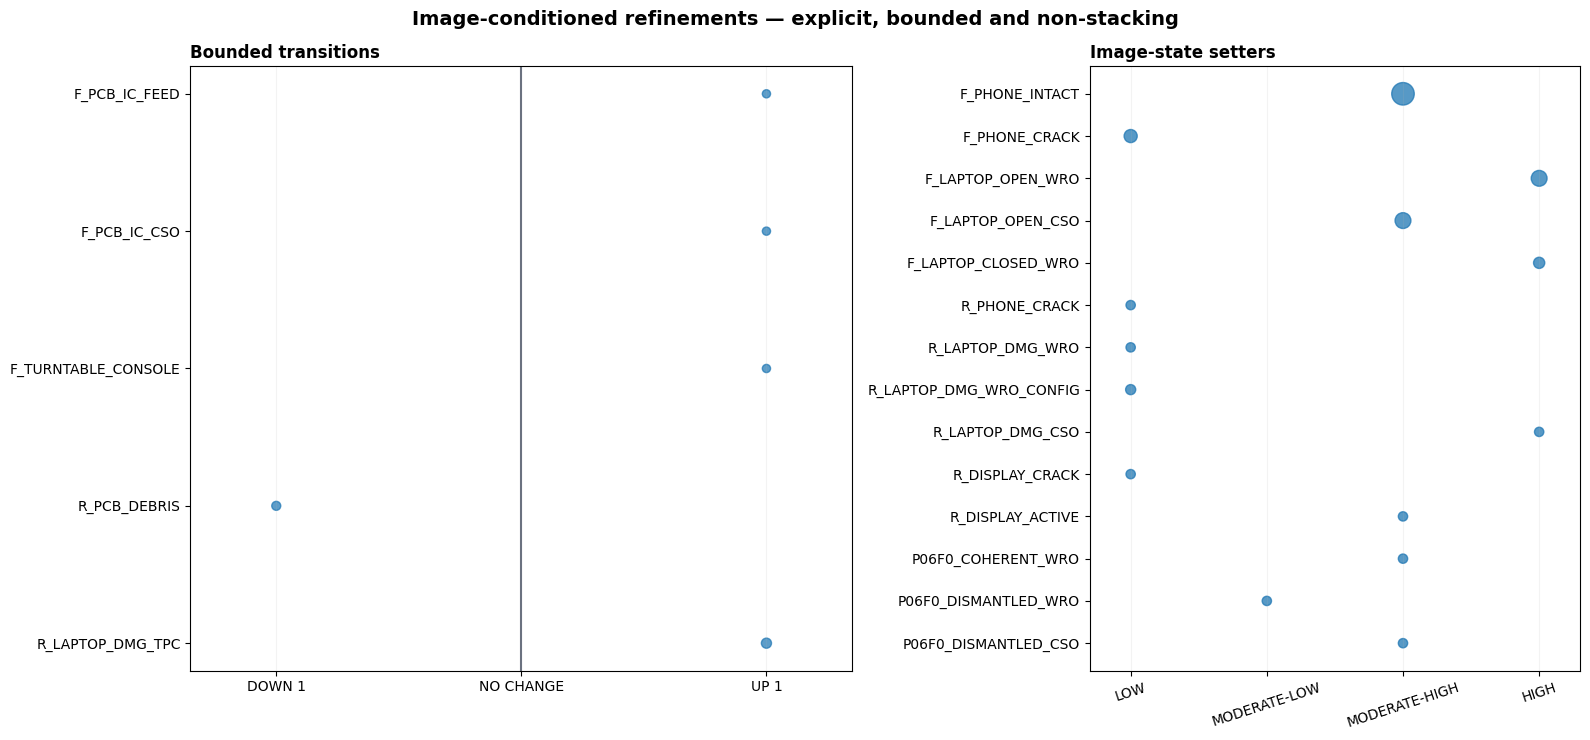

In [24]:
mods=[]
for r in all_rules[(all_rules.target_kind.eq('criterion'))&all_rules.central_policy.isin(['CENTRAL','CENTRAL_WITH_NO_EFFECT_SENSITIVITY'])].itertuples(index=False):
    m=criterion_rule_masks[r.rule_id]
    if m.any():mods.append({'rule_id':r.rule_id,'dimension':r.target_id.split('_')[0],'action':r.action,'images':int(m.sum()),'stage':r.stage})
central_transition_activity=pd.DataFrame(mods)
central_transition_activity['transition']=central_transition_activity.action.map({'DOWN_1':-1,'NO_CHANGE':0,'UP_1':1})
central_transition_activity['set_level']=central_transition_activity.action.map(lambda x:int(str(x).split('_')[1]) if str(x).startswith('SET_') else np.nan)
delta=central_transition_activity[central_transition_activity.transition.notna()];setting=central_transition_activity[central_transition_activity.set_level.notna()]
fig,axes=plt.subplots(1,2,figsize=(16,7.5),gridspec_kw={'width_ratios':[1.35,1]})
ax=axes[0];y=np.arange(len(delta));ax.scatter(delta.transition,y,s=np.clip(delta.images,35,450),alpha=.72);ax.axvline(0,color='#6B7280');ax.set_xlim(-1.35,1.35);ax.set_xticks([-1,0,1],['DOWN 1','NO CHANGE','UP 1']);ax.set_yticks(y,delta.rule_id);ax.invert_yaxis();ax.set_title('Bounded transitions',loc='left',fontweight='bold');ax.grid(axis='x',alpha=.15)
ax=axes[1];y=np.arange(len(setting));ax.scatter(setting.set_level,y,s=np.clip(setting.images,45,450),alpha=.75);ax.set_xlim(.7,4.3);ax.set_xticks([1,2,3,4],[LEVEL_LABEL[i] for i in [1,2,3,4]],rotation=18);ax.set_yticks(y,setting.rule_id);ax.invert_yaxis();ax.set_title('Image-state setters',loc='left',fontweight='bold');ax.grid(axis='x',alpha=.15)
fig.suptitle('Image-conditioned refinements — explicit, bounded and non-stacking',fontweight='bold',fontsize=14);fig.tight_layout();fig.savefig(FIGURES/'03_image_conditioned_transition_map.png',dpi=190,bbox_inches='tight');plt.show()

## Gambar 4 — Evidence provenance

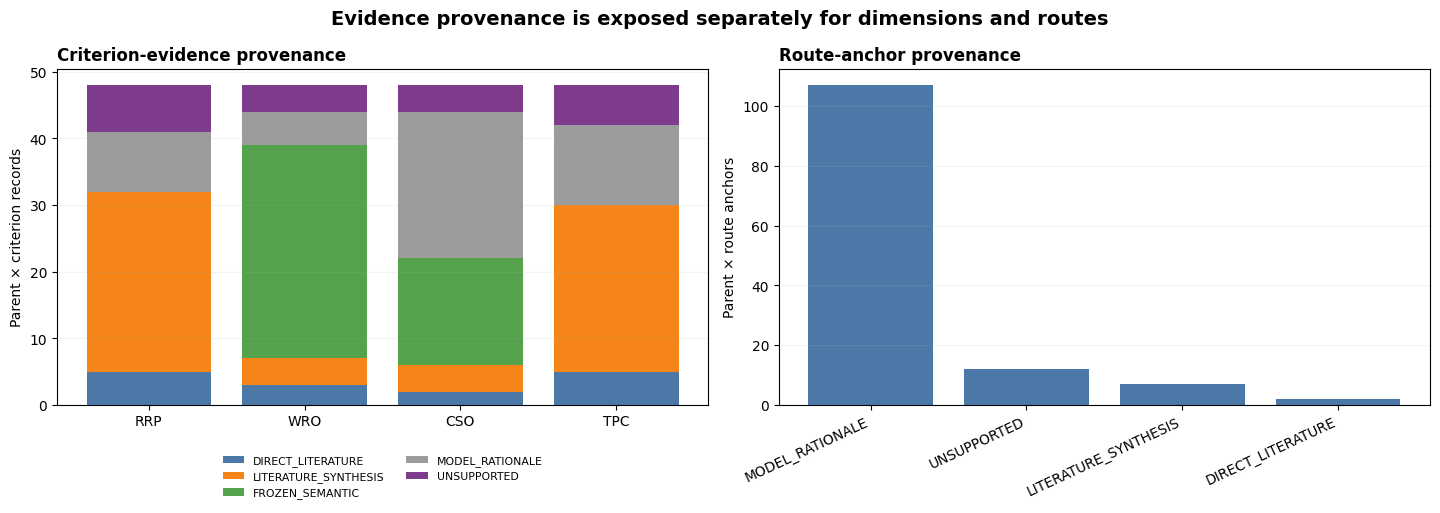

In [25]:
crit=(criterion_evidence_map.groupby(['score_dimension','anchor_origin']).size().unstack(fill_value=0).reindex(PRIMARY_DIMS))
rprov=parent_route_affinity_map.groupby('anchor_origin').size().sort_values(ascending=False)
fig,axes=plt.subplots(1,2,figsize=(14.5,5.8))
bottom=np.zeros(len(crit));x=np.arange(len(crit))
origin_order=['DIRECT_LITERATURE','LITERATURE_SYNTHESIS','FROZEN_SEMANTIC','MODEL_RATIONALE','UNSUPPORTED']
origin_colors={'DIRECT_LITERATURE':'#4C78A8','LITERATURE_SYNTHESIS':'#F58518','FROZEN_SEMANTIC':'#54A24B','MODEL_RATIONALE':'#9C9C9C','UNSUPPORTED':'#7F3C8D'}
for origin in origin_order:
    if origin in crit.columns:
        v=crit[origin].to_numpy();axes[0].bar(x,v,bottom=bottom,label=origin,color=origin_colors[origin]);bottom+=v
axes[0].set_xticks(x,crit.index);axes[0].set_title('Criterion-evidence provenance',loc='left',fontweight='bold');axes[0].set_ylabel('Parent × criterion records');axes[0].legend(frameon=False,fontsize=7.8,ncol=2,loc='upper center',bbox_to_anchor=(.5,-.12));axes[0].grid(axis='y',alpha=.15)
axes[1].bar(np.arange(len(rprov)),rprov.to_numpy(),color='#4C78A8');axes[1].set_xticks(np.arange(len(rprov)),rprov.index,rotation=25,ha='right');axes[1].set_title('Route-anchor provenance',loc='left',fontweight='bold');axes[1].set_ylabel('Parent × route anchors');axes[1].grid(axis='y',alpha=.15)
fig.suptitle('Evidence provenance is exposed separately for dimensions and routes',fontweight='bold',fontsize=14);fig.tight_layout(rect=(0,.08,1,1));fig.savefig(FIGURES/'04_evidence_provenance.png',dpi=190,bbox_inches='tight');plt.show()

## Gambar 5 — Route compatibility atlas

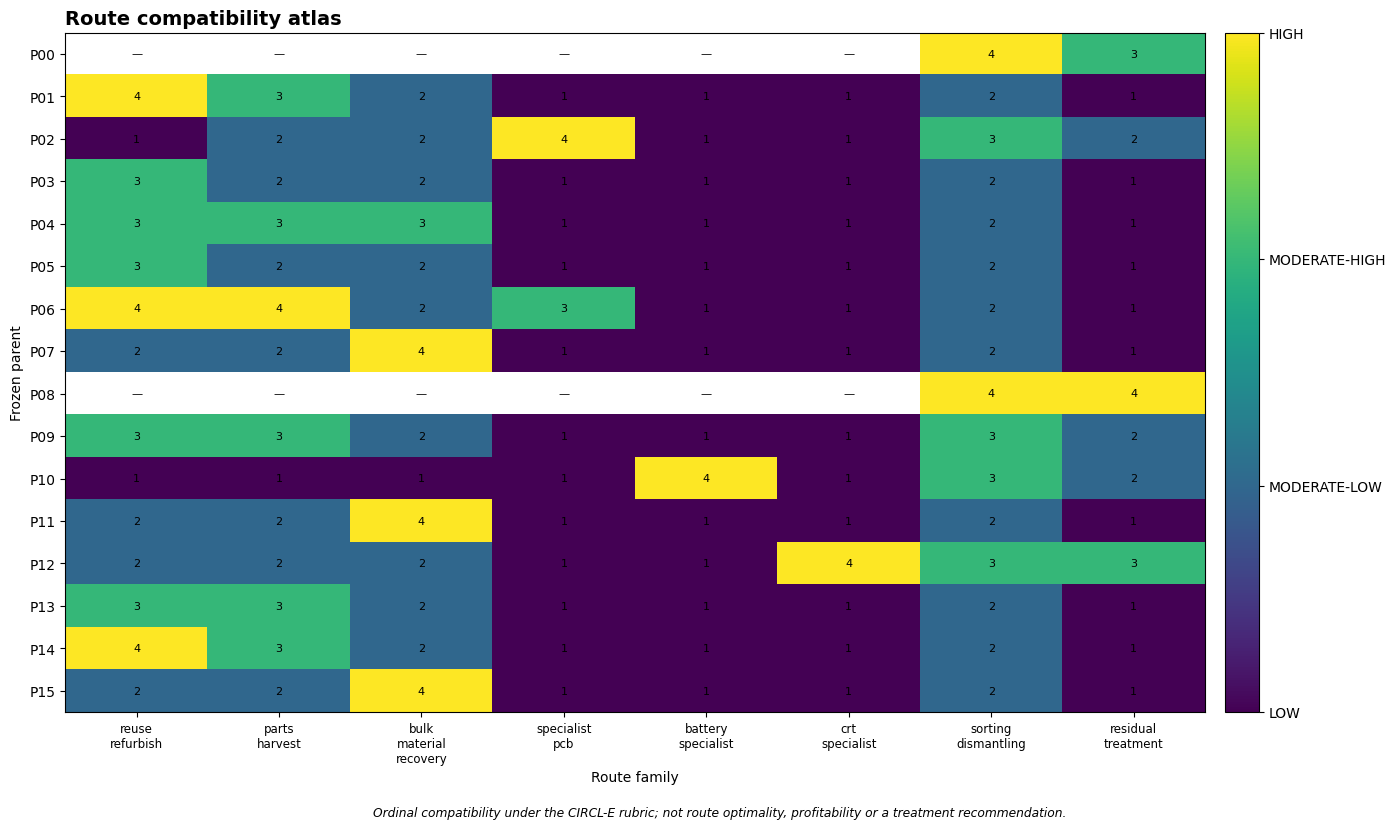

,anchor_origin,anchors
2,MODEL_RATIONALE,107
3,UNSUPPORTED,12
1,LITERATURE_SYNTHESIS,7
0,DIRECT_LITERATURE,2


,parent_id,route_id,anchor_origin,source_ids,support_logic,fallback_action
8,1,reuse_refurbish,LITERATURE_SYNTHESIS,"[E002, E012]",PRIMARY_REQUIRED,ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE
19,2,specialist_pcb,DIRECT_LITERATURE,"[E005, E009]",ALL,ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE
24,3,reuse_refurbish,LITERATURE_SYNTHESIS,"[E002, E011]",PRIMARY_REQUIRED,ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE
32,4,reuse_refurbish,LITERATURE_SYNTHESIS,"[E002, E011]",PRIMARY_REQUIRED,ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE
40,5,reuse_refurbish,LITERATURE_SYNTHESIS,"[E002, E011]",PRIMARY_REQUIRED,ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE
48,6,reuse_refurbish,LITERATURE_SYNTHESIS,"[E002, E011]",PRIMARY_REQUIRED,ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE
72,9,reuse_refurbish,LITERATURE_SYNTHESIS,"[E002, E011]",PRIMARY_REQUIRED,ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE
84,10,battery_specialist,LITERATURE_SYNTHESIS,"[E006, E013]",PRIMARY_REQUIRED,ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE
101,12,crt_specialist,DIRECT_LITERATURE,[E008],PRIMARY_REQUIRED,ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE


In [26]:
route_matrix=(parent_route_affinity_map.pivot(index='parent_id',columns='route_id',values='reference_level').reindex(index=range(16),columns=ROUTES))
fig,ax=plt.subplots(figsize=(14.5,8.3))
arr=route_matrix.to_numpy(dtype=float)
masked=np.ma.masked_invalid(arr)
im=ax.imshow(masked,aspect='auto',vmin=1,vmax=4)
ax.set_xticks(range(len(ROUTES)),[r.replace('_','\n') for r in ROUTES],fontsize=8.5)
ax.set_yticks(range(16),[f'P{i:02d}' for i in range(16)])
for y in range(arr.shape[0]):
    for x in range(arr.shape[1]):
        if np.isfinite(arr[y,x]): ax.text(x,y,int(arr[y,x]),ha='center',va='center',fontsize=8)
        else: ax.text(x,y,'—',ha='center',va='center',fontsize=8)
cb=fig.colorbar(im,ax=ax,pad=.015,ticks=[1,2,3,4]);cb.ax.set_yticklabels([LEVEL_LABEL[i] for i in [1,2,3,4]])
ax.set_title('Route compatibility atlas',loc='left',fontweight='bold',fontsize=14)
ax.set_xlabel('Route family');ax.set_ylabel('Frozen parent')
fig.text(.5,.01,'Ordinal compatibility under the CIRCL-E rubric; not route optimality, profitability or a treatment recommendation.',ha='center',fontsize=8.8,style='italic')
fig.tight_layout(rect=(0,.03,1,1));fig.savefig(FIGURES/'05_route_compatibility_atlas.png',dpi=190,bbox_inches='tight');plt.show()

route_provenance_summary=(parent_route_affinity_map.groupby('anchor_origin').size().rename('anchors').reset_index().sort_values('anchors',ascending=False))
display(route_provenance_summary)
display(parent_route_affinity_map[parent_route_affinity_map.support_review_status.eq('MANUALLY_REVIEWED_2026-09-26')][['parent_id','route_id','anchor_origin','source_ids','support_logic','fallback_action']])

## Gambar 6 — Sensitivity / robustness

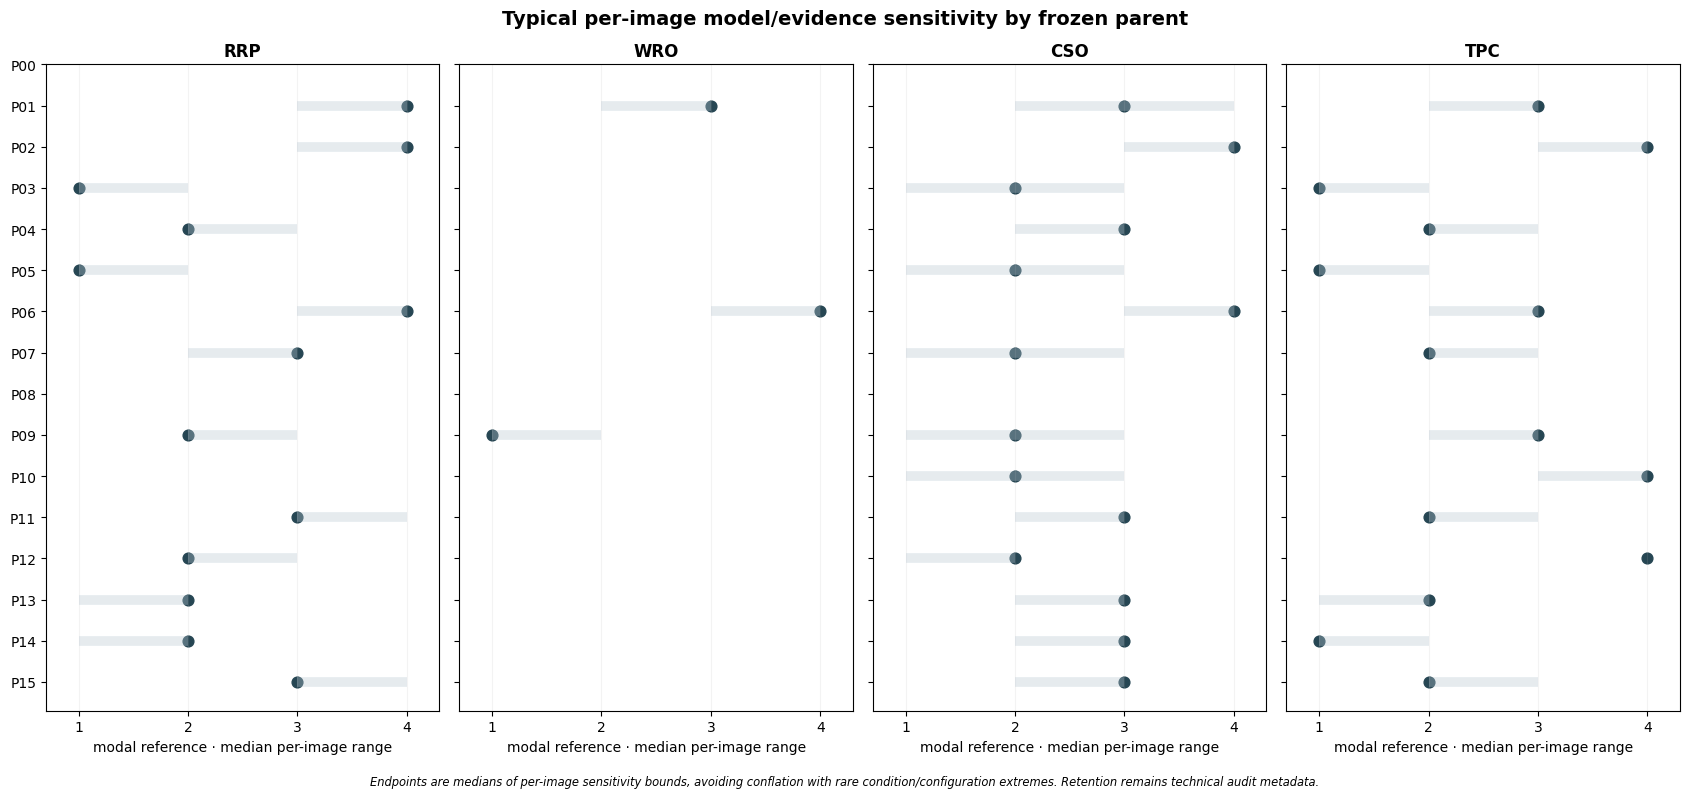

In [27]:
parent_sens=[]
for pid in range(16):
    g=profile[profile.raw_parent_id.eq(pid)]
    for dim in PRIMARY_DIMS:
        rr=g[f'{dim}_reference_level'].dropna();lo_s=g[f'{dim}_model_min'].dropna();hi_s=g[f'{dim}_model_max'].dropna();ret_s=g[f'{dim}_reference_level_retention'].dropna()
        ref=safe_mode(rr)
        lo=np.nan if len(lo_s)==0 else int(np.clip(np.rint(lo_s.median()),1,4))
        hi=np.nan if len(hi_s)==0 else int(np.clip(np.rint(hi_s.median()),1,4))
        if pd.notna(ref) and pd.notna(lo): lo=min(int(lo),int(ref))
        if pd.notna(ref) and pd.notna(hi): hi=max(int(hi),int(ref))
        ret=float(ret_s.median()) if len(ret_s) else np.nan
        parent_sens.append({'parent_id':pid,'dimension':dim,'reference':ref,'typical_min':lo,'typical_max':hi,'reference_level_retention':ret})
parent_sensitivity=pd.DataFrame(parent_sens)
fig,axes=plt.subplots(1,4,figsize=(17,8),sharey=True)
for ax,dim in zip(axes,PRIMARY_DIMS):
    d=parent_sensitivity[parent_sensitivity.dimension.eq(dim)]
    for _,r in d.iterrows():
        y=int(r.parent_id)
        if pd.notna(r.reference):
            ax.hlines(y,r.typical_min,r.typical_max,lw=7,alpha=.35,color='#B8C7D1');ax.scatter(r.reference,y,s=60,color='#264653')
    ax.set_xlim(.7,4.3);ax.set_xticks([1,2,3,4]);ax.set_title(dim,fontweight='bold');ax.grid(axis='x',alpha=.15);ax.set_xlabel('modal reference · median per-image range')
axes[0].set_yticks(range(16),[f'P{i:02d}' for i in range(16)]);axes[0].invert_yaxis();fig.suptitle('Typical per-image model/evidence sensitivity by frozen parent',fontweight='bold',fontsize=14)
fig.text(.5,.01,'Endpoints are medians of per-image sensitivity bounds, avoiding conflation with rare condition/configuration extremes. Retention remains technical audit metadata.',ha='center',fontsize=8.3,style='italic')
fig.tight_layout(rect=(0,.03,1,1));fig.savefig(FIGURES/'06_sensitivity_robustness.png',dpi=190,bbox_inches='tight');plt.show()

## Gambar 7 — Representative image/profile cards

Stage-2 handoff menyimpan canonical image path, ID, dan semantic fields tetapi tidak mengemas source-image bytes. Karena itu, card mengidentifikasi frozen record melalui canonical ID dan source filename; notebook ini tidak mengklaim pixel-level re-verification.

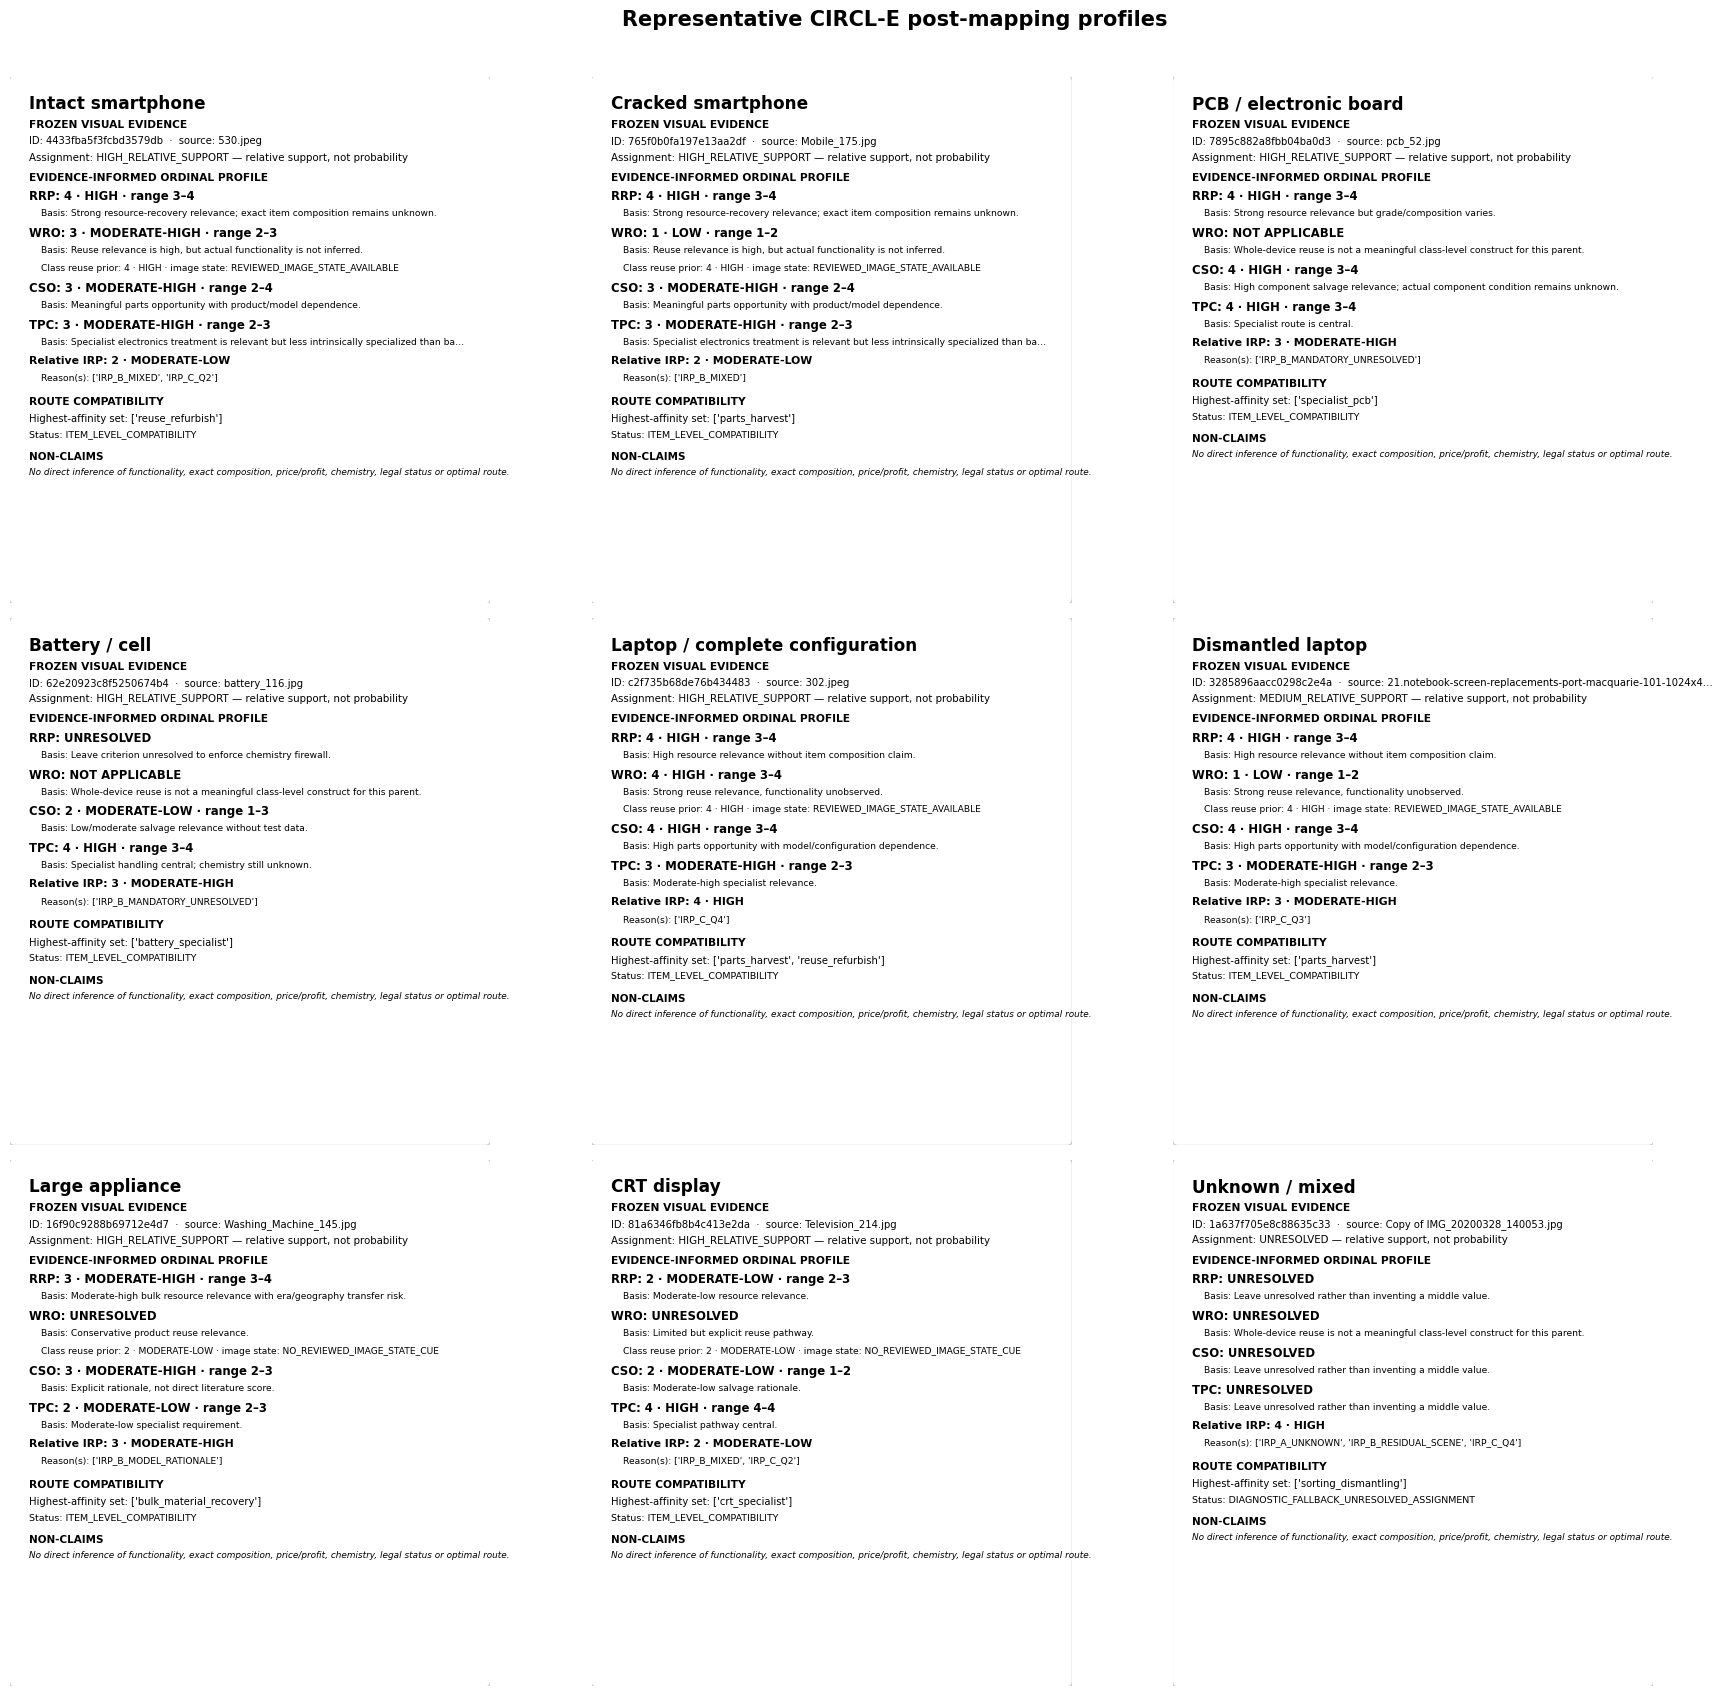

In [28]:
def pick(parent=None,fine=None,raw=None,unknown=False,exclude_raw=None):
    g=profile.copy()
    if unknown:
        g=g[g.discovery_status.eq('unknown_mixed')]
    else:
        g=g[g.raw_parent_id.eq(parent)&g.discovery_status.ne('unknown_mixed')]
        if fine is not None:g=g[g.validated_fine_group_id.eq(fine)]
        if raw is not None:g=g[g.raw_visual_leaf_id.eq(raw)]
        if exclude_raw is not None:g=g[~g.raw_visual_leaf_id.isin(exclude_raw)]
    return g.sort_values(['parent_assignment_support_score','canonical_id'],ascending=[False,True]).iloc[0]

def short_text(x,n=78):
    s=str(x)
    return s if len(s)<=n else s[:n-1]+'…'

examples=[
 ('Intact smartphone',pick(1,fine=0)),('Cracked smartphone',pick(1,fine=1)),('PCB / electronic board',pick(2)),
 ('Battery / cell',pick(10)),('Laptop / complete configuration',pick(6,exclude_raw=[23])),('Dismantled laptop',pick(6,raw=23)),
 ('Large appliance',pick(11)),('CRT display',pick(12)),('Unknown / mixed',pick(unknown=True))]
fig,axs=plt.subplots(3,3,figsize=(18,17));axs=np.ravel(axs)
for ax,(title,r) in zip(axs,examples):
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((.01,.01),.98,.98,boxstyle='round,pad=.012',facecolor='white',edgecolor='#C9CED6',linewidth=1.1))
    ax.text(.04,.965,title,fontsize=12.2,fontweight='bold',va='top')
    ax.text(.04,.918,'FROZEN VISUAL EVIDENCE',fontsize=7.7,fontweight='bold',va='top')
    ax.text(.04,.887,f'ID: {r.canonical_id}  ·  source: {short_text(r.filename,58)}',fontsize=7.2,va='top')
    ax.text(.04,.858,f'Assignment: {r.assignment_support_state} — relative support, not probability',fontsize=7.4,va='top')
    ax.text(.04,.818,'EVIDENCE-INFORMED ORDINAL PROFILE',fontsize=7.7,fontweight='bold',va='top')
    y=.785
    for dim in ['RRP','WRO','CSO','TPC']:
        ref=r[f'{dim}_reference_level']
        if dim=='WRO' and pd.isna(ref) and str(r.WRO_profile_status).startswith('NOT_APPLICABLE'):
            lab='NOT APPLICABLE'; rng=''
        else:
            lab='UNRESOLVED' if pd.isna(ref) else f'{int(ref)} · {LEVEL_LABEL[int(ref)]}'
            rng='' if pd.isna(ref) else f" · range {int(r[f'{dim}_model_min'])}–{int(r[f'{dim}_model_max'])}"
        ax.text(.04,y,f'{dim}: {lab}{rng}',fontsize=8.35,fontweight='bold',va='top');y-=.036
        driver_list=r[f'{dim}_main_drivers'] if isinstance(r[f'{dim}_main_drivers'],list) else []
        if driver_list:
            ax.text(.065,y,'Basis: '+short_text(driver_list[0],88),fontsize=6.6,va='top');y-=.034
        if dim=='WRO' and r.whole_device_reuse_applicability=='WHOLE_DEVICE':
            cl='UNRESOLVED' if pd.isna(r.WRO_class_reuse_anchor_level) else f"{int(r.WRO_class_reuse_anchor_level)} · {r.WRO_class_reuse_anchor_label}"
            ax.text(.065,y,f'Class reuse prior: {cl} · image state: {r.WRO_image_state_status}',fontsize=6.6,va='top');y-=.034
    ax.text(.04,y,f'Relative IRP: {int(r.IRP_reference_level)} · {r.IRP_reference_label}',fontsize=7.8,fontweight='bold',va='top');y-=.034
    ax.text(.065,y,'Reason(s): '+short_text(r.IRP_main_reason_set,92),fontsize=6.6,va='top');y-=.044
    ax.text(.04,y,'ROUTE COMPATIBILITY',fontsize=7.7,fontweight='bold',va='top');y-=.032
    ax.text(.04,y,'Highest-affinity set: '+short_text(r.highest_affinity_route_set,84),fontsize=7.2,va='top');y-=.031
    ax.text(.04,y,f'Status: {r.route_profile_status}',fontsize=6.8,va='top');y-=.043
    ax.text(.04,y,'NON-CLAIMS',fontsize=7.5,fontweight='bold',va='top');y-=.030
    ax.text(.04,y,'No direct inference of functionality, exact composition, price/profit, chemistry, legal status or optimal route.',fontsize=6.4,style='italic',va='top',wrap=True)
fig.suptitle('Representative CIRCL-E post-mapping profiles',fontsize=15,fontweight='bold',y=.995)
fig.tight_layout(rect=(0,0,1,.985));fig.savefig(FIGURES/'07_representative_profile_cards.png',dpi=185,bbox_inches='tight');plt.show()

# Bagian I — Validation, export, dan reproducibility

## I1. Scientific dan integrity validation

In [29]:
validation=[]
def check(name,condition,detail=''):
    ok=bool(condition);validation.append({'check':name,'status':'PASS' if ok else 'FAIL','detail':detail})
    if not ok:raise AssertionError(f'{name}: {detail}')

zip_sha_matches_reference = actual_sha == EXPECTED_STAGE2_SHA256
check(
    'Stage-2 ZIP SHA policy satisfied',
    zip_sha_matches_reference or not STRICT_STAGE2_ZIP_SHA,
    (
        'Exact SHA-256 match.'
        if zip_sha_matches_reference
        else (
            f'Observed ZIP SHA-256 {actual_sha} differs from reference '
            f'{EXPECTED_STAGE2_SHA256}; strict ZIP SHA validation is disabled, '
            'so integrity is enforced by the internal manifest checks.'
        )
    ),
)
check('Frozen 16/28/48 structure preserved',counts=={'fine':28,'parent':16,'raw_visual':48})
check('3793 canonical images preserved',len(profile)==3793 and profile.canonical_id.is_unique)
check('Non-self manifest hashes preserved',len(non_self_bad)==0)
check('Primary dimensions are the approved disentangled set',PRIMARY_DIMS==['RRP','WRO','CSO','TPC'])
check('RRP unresolved whenever RRP-A unresolved',profile.loc[profile.RRP_A_resource_relevance.isna(),'RRP_reference_level'].isna().all())
check('Battery generic RRP remains unresolved without chemistry-dependent resource relevance',profile.loc[profile.raw_parent_id.eq(10),'RRP_reference_level'].isna().all())
check('Battery whole-device WRO is N/A at component level',profile.loc[profile.raw_parent_id.eq(10),'WRO_reference_level'].isna().all() and profile.loc[profile.raw_parent_id.eq(10)&profile.discovery_status.ne('unknown_mixed'),'WRO_profile_status'].eq('NOT_APPLICABLE_COMPONENT_LEVEL').all())
check('WRO requires image-state evidence',profile.loc[profile.WRO_B_visual_integrity.isna()&profile.WRO_C_configuration_completeness.isna(),'WRO_reference_level'].isna().all())
check('CSO requires salvage relevance',profile.loc[profile.CSO_A_component_salvage.isna(),'CSO_reference_level'].isna().all())
check('PCB whole-device WRO is N/A while CSO remains high',profile.loc[profile.raw_parent_id.eq(2),'WRO_reference_level'].isna().all() and profile.loc[profile.raw_parent_id.eq(2)&profile.discovery_status.ne('unknown_mixed'),'WRO_profile_status'].eq('NOT_APPLICABLE_COMPONENT_LEVEL').all() and profile.loc[profile.raw_parent_id.eq(2),'CSO_reference_level'].dropna().median()>=3)
check('Dismantled laptop raw leaf lowers WRO when active',profile.loc[profile.raw_visual_leaf_id.eq(23),'WRO_reference_level'].dropna().max()<=2)
check('Dismantled laptop raw leaf preserves/highlights CSO',profile.loc[profile.raw_visual_leaf_id.eq(23),'CSO_reference_level'].dropna().min()>=3)
check('Visual condition rules cannot modify RRP',not semantic_transition_registry[(semantic_transition_registry.target_kind.eq('criterion'))&semantic_transition_registry.target_id.str.startswith('RRP')].rule_id.str.contains('CRACK|DMG|CONDITION',case=False,regex=True).any())
check('Parent support percentile is within parent',assignment.loc[active].groupby('raw_parent_id').parent_support_percentile_within_parent.max().round(12).eq(1).all())
check('Support explicitly not probability',not assignment.support_is_calibrated_probability.any())
check('Support not used to widen model/evidence ranges',not any('support_range_broadening' in c for c in profile.columns))
check('Reference retention never named probability',not any('probability' in c.lower() for c in profile.columns if 'retention' in c.lower()))
check('IRP rules fully registered',len(irp_rule_registry)>=15 and irp_rule_registry.origin.notna().all())
check('IRP uses maximum diagnostic need',(profile.IRP_reference_level==profile[['IRP_A_assignment_resolution','IRP_B_semantic_evidence_resolution','IRP_C_visual_atypicality_inventory']].max(axis=1)).all())
check('Patch affects no central RRP/WRO/CSO/TPC rule',not any('patch' in str(x).lower() for x in pd.concat([semantic_transition_registry.rationale,continuous_transition_registry.rationale])))
check('Global ICA factor1 has no transition rule',not ((continuous_transition_registry.scope.eq('global'))&(continuous_transition_registry.factor_id.eq(1))).any())
check('Battery morphology does not create chemistry output',not any('chemistry' in c.lower() for c in profile.columns))
check('Generic PCB composition leakage absent',not any('composition' in c.lower() or 'mobile_phone_pcb' in c.lower() for c in profile.columns))
check('Unknown mixed abstains on all primary dimensions',profile.loc[profile.discovery_status.eq('unknown_mixed'),[f'{d}_reference_level' for d in PRIMARY_DIMS]].isna().all().all())
check('Unknown mixed retains IRP',profile.loc[profile.discovery_status.eq('unknown_mixed'),'IRP_reference_level'].notna().all())
check('Residual/scene item profiles abstain',profile.loc[profile.raw_parent_id.isin([0,8]),[f'{d}_reference_level' for d in PRIMARY_DIMS]].isna().all().all())
check('Fine rules require operational reliable fine assignment',all((~((criterion_rule_masks if r.target_kind=='criterion' else route_rule_masks)[r.rule_id]) | assignment.discovery_status.eq('reliable_parent_and_fine_group').to_numpy()).all() for r in semantic_transition_registry[semantic_transition_registry.stage.eq('fine')].itertuples(index=False)))
check('Nuisance structures have exact zero central effects',semantic_permission_registry.loc[semantic_permission_registry.nuisance_zero_effect_required,'central_effect_rule_ids'].map(len).eq(0).all())
check('Every primary criterion has anchor origin',criterion_evidence_map.anchor_origin.notna().all())
check('Every route anchor has anchor origin',parent_route_affinity_map.anchor_origin.notna().all())
check('Every literature criterion anchor has registered sources',criterion_evidence_map[criterion_evidence_map.anchor_origin.isin(['DIRECT_LITERATURE','LITERATURE_SYNTHESIS'])].source_ids.map(lambda x:len(x)>0 and set(x).issubset(set(source_registry.source_id))).all())
check('Every literature route anchor has registered sources',parent_route_affinity_map[parent_route_affinity_map.anchor_origin.isin(['DIRECT_LITERATURE','LITERATURE_SYNTHESIS'])].source_ids.map(lambda x:len(x)>0 and set(x).issubset(set(source_registry.source_id))).all())
check('Central sources retain verification status',source_registry.verification_status.notna().all())
check('Central sources retain exact locator text',source_registry.exact_locator.fillna('').str.len().gt(5).all())
check('External source system boundaries are explicit',source_registry.system_boundary.fillna('').str.len().gt(5).all())
check('Synthesis criterion anchors specify support logic',criterion_evidence_map[criterion_evidence_map.anchor_origin.eq('LITERATURE_SYNTHESIS')].support_logic.isin(['PRIMARY_REQUIRED','ALL','PRIMARY_PLUS_CORROBORATION','AT_LEAST_N']).all())
check('Synthesis route anchors specify support logic',parent_route_affinity_map[parent_route_affinity_map.anchor_origin.eq('LITERATURE_SYNTHESIS')].support_logic.isin(['PRIMARY_REQUIRED','ALL','PRIMARY_PLUS_CORROBORATION','AT_LEAST_N']).all())
check('MODEL_RATIONALE remains visible',criterion_evidence_map[criterion_evidence_map.anchor_origin.eq('MODEL_RATIONALE')].rationale.str.len().gt(10).all())
check('All finite primary levels ordinal',all(profile[f'{d}_reference_level'].dropna().astype(float).isin([1,2,3,4]).all() for d in PRIMARY_DIMS))
check('All finite model ranges ordinal',all(profile[f'{d}_model_min'].dropna().astype(float).isin([1,2,3,4]).all() and profile[f'{d}_model_max'].dropna().astype(float).isin([1,2,3,4]).all() for d in PRIMARY_DIMS))
check('Reference retention bounded 0-1',all(profile[f'{d}_reference_level_retention'].dropna().between(0,1).all() for d in PRIMARY_DIMS))
check('Shared evidence state arrays are one per parent/criterion/scenario',len(anchor_scen)==16*12 and all(len(v)==N_SCENARIOS for v in anchor_scen.values()))
check('Unresolved image-state anchors do not invent sensitivity states',all(np.isnan(np.asarray(anchor_scen[(int(r.parent_id),r.criterion_id)],dtype=float)).all() for r in criterion_evidence_map[pd.isna(criterion_evidence_map.reference_level)&criterion_evidence_map.anchor_origin.eq('FROZEN_SEMANTIC')].itertuples(index=False)))
check('Route compatibility finite states ordinal',all(route_reference[r].dropna().astype(float).isin([1,2,3,4]).all() for r in ROUTES))
check('Route ties preserved as sets',profile.highest_affinity_route_set.map(lambda x:isinstance(x,list)).all())
check('Route reference-set retention bounded 0-1',profile.route_reference_set_retention.dropna().between(0,1).all())
check('Source ablation recomputed under support logic',len(source_ablation_results)==len(source_registry)*4 and source_ablation_results.changed_images.ge(0).all())
check('Route source ablation recomputed under support logic',len(route_source_ablation_results)==len(source_registry) and route_source_ablation_results.changed_route_sets.ge(0).all())
check('Leave-one-criterion-out executed',len(leave_one_criterion_out)==12)
check('Attribute-stage ablation executed',set(attribute_ablation.stage)=={'parent','fine','raw_visual','full_identity'})
check('WRO/CSO sensitivity reported',set(wro_cso_sensitivity.dimension)=={'WRO','CSO'})
check('Global factor1 off audit zero',global_ica1_off_ablation.filter(like='changed_').to_numpy().sum()==0)
check('No primary monetary/currency fields',not any(re.search(r'price|currency|usd|idr|profit|payout',c,re.I) for c in profile.columns))
check('No authoritative language in primary schema',not any('authoritative' in c.lower() for c in profile.columns))
check('No downstream feedback into frozen IDs',profile.canonical_id.equals(assignment.canonical_id) and profile.raw_parent_id.equals(assignment.raw_parent_id))

# Evidence, provenance and presentation checks.
external_crit=criterion_evidence_map[criterion_evidence_map.anchor_origin.isin(['DIRECT_LITERATURE','LITERATURE_SYNTHESIS'])]
external_route=parent_route_affinity_map[parent_route_affinity_map.anchor_origin.isin(['DIRECT_LITERATURE','LITERATURE_SYNTHESIS'])]
check('Every external criterion anchor manually reviewed',external_crit.support_review_status.eq('MANUALLY_REVIEWED_2026-09-26').all())
check('Every external route anchor manually reviewed',external_route.support_review_status.eq('MANUALLY_REVIEWED_2026-09-26').all())
check('No context-only source is classified primary',all(set(dict(r.source_roles).keys())==set(r.source_ids) and not (set(r.context_only_source_ids)&set(r.primary_required_source_ids)) for r in pd.concat([external_crit,external_route],ignore_index=True).itertuples(index=False)))
check('Support logic unit tests pass',all(support_logic_unit_tests.values()))
check('Claim ablation supports all four declared outcomes',{'ANCHOR_SURVIVES_UNCHANGED','ANCHOR_SURVIVES_BUT_BROADENS','ANCHOR_DOWNGRADES_TO_MODEL_RATIONALE','ANCHOR_BECOMES_UNSUPPORTED'}.issubset(set(claim_source_ablation_detail.ablation_outcome)))
check('Unknown-mixed sorting fallback registered',((route_resolution_rule_registry.rule_id=='ROUTE_UNKNOWN_SORTING')&(route_resolution_rule_registry.level==4)).any())
check('Unknown-mixed residual fallback registered',((route_resolution_rule_registry.rule_id=='ROUTE_UNKNOWN_RESIDUAL')&(route_resolution_rule_registry.level==3)).any())
check('Unknown product-specific route clearing registered',(route_resolution_rule_registry.rule_id=='ROUTE_UNKNOWN_CLEAR_PRODUCT_SPECIFIC').any())
check('Unknown route outputs match registry',profile.loc[profile.discovery_status.eq('unknown_mixed'),'sorting_dismantling'].eq(4).all() and profile.loc[profile.discovery_status.eq('unknown_mixed'),'residual_treatment'].eq(3).all())
check('Unresolved WRO preserves separate class anchor when applicable',profile.loc[profile.WRO_profile_status.eq('UNRESOLVED_IMAGE_STATE'),'WRO_class_reuse_anchor_level'].notna().all())
check('Component-level WRO suppresses class reuse output',profile.loc[profile.WRO_profile_status.eq('NOT_APPLICABLE_COMPONENT_LEVEL'),'WRO_class_reuse_anchor_level'].isna().all())
check('IRP tied max reasons preserved',irp.IRP_main_reason_set.map(lambda x:isinstance(x,list) and len(x)>=1).all())
check('IRP methodology is relative triage',True,'Verified in exported methodology text during export validation.')
check('Primary human drivers are readable text',all(profile[f'{d}_main_drivers'].map(lambda x:isinstance(x,list) and all(isinstance(y,str) and len(y)>8 for y in x)).all() for d in PRIMARY_DIMS))


# Release checks for date semantics and evidence dependency.
e002=source_registry.set_index('source_id').loc['E002'];e003=source_registry.set_index('source_id').loc['E003']
check('E002 publication and consolidation dates are separated',e002.publication_date=='2012-07-24' and e002.consolidation_date=='2024-04-08')
check('E003 effective date is not mislabelled as publication date',pd.isna(e003.publication_date) and e003.effective_date=='2025-01-01')
e001_rrp=source_ablation_results[(source_ablation_results.source_id.eq('E001'))&(source_ablation_results.dimension.eq('RRP'))].iloc[0]
check('E001 RRP dependency is recomputed and quantified',int(e001_rrp.newly_unresolved_images)==2113 and int(e001_rrp.changed_images)==2113)
check('Representative source-image bytes are not falsely assumed available',True,'Stage-2 package contains visual-summary figures but not original source-image bytes; cards retain IDs/filenames only.')

score_validation=pd.DataFrame(validation);display(score_validation.groupby('status').size().rename('checks').to_frame());failures=score_validation[score_validation.status.ne('PASS')];
if len(failures): display(failures)
print(f'Validation: {(score_validation.status=="PASS").sum()}/{len(score_validation)} PASS — full table exported.')

,checks
status,
PASS,74


Validation: 74/74 PASS — full table exported.


## I2. Primary export dan technical audit tables

In [30]:
# Ekspor tabel utama dan technical audit tables.
def csv_ready(df):
    out=df.copy()
    for c in out.columns:
        if out[c].dtype=='object':out[c]=out[c].map(lambda x:json.dumps(x,ensure_ascii=False) if isinstance(x,(list,dict)) else x)
    return out

# Product-facing compact profile: retention is deliberately excluded and remains technical audit metadata.
PRIMARY_COLS=['canonical_id','raw_parent_id','validated_fine_group_id','raw_visual_leaf_id','discovery_status','parent_assignment_support_score','parent_support_percentile_within_parent','assignment_support_state','fine_assignment_support_score','fine_support_percentile_within_fine','mapped_device_family','mapped_device_subtype','mapped_component_type','mapped_condition','mapped_configuration']
for dim in ['RRP']:
    PRIMARY_COLS += [f'{dim}_reference_level',f'{dim}_label',f'{dim}_model_min',f'{dim}_model_max',f'{dim}_anchor_origin_summary',f'{dim}_main_drivers']
PRIMARY_COLS += ['whole_device_reuse_applicability','WRO_class_reuse_anchor_level','WRO_class_reuse_anchor_label','WRO_class_reuse_anchor_origin','WRO_image_state_status','WRO_reference_level','WRO_label','WRO_model_min','WRO_model_max','WRO_profile_status','WRO_main_drivers']
for dim in ['CSO','TPC']:
    PRIMARY_COLS += [f'{dim}_reference_level',f'{dim}_label',f'{dim}_model_min',f'{dim}_model_max',f'{dim}_anchor_origin_summary',f'{dim}_main_drivers']
PRIMARY_COLS += ['IRP_reference_level','IRP_reference_label','IRP_main_reason_set','highest_affinity_route_set','highest_affinity_level','route_profile_status','route_evidence_origin_summary','profile_status','nonclaims']
primary_profile=profile[PRIMARY_COLS].copy()
primary_profile['IRP_label']=primary_profile['IRP_reference_label']
route_level_cols=ROUTES
primary_profile['route_affinity_summary']=[{r:(None if pd.isna(profile.at[i,r]) else int(profile.at[i,r])) for r in route_level_cols} for i in range(len(profile))]
primary_profile['main_drivers']=[{d:profile.at[i,f'{d}_main_drivers'] for d in PRIMARY_DIMS} for i in range(len(profile))]
primary_profile['main_caveats']=profile['nonclaims']

# Technical sensitivity audit: retention remains available but is explicitly secondary and non-probabilistic.
sensitivity_cols=['canonical_id']
for d in PRIMARY_DIMS:sensitivity_cols += [f'{d}_reference_level',f'{d}_model_min',f'{d}_model_max',f'{d}_reference_level_retention']
sensitivity_cols += ['route_reference_set_retention']
per_image_sensitivity_audit=profile[sensitivity_cols].copy()
per_image_sensitivity_audit['interpretation']='Retention is frequency under declared balanced sensitivity scenarios, not probability/confidence.'

# Criterion-level audit preserves image-conditioned criterion changes even when headline dimensions are unchanged.
criterion_anchor_index=criterion_evidence_map.set_index(['parent_id','criterion_id'])
rule_rows_by_criterion={cid:list(all_rules[(all_rules.target_kind.eq('criterion'))&all_rules.target_id.eq(cid)&all_rules.central_policy.isin(['CENTRAL','CENTRAL_WITH_NO_EFFECT_SENSITIVITY'])].itertuples(index=False)) for cid in ALL_PRIMARY_CRITERIA}
crit_frames=[]
parent_ids=assignment.raw_parent_id.to_numpy(dtype=int)
for cid in ALL_PRIMARY_CRITERIA:
    applied=[[] for _ in range(n)]
    for rr in rule_rows_by_criterion[cid]:
        for j in np.flatnonzero(criterion_rule_masks[rr.rule_id]): applied[j].append(rr.rule_id)
    origins=[criterion_anchor_index.loc[(int(pid),cid),'anchor_origin'] for pid in parent_ids]
    base_rationales=[criterion_anchor_index.loc[(int(pid),cid),'rationale'] for pid in parent_ids]
    human=[[rule_rationale[x] for x in ids] if ids else [base_rationales[j]] for j,ids in enumerate(applied)]
    crit_frames.append(pd.DataFrame({'canonical_id':assignment.canonical_id.to_numpy(),'parent_id':parent_ids,'dimension':cid.split('_')[0],'criterion_id':cid,'parent_anchor_level':criteria_base_ref[cid],'final_reference_level':criterion_reference[cid].to_numpy(),'anchor_origin':origins,'applied_rule_ids':applied,'human_drivers':human}))
per_image_criterion_profile=pd.concat(crit_frames,ignore_index=True)

EXPORTS={
'external_source_registry':source_registry,'criterion_definitions':criterion_definitions,'criterion_evidence_map':criterion_evidence_map,'ica_semantic_audit':ica_semantic_audit,'semantic_permission_registry':semantic_permission_registry,'semantic_transition_registry':semantic_transition_registry,'continuous_transition_registry':continuous_transition_registry,'irp_rule_registry':irp_rule_registry,'parent_route_affinity_map':parent_route_affinity_map,'route_resolution_rule_registry':route_resolution_rule_registry,
'per_image_final_ordinal_resource_profile':primary_profile,'per_image_sensitivity_audit':per_image_sensitivity_audit,'per_image_criterion_profile':per_image_criterion_profile,
'attribute_ablation_results':attribute_ablation,'leave_one_criterion_out':leave_one_criterion_out,'source_ablation_results':source_ablation_results,'claim_source_ablation_detail':claim_source_ablation_detail,'route_source_ablation_results':route_source_ablation_results,'route_source_ablation_detail':route_source_ablation_detail,'support_stratified_retention':support_stratified_retention,'global_ica1_off_ablation':global_ica1_off_ablation,'central_transition_activity':central_transition_activity,'parent_sensitivity_summary':parent_sensitivity,'score_validation':score_validation}
for name,df in EXPORTS.items():
    csv_ready(df).to_csv(DERIVED/f'{name}.csv',index=False);df.to_json(DERIVED/f'{name}.json',orient='records',indent=2,force_ascii=False)
with open(DERIVED/'per_image_final_ordinal_resource_profile.jsonl','w',encoding='utf-8') as f:
    for rec in primary_profile.to_dict('records'):
        clean={k:(None if (isinstance(v,float) and pd.isna(v)) else v) for k,v in rec.items()};f.write(json.dumps(clean,ensure_ascii=False,allow_nan=False)+'\n')

methodology='# Metodologi CIRCL-E Post-Mapping\n\nCIRCL-E Post-Mapping memetakan frozen image-only discovery menjadi dimensi decision-support ordinal yang transparan: Resource Recovery Potential (RRP), Whole-device Reuse Opportunity (WRO), Component Salvage Opportunity (CSO), Treatment Complexity / Priority (TPC), Relative Inspection / Resolution Priority (IRP), serta route compatibility. RRP membutuhkan resource-relevance evidence dan dibatasi oleh criterion tersebut. WRO dipisahkan dari CSO dan membutuhkan reviewed image-state integrity/configuration evidence selain class reuse anchor yang ditampilkan secara terpisah. Parent component-level tidak diberi whole-device reuse state secara artifisial. IRP adalah dimensi triage relatif yang dibentuk dari operational assignment state, semantic/evidence ambiguity, dan within-parent visual atypicality/inventory cues.\n\nSetiap criterion dan route anchor yang berbasis literatur memiliki dependency sumber pada level claim. Sumber broad-context tidak dapat menggantikan product/process-specific source yang diwajibkan secara diam-diam. Claim-aware source ablation membedakan anchor yang tetap sama, menjadi lebih broad, turun ke explicit model rationale, atau menjadi unsupported. Unknown-mixed route fallback dicatat sebagai MODEL_RULE yang eksplisit.\n\nAssignment support adalah within-parent routing-strength diagnostic, bukan probability. Nilai ini dilaporkan terpisah dari model/evidence range. Hierarchical sensitivity menggunakan shared parent/criterion evidence states dan shared uncertain semantic rules; unresolved image-state criteria tetap unresolved kecuali frozen semantic rule yang aktif memberikan state. Reference-level retention hanya merupakan technical robustness metadata dan bukan probability/confidence. Route output adalah compatibility/affinity state, bukan rekomendasi treatment, optimality probability, atau profitability estimate. Ordinal level bukan ratio scale.\n'
(REPORTS/'final_methodology.md').write_text(methodology)
assert 'triage relatif' in methodology.lower()
print('Exported',len(EXPORTS),'tables plus strict JSONL and methodology.')

Exported 24 tables plus strict JSONL and methodology.


## I3. Results summary, checksum, dan handoff

In [31]:
dimension_coverage = {
    dimension: int(profile[f'{dimension}_reference_level'].notna().sum())
    for dimension in PRIMARY_DIMS
}
e001_rrp = source_ablation_results[
    source_ablation_results.source_id.eq('E001')
    & source_ablation_results.dimension.eq('RRP')
].iloc[0]
e001_unresolved = int(e001_rrp.newly_unresolved_images)
e001_fraction = e001_unresolved / dimension_coverage['RRP'] if dimension_coverage['RRP'] else np.nan

results = '\n'.join([
    '# Hasil CIRCL-E Post-Mapping',
    '',
    f'Tanggal analisis: {ANALYSIS_DATE}',
    '',
    '## Upstream yang dibekukan',
    f'- Stage-2 SHA-256: `{actual_sha}`',
    f'- Frozen structures: {counts}',
    f'- Canonical images: {len(profile):,}',
    '- Numerical memberships changed: **no**',
    '- Semantic mappings changed: **no**',
    '',
    '## Dimensi ordinal decision-support',
    '- RRP — Resource Recovery Potential',
    '- WRO — Whole-device Reuse Opportunity',
    '- CSO — Component Salvage Opportunity',
    '- TPC — Treatment Complexity / Priority',
    '- IRP — Relative Inspection / Resolution Priority',
    '',
    '## Coverage',
    *[f'- {dimension} resolved: {dimension_coverage[dimension]:,} / {len(profile):,}' for dimension in PRIMARY_DIMS],
    f'- Unknown/mixed assignment abstentions: {int(profile.discovery_status.eq("unknown_mixed").sum()):,}',
    f'- WRO component-level not-applicable records: {int(profile.WRO_profile_status.eq("NOT_APPLICABLE_COMPONENT_LEVEL").sum()):,}',
    '',
    '## Arsitektur evidence',
    f'- Criterion anchors: {len(criterion_evidence_map):,}',
    f'- Literature-driven criterion anchors dengan manual claim-level dependency review: {int(criterion_evidence_map.support_review_status.eq("MANUALLY_REVIEWED_2026-09-26").sum()):,}',
    f'- Route anchors: {len(parent_route_affinity_map):,}',
    f'- Literature-driven route anchors dengan manual claim-level dependency review: {int(parent_route_affinity_map.support_review_status.eq("MANUALLY_REVIEWED_2026-09-26").sum()):,}',
    '- Route compatibility menggabungkan specialist external evidence dengan explicit model rationale.',
    '',
    '## Keterbatasan evidence dependency',
    f'- Menghapus E001 membuat {e001_unresolved:,} dari {dimension_coverage["RRP"]:,} profil RRP yang saat ini resolved menjadi unresolved ({100 * e001_fraction:.1f}%). Ini adalah dependency terhadap evidence coverage, bukan probability atau performance metric.',
    '',
    '## Validasi',
    f'- Scientific/integrity checks: **{int(score_validation.status.eq("PASS").sum())}/{len(score_validation)} PASS**',
    '',
    '## Interpretasi',
    '- Assignment support bersifat relatif dan non-probabilistic.',
    '- Model/evidence range adalah sensitivity range, bukan confidence interval.',
    '- Route value adalah compatibility/affinity state, bukan optimality atau profitability probability.',
    '- Ordinal level bukan ratio scale.',
    '',
    '## Non-claims',
    'Notebook tidak menginferensikan true mass, exact material composition, battery chemistry, functionality, repair success, recoverable yield, market value, recycler payout, profitability, legal waste status, hazard classification, atau optimal treatment route langsung dari foto.',
])
(REPORTS / 'final_results.md').write_text(results)
source_registry[[
    'source_id', 'organization', 'title', 'publication_date', 'effective_date', 'consolidation_date',
    'retrieval_date', 'date_note', 'verification_status', 'exact_locator', 'system_boundary', 'product_scope',
]].to_csv(REPORTS / 'source_verification_summary.csv', index=False)
print(results)

checks = []
for path in sorted(item for item in OUTPUTS.rglob('*') if item.is_file() and item.name != 'CIRCL_E_Post_Mapping_Handoff.zip'):
    checks.append({
        'path': str(path.relative_to(PROJECT_ROOT)),
        'sha256': sha256_file(path),
        'bytes': path.stat().st_size,
    })
pd.DataFrame(checks).to_csv(REPORTS / 'output_checksums.csv', index=False)

HANDOFF = OUTPUTS / 'CIRCL_E_Post_Mapping_Handoff.zip'
if HANDOFF.exists():
    HANDOFF.unlink()
with zipfile.ZipFile(HANDOFF, 'w', zipfile.ZIP_DEFLATED) as archive:
    for folder in [DERIVED, FIGURES, REPORTS]:
        for path in sorted(folder.rglob('*')):
            if path.is_file():
                archive.write(path, path.relative_to(OUTPUTS))
with zipfile.ZipFile(HANDOFF) as archive:
    if archive.testzip() is not None:
        raise ValueError('CRC check gagal pada Post-Mapping handoff.')
print('Post-Mapping handoff SHA-256:', sha256_file(HANDOFF))


# Hasil CIRCL-E Post-Mapping

Tanggal analisis: 2026-09-26

## Upstream yang dibekukan
- Stage-2 SHA-256: `a0fc8c82c4fa44f1efb9ce27f7566c2ca7e459e40d57d0085940f6b81a1dd280`
- Frozen structures: {'fine': 28, 'parent': 16, 'raw_visual': 48}
- Canonical images: 3,793
- Numerical memberships changed: **no**
- Semantic mappings changed: **no**

## Dimensi ordinal decision-support
- RRP — Resource Recovery Potential
- WRO — Whole-device Reuse Opportunity
- CSO — Component Salvage Opportunity
- TPC — Treatment Complexity / Priority
- IRP — Relative Inspection / Resolution Priority

## Coverage
- RRP resolved: 2,918 / 3,793
- WRO resolved: 642 / 3,793
- CSO resolved: 3,119 / 3,793
- TPC resolved: 3,119 / 3,793
- Unknown/mixed assignment abstentions: 454
- WRO component-level not-applicable records: 545

## Arsitektur evidence
- Criterion anchors: 192
- Literature-driven criterion anchors dengan manual claim-level dependency review: 75
- Route anchors: 128
- Literature-driven route anchors deng

# Ringkasan analisis

CIRCL-E Post-Mapping mempertahankan frozen image-only discovery dan memetakan identity, condition, configuration, component, serta atypicality evidence yang diterima ke profil ordinal untuk resource recovery, whole-device reuse, component salvage, treatment complexity, inspection priority, dan route compatibility.

Literatur dan sumber resmi digunakan sebagai anchor ketika relevan; model rationale diberi label eksplisit ketika direct evidence tidak tersedia. Refinement berbasis citra dibatasi oleh semantic permission, sedangkan kasus yang tidak cukup terdukung tetap `UNRESOLVED`.

Ablation juga memperlihatkan konsentrasi evidence: penghapusan sumber utama UNITAR E001 membuat 2.113 dari 2.918 profil RRP yang sebelumnya resolved menjadi unresolved (72,4%). Angka ini menunjukkan dependency terhadap evidence coverage, bukan confidence atau accuracy.

**Non-claims:** notebook tidak menginferensikan true mass, exact material composition, battery chemistry, functionality, repair success, recoverable yield, market value, recycler payout, profitability, legal waste status, hazard classification, atau optimal treatment route langsung dari foto.
